<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"></center> </p>

<hr style="border-width:2px;border-color:#ff6745">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Modélisation et interprétabilité </h2></center>
<hr style="border-width:2px;border-color:#ff6745">

# Modélisation de la variabilité solaire à court terme

Dans ce notebook, nous cherchons à prédire la **variabilité future** de la production solaire normalisée.

La variable cible est définie par:
$$
y_t = |tch_{t+1} - tch_t|
$$

où `tch` représente la production solaire rapportée à la capacité maximale.

Comme chaque pas de temps correspond à **30 minutes**, cette cible mesure donc **l'amplitude de la variation de production dans les 30 minutes suivantes**.

L'objectif n'est donc pas de prévoir si la production va augmenter ou diminuer, mais plutôt **à quel point elle va changer**.

La démarche suivie est la suivante:

1. préparation des données de modélisation ;
2. définition des métriques d'évaluation ;
3. construction d'un modèle naïf de référence ;
4. comparaison de modèles linéaires ;
5. sélection exploratoire avec LazyPredict ;
6. optimisation de modèles d'arbres et de boosting ;
7. entraînement d'un réseau de neurones ;
8. comparaison finale des performances ;
9. évaluation sur l'ensemble de test pour les trois meilleurs modèles.

> **Important:** l'ensemble de test n'est utilisé qu'à la fin. Les choix de modèles et d'hyperparamètres sont faits à partir de l'entraînement et de la validation afin de limiter les fuites d'information.


## 0. Environnement de travail

Cette première cellule regroupe les librairies utilisées dans le notebook: manipulation de données, visualisation, modèles de machine learning, optimisation avec Optuna et réseau de neurones avec Keras.

Les imports sont centralisés afin de rendre le notebook plus lisible et plus facile à maintenir.

In [1]:
# ===========
# 1. Imports
# ===========
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import uniform, randint, loguniform

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from lazypredict.Supervised import LazyRegressor

import optuna

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras import backend as K

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNetCV, ElasticNet
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.neural_network import MLPRegressor

import pickle
import joblib

/home/mathilde/Datascientest/MLE/Sprints_MLE/Projets/2_Projet_DS/projet_variabilite/aug25cds_variabilite/data/local_data/variabilite_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-21 12:07:38.380032: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-21 12:07:39.390808: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 1. Chargement des données de modélisation

Les données utilisées ici proviennent du notebook de *feature engineering*.  
À ce stade, les variables explicatives ont déjà été construites: retards temporels, statistiques glissantes, variables météorologiques, variables régionales et variables cycliques.

La cellule suivante charge les trois ensembles chronologiques utilisés pour la modélisation:

- **train**: données de **2020 à 2023**, utilisées pour l'entraînement initial des modèles et la **pré-sélection rapide** des approches les plus prometteuses ;
- **valid**: données de **2024**, utilisées pour la **recherche des hyperparamètres**, la comparaison plus rigoureuse des modèles et le choix final de la configuration ;
- **test**: données de **2025 jusqu'au 19 février 2026**, utilisées uniquement pour l'évaluation finale du modèle retenu.

Cette séparation respecte l'ordre temporel des données et est essentielle afin d'éviter toute fuite d'information entre les périodes d'apprentissage, de validation et de test.

L'ensemble de test reste complètement indépendant et ne sera utilisé qu'à la toute dernière étape, après la sélection du modèle et le réglage de ses hyperparamètres.

In [2]:
# ================================
# Chargement des données préparées
# ================================

# Chemin vers les fichiers issus de l'étape de feature engineering
filepath_input = Path("../../data/local_data/output/")

# Chemin où seront sauvegardés les résultats de la modélisation
filepath_output = Path("../../data/local_data/modelisation/")

# Chargement de l'ensemble d'entraînement: période 2020-2023
train = pd.read_csv(filepath_input / "region_train.csv", index_col="datetime_utc", parse_dates=True)

# Chargement de l'ensemble de validation: période 2024
valid = pd.read_csv(filepath_input / "region_valid.csv", index_col="datetime_utc", parse_dates=True)

# Chargement de l'ensemble de test: période 2025 jusqu'au 19 février 2026
test = pd.read_csv(filepath_input / "region_test.csv", index_col="datetime_utc", parse_dates=True)

# Affichage de la taille de l'ensemble d'entraînement
print("Train:", train.shape)
display(train)

# Affichage de la taille de l'ensemble de validation
print("Valid:", valid.shape)
display(valid)

# Affichage de la taille de l'ensemble de test
print("Test :", test.shape)
display(test)

Train: (70121, 113)


,altitude,azimuth_cos,azimuth_sin,bhi,bni,clear_sky_bhi,clear_sky_bni,clear_sky_dhi,clear_sky_ghi,consommation,...,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tch_solaire_lag_3,tch_solaire_mean_2h,tch_solaire_std_2h,tco_solaire,temperature,toa,vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 03:00:00+00:00,-44.351772,0.178700,0.983860,0.0,0.0,0.0,0.0,0.0,0.0,5332.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.36130,0.0,0.96980
2020-01-01 03:30:00+00:00,-38.985473,0.078175,0.996906,0.0,0.0,0.0,0.0,0.0,0.0,5219.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.26355,0.0,0.97035
2020-01-01 04:00:00+00:00,-33.577090,-0.014550,0.999866,0.0,0.0,0.0,0.0,0.0,0.0,5157.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.16580,0.0,0.97090
2020-01-01 04:30:00+00:00,-28.175070,-0.101686,0.994792,0.0,0.0,0.0,0.0,0.0,0.0,5161.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.22595,0.0,0.98650
2020-01-01 05:00:00+00:00,-22.819695,-0.184928,0.982730,0.0,0.0,0.0,0.0,0.0,0.0,5108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.28610,0.0,1.00210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:00:00+00:00,-51.185034,0.325733,-0.945391,0.0,0.0,0.0,0.0,0.0,0.0,4752.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.28680,0.0,2.48040
2023-12-31 21:30:00+00:00,-56.164032,0.455343,-0.890211,0.0,0.0,0.0,0.0,0.0,0.0,4827.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.92890,0.0,2.48200
2023-12-31 22:00:00+00:00,-60.753991,0.601236,-0.798903,0.0,0.0,0.0,0.0,0.0,0.0,4982.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.57100,0.0,2.48360


Valid: (17559, 113)


,altitude,azimuth_cos,azimuth_sin,bhi,bni,clear_sky_bhi,clear_sky_bni,clear_sky_dhi,clear_sky_ghi,consommation,...,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tch_solaire_lag_3,tch_solaire_mean_2h,tch_solaire_std_2h,tco_solaire,temperature,toa,vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 04:00:00+00:00,-33.577986,-0.014526,0.999867,0.0,0.0,0.0,0.0,0.0,0.0,4358.0,...,0.00,0.0,0.0,0.0,0.00,0.00,0.00,2.35670,0.0,2.07960
2024-01-01 04:30:00+00:00,-28.175949,-0.101664,0.994795,0.0,0.0,0.0,0.0,0.0,0.0,4359.0,...,0.00,0.0,0.0,0.0,0.00,0.00,0.00,2.35455,0.0,2.04680
2024-01-01 05:00:00+00:00,-22.820547,-0.184906,0.982734,0.0,0.0,0.0,0.0,0.0,0.0,4302.0,...,0.00,0.0,0.0,0.0,0.00,0.00,0.00,2.35240,0.0,2.01400
2024-01-01 05:30:00+00:00,-17.548276,-0.265524,0.964083,0.0,0.0,0.0,0.0,0.0,0.0,4305.0,...,0.00,0.0,0.0,0.0,0.00,0.00,0.00,2.36950,0.0,2.00845
2024-01-01 06:00:00+00:00,-12.394763,-0.344434,0.938789,0.0,0.0,0.0,0.0,0.0,0.0,4313.0,...,0.00,0.0,0.0,0.0,0.00,0.00,0.00,2.38660,0.0,2.00290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 21:00:00+00:00,-51.081951,0.325393,-0.945509,0.0,0.0,0.0,0.0,0.0,0.0,5495.0,...,0.00,0.0,0.0,0.0,0.00,0.00,0.00,4.10030,0.0,0.83530
2024-12-31 21:30:00+00:00,-56.061870,0.454807,-0.890486,0.0,0.0,0.0,0.0,0.0,0.0,5556.0,...,0.00,0.0,0.0,0.0,0.00,0.00,0.00,4.05745,0.0,0.82800
2024-12-31 22:00:00+00:00,-60.654038,0.600416,-0.799521,0.0,0.0,0.0,0.0,0.0,0.0,5638.0,...,0.00,0.0,0.0,0.0,0.00,0.00,0.00,4.01460,0.0,0.82070


Test : (17463, 113)


,altitude,azimuth_cos,azimuth_sin,bhi,bni,clear_sky_bhi,clear_sky_bni,clear_sky_dhi,clear_sky_ghi,consommation,...,tch_solaire,tch_solaire_lag_1,tch_solaire_lag_2,tch_solaire_lag_3,tch_solaire_mean_2h,tch_solaire_std_2h,tco_solaire,temperature,toa,vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2025-01-01 04:00:00+00:00,-33.606663,-0.012413,0.999895,0.0,0.0,0.0,0.0,0.0,0.0,4860.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.44950,0.0,0.82530
2025-01-01 04:30:00+00:00,-28.203910,-0.099671,0.994996,0.0,0.0,0.0,0.0,0.0,0.0,4861.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.40500,0.0,0.83875
2025-01-01 05:00:00+00:00,-22.846916,-0.183014,0.983088,0.0,0.0,0.0,0.0,0.0,0.0,4807.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.36050,0.0,0.85220
2025-01-01 05:30:00+00:00,-17.572258,-0.263718,0.964579,0.0,0.0,0.0,0.0,0.0,0.0,4805.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.29580,0.0,0.86105
2025-01-01 06:00:00+00:00,-12.415606,-0.342705,0.939421,0.0,0.0,0.0,0.0,0.0,0.0,4856.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.23110,0.0,0.86990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:00:00+00:00,-51.244567,0.325899,-0.945334,0.0,0.0,0.0,0.0,0.0,0.0,5789.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.39050,0.0,3.36180
2025-12-30 21:30:00+00:00,-56.223103,0.455621,-0.890069,0.0,0.0,0.0,0.0,0.0,0.0,5838.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.24320,0.0,3.31620
2025-12-30 22:00:00+00:00,-60.811889,0.601679,-0.798569,0.0,0.0,0.0,0.0,0.0,0.0,5837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.09590,0.0,3.27060


### 1.1 Séparation entre variables explicatives et cible

La colonne `target` correspond à la variable à prédire. Elle est donc séparée des variables explicatives.

Toutes les autres colonnes sont considérées comme des informations disponibles au temps $t$ pour prédire la variabilité future de la production photovoltaïque.

On construit ainsi:

- `X_train`, `y_train`: utilisés pour l'entraînement initial et la pré-sélection rapide des modèles ;
- `X_valid`, `y_valid`: utilisés pour la recherche des hyperparamètres et la comparaison des configurations ;
- `X_test`, `y_test`: utilisés uniquement pour l'évaluation finale.

On construit également `X_dev` et `y_dev`, qui correspondent à la réunion de l'ensemble d'entraînement et de l'ensemble de validation.  
Ils serviront à réentraîner le modèle sélectionné après la recherche des hyperparamètres, avant son évaluation finale sur l'ensemble de test.

Cet ensemble de développement sera utilisé uniquement après la sélection du modèle et de ses hyperparamètres, afin de réentraîner le modèle retenu sur toutes les données disponibles avant l'évaluation finale sur l'ensemble de test.

In [3]:
# Séparation des variables explicatives et de la cible pour l'ensemble train
# X_train contient toutes les colonnes sauf "target"
# y_train contient uniquement la variable à prédire
X_train = train.drop(columns=["target"])
y_train = train["target"]

# Même séparation pour l'ensemble de validation
X_valid = valid.drop(columns=["target"])
y_valid = valid["target"]

# Même séparation pour l'ensemble de test final
X_test = test.drop(columns=["target"])
y_test = test["target"]

# Affichage des dimensions des matrices de variables explicatives
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)

# Construction de l'ensemble de développement
# Il regroupe train et validation
# Il sera utilisé plus tard pour réentraîner le modèle sélectionné
X_dev = pd.concat([X_train, X_valid]).sort_index()
y_dev = pd.concat([y_train, y_valid]).sort_index()

X_train: (70121, 112)
X_valid: (17559, 112)
X_test : (17463, 112)


### 1.2 Folds de validation croisée temporelle

Comme les données sont temporelles, l'ordre chronologique des observations doit être respecté lors de l'évaluation des modèles.

Un découpage aléatoire n'est pas adapté dans ce contexte, car il pourrait mélanger des observations passées et futures. Cela créerait une fuite d'information et donnerait une estimation trop optimiste des performances.

Nous définissons donc une fonction qui construit des folds chronologiques.  
Pour chaque fold, le modèle est entraîné sur une période passée, puis évalué sur une période future.

Cette stratégie reproduit mieux une situation réelle de prédiction: le modèle apprend uniquement à partir des informations disponibles dans le passé, puis il est testé sur des données plus récentes.

Elle permet aussi de vérifier si les performances du modèle restent stables sur différentes périodes temporelles.

In [5]:
# ---------------------
# Folds temporels
# ---------------------

def get_folds(X, y):
    """
    Génère des folds de validation croisée temporelle.

    Le principe est simple:
    - le modèle apprend sur une période passée ;
    - il est validé sur une période future ;
    - l'ordre chronologique est respecté pour éviter la fuite d'information.

    Paramètres
    ----------
    X: DataFrame
        Variables explicatives indexées par date.

    y: Series
        Variable cible alignée avec X.

    Retour
    ------
    folds: list
        Liste contenant les ensembles train et validation pour chaque fold.
    """

    # Liste qui contiendra tous les folds
    folds = []

    # Définition manuelle des périodes temporelles
    # Chaque ligne correspond à:
    # (date début train, date fin train, date début valid, date fin valid)
    splits = [
        ("2020-01-01", "2023-12-31", "2024-01-01", "2024-12-31"),
        ("2020-01-01", "2022-12-31", "2023-01-01", "2023-12-31"),
        ("2020-01-01", "2021-12-31", "2022-01-01", "2022-12-31"),
        ("2020-01-01", "2020-12-31", "2021-01-01", "2021-12-31"),
    ]

    # Construction de chaque fold
    for debut_train, fin_train, debut_val, fin_val in splits:

        # Sélection des données d'entraînement sur la période passée
        X_tr = X.loc[debut_train:fin_train]
        y_tr = y.loc[debut_train:fin_train]

        # Sélection des données de validation sur la période future
        X_val = X.loc[debut_val:fin_val]
        y_val = y.loc[debut_val:fin_val]

        # Ajout du fold à la liste
        folds.append((X_tr, X_val, y_tr, y_val))

    return folds

## 2. Métriques d'évaluation

Pour comparer les modèles, plusieurs métriques complémentaires sont utilisées:

- **MAE (Mean Absolute Error)**: erreur absolue moyenne. C'est la métrique principale utilisée dans ce notebook ;
- **NMAE (Normalized Mean Absolute Error)**: MAE normalisée, exprimée en pourcentage, afin de faciliter l'interprétation de l'erreur ;
- **RMSE (Root Mean Squared Error)**: racine de l'erreur quadratique moyenne. Cette métrique pénalise davantage les grandes erreurs ;
- **R² (coefficient de détermination)**: mesure la part de variance de la cible expliquée par le modèle ;
- **gap train/validation**: différence entre les performances sur l'entraînement et la validation, utilisée comme indicateur de surapprentissage.

> - La **MAE** est privilégiée comme métrique principale, car elle est directement interprétable: elle représente l'erreur moyenne sur l'amplitude de variabilité solaire prédite.
> 
> - Le **gap train/validation** permet de vérifier si le modèle généralise correctement.  
> Un faible gap indique généralement un comportement plus stable, tandis qu'un gap élevé peut révéler un surapprentissage.

In [6]:
# ========================
# 4. Fonction d'évaluation
# ========================
def calculer_nmae(y_true, y_pred):
    """
    Calcule la NMAE en pourcentage.

    La NMAE correspond à la MAE normalisée par la moyenne
    des valeurs absolues de la cible réelle.

    Formule:
        NMAE = 100 * MAE / moyenne(|y_true|)
    """

    # Calcul de l'erreur absolue moyenne
    mae = mean_absolute_error(y_true, y_pred)

    # Normalisation par la moyenne des valeurs absolues réelles
    denom = np.mean(np.abs(y_true))

    # Retour de la NMAE en pourcentage
    return 100 * mae / denom


def calculer_metriques(
    y_train, y_pred_train,
    y_valid, y_pred_valid,
    nom_modele,
    MAE_CV_moyenne=np.nan
):
    """
    Calcule les métriques de régression sur les ensembles
    d'entraînement et de validation.

    Paramètres
    ----------
    y_train, y_valid, y_test: array-like
        Valeurs réelles.
    y_pred_train, y_pred_valid, y_pred_test: array-like
        Prédictions du modèle.
    nom_modele: str
        Nom du modèle évalué.
    MAE_CV_moyenne: float, optionnel
        MAE moyenne obtenue lors de la validation croisée temporelle.

    Retour
    ------
    dict
        Dictionnaire contenant toutes les métriques utiles pour comparer les modèles.
    """

    # Métriques sur l'entraînement
    mae_train = mean_absolute_error(y_train, y_pred_train)
    nmae_train = calculer_nmae(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train = r2_score(y_train, y_pred_train)

    # Métriques sur la validation
    mae_valid = mean_absolute_error(y_valid, y_pred_valid)
    nmae_valid = calculer_nmae(y_valid, y_pred_valid)
    rmse_valid = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
    r2_valid = r2_score(y_valid, y_pred_valid)

    # Résultats regroupés
    return {
        "Modèle": nom_modele,

        # Performances sur l'entraînement
        "MAE_train": mae_train,
        "NMAE_train (%)": nmae_train,
        "RMSE_train": rmse_train,
        "R2_train": r2_train,

        # Performances sur la validation
        "MAE_valid": mae_valid,
        "NMAE_valid (%)": nmae_valid,
        "RMSE_valid": rmse_valid,
        "R2_valid": r2_valid,

        # Performance moyenne obtenue en validation croisée temporelle
        "MAE_CV_moyenne": MAE_CV_moyenne,

        # Écart entre validation et entraînement
        # Un grand écart peut indiquer du surapprentissage
        "Gap_MAE_valid_train": np.abs(mae_valid - mae_train),
        "Gap_R2_train_valid": np.abs(r2_train - r2_valid)
    }


# Liste qui servira à stocker les résultats des différents modèles
resultats = []

## 3. Modèle naïf de référence

Avant d'utiliser des modèles plus avancés, on définit une **baseline naïve** servant de référence.

L'idée est de prédire que la variabilité future sera proche de la dernière variation observée de la production photovoltaïque normalisée:

$$
\hat{y}_{t+1} \approx |\Delta tch_t|
$$

Dans les variables explicatives, cette information est représentée par la variable `abs_dtch_dt`.

Ce modèle naïf permet d'avoir un point de comparaison simple.  
Les modèles plus complexes devront donc obtenir de meilleures performances que cette baseline pour montrer qu'ils apportent une vraie valeur ajoutée.

In [7]:
# ===========
# Modèle naïf
# ===========

# Variable utilisée comme prédiction naïve
baseline_feature = "dtch_solaire_abs_dt"

# Prédictions naïves sur l'ensemble de validation
y_pred_valid_naif = X_valid[baseline_feature]

# Prédictions naïves sur l'ensemble d'entraînement
y_pred_train_naif = X_train[baseline_feature]

# Calcul des métriques du modèle naïf
# Ce modèle sert de référence simple pour comparer les modèles plus avancés
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_naif,
        y_valid,
        y_pred_valid_naif,
        "Naïf",
        MAE_CV_moyenne=np.nan
    )
)

# Affichage des résultats sous forme d'un dataframe
pd.DataFrame(resultats)

,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01


## 4. Modèles linéaires

Les modèles linéaires constituent une première famille de modèles simples, rapides à entraîner et facilement interprétables.

Ils sont intéressants dans ce contexte car la production photovoltaïque est fortement liée à l'irradiance solaire reçue. En première approximation, on peut écrire:

$$
P_t \approx \beta \, GHI_t
$$

où $P_t$ désigne la production solaire à l'instant $t$, $GHI_t$ l'irradiance globale horizontale, et $\beta$ une constante regroupant notamment la puissance installée, le rendement moyen du système et les effets d'orientation.

En considérant les variations temporelles, cette relation suggère que les variations de production sont en partie liées aux variations d'irradiance:

$$
|\Delta P_t| \approx \beta \, |\Delta GHI_t|
$$

Dans ce notebook, la cible `target` représente la variabilité future de la production photovoltaïque, construite avec un décalage temporel:

$$
target_t = |\Delta tch_{t \rightarrow t+1}|
$$

Le modèle linéaire utilise donc la variation récente de l'irradiance, disponible au temps $t$, pour prédire la variabilité future:

$$
\hat{y}_{t+1} = \alpha \, |\Delta GHI_t|
$$

La variable `region_abs_dghi_dt` représente cette variation absolue récente de l'irradiance régionale.

Le modèle est défini sans intercept afin d'imposer que lorsque la variation d'irradiance est nulle, la variation prédite de production est également nulle.

Le coefficient $\alpha$ représente alors la sensibilité moyenne de la variabilité future de production aux variations récentes de l'irradiance.

Cette approche reste une vraie approche prédictive, car elle utilise uniquement des informations disponibles au temps $t$ pour prédire la variabilité à l'instant suivant.

In [8]:
# Cette cellule entraîne une régression linéaire simple
# basée sur une seule variable physique principale.

# ==========================
# Régression linéaire simple
# ==========================

# Variable explicative physique utilisée dans ce modèle
# Elle représente la variation absolue de l'irradiance régionale au temps t
feature_physique = "dghi_abs_dt"

# Sélection de la variable explicative pour train et validation
X_train_lr = X_train[[feature_physique]]
X_valid_lr = X_valid[[feature_physique]]

# La cible target a déjà été construite avec shift(-1)
# Donc X_train_lr et y_train sont déjà alignés:
# les variables au temps t servent à prédire la variabilité future à t+1

# Création du modèle linéaire simple sans intercept
# Le modèle est forcé à passer par l'origine
modele_lr_simple = LinearRegression(fit_intercept=False)

# Entraînement du modèle
modele_lr_simple.fit(X_train_lr, y_train)

# Prédictions sur train et validation
y_pred_train_lr = modele_lr_simple.predict(X_train_lr)
y_pred_valid_lr = modele_lr_simple.predict(X_valid_lr)

# Calcul et stockage des métriques
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_lr,
        y_valid,
        y_pred_valid_lr,
        "Régression linéaire simple",
        MAE_CV_moyenne=np.nan
    )
)

# Affichage du tableau des résultats
pd.DataFrame(resultats)

,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01


### 4.1 Régression linéaire multivariée

La variabilité solaire ne dépend pas uniquement de l'irradiance.  
Elle peut aussi être influencée par plusieurs variables disponibles au temps $t$, comme:

- la production récente ;
- la nébulosité ;
- les conditions de ciel clair ;
- les cycles journaliers et saisonniers ;
- la volatilité passée.

On entraîne donc une régression linéaire multivariée sur l'ensemble des variables explicatives disponibles.

Ce modèle est principalement utilisé comme référence prédictive linéaire. Les performances sur validation permettront donc de vérifier si l'utilisation de toutes les variables apporte un gain par rapport aux modèles plus simples.

In [9]:
# Cette cellule entraîne une régression linéaire multivariée
# sur l'ensemble des variables explicatives disponibles.

# ===============================
# Régression linéaire multivariée
# ===============================
# features_lineaires = [
#     "region_dghi_dt",
#     "region_abs_dghi_dt",
#     "region_csi",
#     "region_nebulosite",
#     "abs_dtch_dt",
#     "abs_dtch_lag_1",
#     "abs_dtch_lag_2",
#     "tch_roll_std_4h",
#     "sin_hour",
#     "cos_hour",
#     "sin_doy",
#     "cos_doy"
# ]

# features_lineaires = [col for col in features_lineaires if col in X_train.columns]

# print("Variables retenues pour le modèle linéaire multivarié:")
# print(features_lineaires)


# Création du modèle de régression linéaire
modele_lin_multi = LinearRegression()

# Entraînement du modèle sur l'ensemble train
modele_lin_multi.fit(X_train, y_train)

# Prédictions sur l'ensemble de validation
y_pred_valid_lin_multi = modele_lin_multi.predict(X_valid)

# Prédictions sur l'ensemble d'entraînement
y_pred_train_lin_multi = modele_lin_multi.predict(X_train)

# Calcul et stockage des métriques du modèle
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_lin_multi,
        y_valid,
        y_pred_valid_lin_multi,
        "Régression linéaire multivariée",
        MAE_CV_moyenne=np.nan
    )
)

# Affichage du tableau des résultats
pd.DataFrame(resultats)

,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00


### 4.2 Modèles linéaires régularisés: Ridge, Lasso

Après la régression linéaire multivariée classique, on explore des modèles linéaires **régularisés**.

Cette étape est importante car le jeu de données contient de nombreuses variables explicatives: variables retardées, statistiques glissantes, variables météorologiques, variables régionales et variables cycliques.

Dans ce contexte, il peut exister:

- de la **colinéarité** entre certaines variables ;
- des coefficients peu stables ;
- un risque de **surapprentissage** ;
- une difficulté à interpréter ou généraliser le modèle linéaire classique.

Nous testons donc deux approches complémentaires:

- **Ridge**: utilise une régularisation L2. Elle réduit l'amplitude des coefficients et est utile lorsque plusieurs variables sont corrélées ;
- **Lasso**: utilise une régularisation L1. Elle peut ramener certains coefficients à zéro et effectuer une forme de sélection de variables ;


Comme ces méthodes pénalisent directement les coefficients, les variables doivent être standardisées.  
Pour cela, on utilise un pipeline contenant une étape de standardisation suivie du modèle régularisé.

#### a. Ridge

In [10]:
# Cette cellule entraîne un modèle Ridge avec standardisation.
# Le meilleur alpha est choisi à partir des folds temporels définis manuellement.

# ========================
# Ridge avec folds manuels
# ========================

# Valeurs de alpha à tester
alphas_ridge = [0.001, 0.01, 0.1, 1, 10, 100, 200, 300]

# Construction des folds temporels manuels
# Ici, on utilise X_dev et y_dev car les folds incluent la période 2024
folds = get_folds(X_dev, y_dev)

# Liste pour stocker les résultats de chaque alpha
resultats_ridge_cv = []

# Boucle sur les valeurs de alpha
for alpha in alphas_ridge:

    mae_folds = []

    # Évaluation de alpha sur chaque fold temporel
    for X_tr, X_val, y_tr, y_val in folds:

        # Pipeline: standardisation puis Ridge
        modele = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha))
        ])

        # Entraînement sur la partie passée du fold
        modele.fit(X_tr, y_tr)

        # Prédiction sur la partie future du fold
        y_pred_val = modele.predict(X_val)

        # Calcul de la MAE du fold
        mae_fold = mean_absolute_error(y_val, y_pred_val)
        mae_folds.append(mae_fold)

    # MAE moyenne sur tous les folds
    mae_moyenne = np.mean(mae_folds)

    # Stockage du résultat
    resultats_ridge_cv.append({
        "alpha": alpha,
        "MAE_CV_moyenne": mae_moyenne
    })

# Conversion en DataFrame
resultats_ridge_cv = pd.DataFrame(resultats_ridge_cv)

# Tri des résultats par MAE croissante
resultats_ridge_cv = resultats_ridge_cv.sort_values("MAE_CV_moyenne")

# Affichage des résultats de validation croisée
display(resultats_ridge_cv)

# Meilleur alpha
best_alpha_ridge = resultats_ridge_cv.iloc[0]["alpha"]
best_mae_ridge = resultats_ridge_cv.iloc[0]["MAE_CV_moyenne"]

print("Meilleur alpha Ridge:", best_alpha_ridge)
print("MAE CV moyenne Ridge:", best_mae_ridge)


,alpha,MAE_CV_moyenne
6,200.00,0.66
7,300.00,0.66
5,100.00,0.66
4,10.00,0.66
3,1.00,0.67
2,0.10,0.69
1,0.01,0.69
0,0.00,0.69


Meilleur alpha Ridge : 200.0
MAE CV moyenne Ridge : 0.6575982954977528


In [11]:
# ==============================
# Entraînement du Ridge final
# ==============================

# Modèle Ridge final avec le meilleur alpha trouvé
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha_ridge))
])

# Entraînement sur l'ensemble train
ridge.fit(X_train, y_train)

# Prédictions sur train et validation
y_pred_train_ridge = ridge.predict(X_train)
y_pred_valid_ridge = ridge.predict(X_valid)

# Calcul et stockage des métriques
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_ridge,
        y_valid,
        y_pred_valid_ridge,
        "Ridge",
        MAE_CV_moyenne=best_mae_ridge
    )
)

# Affichage du tableau des résultats
pd.DataFrame(resultats)

,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00


#### b. Lasso

Le modèle **Lasso** est une régression linéaire régularisée avec une pénalisation de type L1.

Cette régularisation a une propriété particulière: elle peut ramener certains coefficients exactement à zéro.  
Le Lasso peut donc jouer deux rôles:

- construire un modèle prédictif régularisé ;
- effectuer une forme de sélection automatique de variables.

Cette approche est intéressante lorsque le jeu de données contient beaucoup de variables explicatives, dont certaines peuvent être peu utiles ou redondantes.

Comme pour Ridge, le paramètre de régularisation `alpha` est sélectionné à l'aide des folds temporels définis manuellement.  
Le modèle final est ensuite réentraîné avec le meilleur `alpha` avant d'être évalué sur l'ensemble de validation.

In [12]:
# Cette cellule entraîne le modèle Lasso avec standardisation.
# Le meilleur alpha est choisi à partir des folds temporels définis manuellement.

# ==============================
# Lasso avec folds manuels
# ==============================

# Valeurs de alpha à tester
# alpha contrôle la force de la régularisation L1
alphas_lasso = [0.001, 0.005, 0.01, 0.5, 1]

# Construction des folds temporels manuels
# On utilise X_dev et y_dev car les folds couvrent plusieurs années jusqu'à 2024
folds = get_folds(X_dev, y_dev)

# Liste pour stocker les résultats de validation croisée
resultats_lasso_cv = []

# Boucle sur les valeurs de alpha
for alpha in alphas_lasso:

    mae_folds = []

    # Évaluation de chaque alpha sur les folds temporels
    for X_tr, X_val, y_tr, y_val in folds:

        # Pipeline: standardisation puis Lasso
        modele = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(alpha=alpha, max_iter=20000))
        ])

        # Entraînement sur la période passée du fold
        modele.fit(X_tr, y_tr)

        # Prédiction sur la période future du fold
        y_pred_val = modele.predict(X_val)

        # Calcul de la MAE du fold
        mae_fold = mean_absolute_error(y_val, y_pred_val)
        mae_folds.append(mae_fold)

    # MAE moyenne sur tous les folds
    mae_moyenne = np.mean(mae_folds)

    # Stockage du résultat pour cet alpha
    resultats_lasso_cv.append({
        "alpha": alpha,
        "MAE_CV_moyenne": mae_moyenne
    })

# Conversion en DataFrame
resultats_lasso_cv = pd.DataFrame(resultats_lasso_cv)

# Tri par MAE croissante
resultats_lasso_cv = resultats_lasso_cv.sort_values("MAE_CV_moyenne")

# Affichage des résultats de validation croisée
display(resultats_lasso_cv)

# Sélection du meilleur alpha
best_alpha_lasso = resultats_lasso_cv.iloc[0]["alpha"]
best_mae_lasso = resultats_lasso_cv.iloc[0]["MAE_CV_moyenne"]

print("Meilleur alpha Lasso:", best_alpha_lasso)
print("MAE CV moyenne Lasso:", best_mae_lasso)

,alpha,MAE_CV_moyenne
1,0.01,0.65
0,0.00,0.66
2,0.01,0.66
3,0.50,1.10
4,1.00,1.44


Meilleur alpha Lasso : 0.005
MAE CV moyenne Lasso : 0.6537254006744329


In [13]:
# ==============================
# Entraînement du Lasso final
# ==============================

# Modèle Lasso final avec le meilleur alpha trouvé
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=best_alpha_lasso, max_iter=20000))
])

# Entraînement sur l'ensemble train
lasso.fit(X_train, y_train)

# Prédictions sur train et validation
y_pred_train_lasso = lasso.predict(X_train)
y_pred_valid_lasso = lasso.predict(X_valid)

# Calcul et stockage des métriques
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_lasso,
        y_valid,
        y_pred_valid_lasso,
        "Lasso",
        MAE_CV_moyenne=best_mae_lasso
    )
)

# Affichage du tableau des résultats
pd.DataFrame(resultats)

,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00
4,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00


In [14]:
# Nombre de variables sélectionnées par le Lasso
coef_lasso = lasso.named_steps["model"].coef_
nb_variables_selectionnees = np.sum(coef_lasso != 0)

print("Nombre de variables sélectionnées par Lasso:", nb_variables_selectionnees)
print("Nombre total de variables:", len(coef_lasso))

Nombre de variables sélectionnées par Lasso : 53
Nombre total de variables : 112


In [15]:
# ==========================================
# Variables sélectionnées par le modèle Lasso
# ==========================================

# Récupération des coefficients du modèle Lasso
coef_lasso = lasso.named_steps["model"].coef_

# Création d'un DataFrame avec les noms des variables et leurs coefficients
variables_lasso = pd.DataFrame({
    "variable": X_train.columns,
    "coefficient": coef_lasso
})

# Sélection des variables dont le coefficient est non nul
variables_selectionnees_lasso = variables_lasso[
    variables_lasso["coefficient"] != 0
].copy()

# Ajout de la valeur absolue du coefficient pour trier les variables
variables_selectionnees_lasso["abs_coefficient"] = variables_selectionnees_lasso["coefficient"].abs()

# Tri des variables sélectionnées par importance du coefficient
variables_selectionnees_lasso = variables_selectionnees_lasso.sort_values(
    by="abs_coefficient",
    ascending=False
).reset_index(drop=True)

# Affichage du nombre de variables sélectionnées
print("Nombre de variables sélectionnées par Lasso:", len(variables_selectionnees_lasso))
print("Nombre total de variables:", X_train.shape[1])

# Affichage des variables sélectionnées
display(variables_selectionnees_lasso)

Nombre de variables sélectionnées par Lasso : 53
Nombre total de variables : 112


,variable,coefficient,abs_coefficient
0,bni,1.66,1.66
1,dtch_solaire_abs_dt,1.54,1.54
2,clear_sky_bhi,-1.07,1.07
3,cos_hour,-0.64,0.64
4,dghi_abs_dt,0.60,0.60
5,azimuth_cos,0.51,0.51
6,dhi,0.50,0.50
7,clear_sky_bni,0.49,0.49
8,dtch_solaire_abs_dt_lag_3,-0.48,0.48
9,tco_solaire,0.48,0.48


## 5. Sélection exploratoire avec LazyPredict

Après avoir testé des modèles de référence simples, comme le modèle naïf et les modèles linéaires, l'objectif est d'explorer rapidement plusieurs familles de modèles de machine learning.

Pour cela, on utilise **LazyPredict**, qui entraîne automatiquement plusieurs modèles de régression avec leurs paramètres par défaut.  
Cette étape sert uniquement à faire une **pré-sélection rapide** des modèles les plus prometteurs. Elle ne sert pas à choisir le modèle final.

### Méthodologie

Pour cette étape exploratoire, on utilise uniquement l'ensemble `train`, qui couvre la période **2020–2023**.

Cet ensemble est lui-même séparé chronologiquement en deux parties:

- `X_tr`, `y_tr`: données jusqu'au **31 décembre 2022**, utilisées pour entraîner les modèles ;
- `X_val`, `y_val`: données à partir du **1er janvier 2023**, utilisées pour une validation interne.

Ce découpage respecte l'ordre temporel des données: les modèles sont entraînés sur le passé, puis évalués sur une période future.

LazyPredict entraîne ensuite plusieurs modèles sur `X_tr` et `y_tr`, puis compare leurs performances sur `X_val` et `y_val`.

### Évaluation et sélection

Les modèles sont comparés à l'aide de plusieurs métriques, notamment:

- le **MAE** ;
- le **RMSE** ;
- le **R²**.

Cette étape permet d'identifier rapidement les modèles qui donnent de bonnes performances avec leurs paramètres par défaut.

Les modèles ayant un `R²` positif et de faibles erreurs de validation interne sont considérés comme des candidats intéressants pour la suite.

### Objectif

L'objectif de LazyPredict n'est pas de produire le meilleur modèle final, mais de réduire le nombre de modèles à étudier.

Les modèles les plus prometteurs seront ensuite optimisés plus rigoureusement à l'aide d'une recherche d'hyperparamètres et des folds temporels définis manuellement.

L'ensemble `test` reste complètement indépendant et sera utilisé uniquement à la dernière étape, pour l'évaluation finale du modèle retenu.

In [ ]:
# ============================================================
# Séparation temporelle interne pour LazyPredict
# ============================================================

# On utilise uniquement l'ensemble train, qui couvre 2020-2023.
# Les années 2020-2022 servent à entraîner les modèles.
X_tr = X_train.loc[:"2022-12-31 23:30:00+00:00"]
y_tr = y_train.loc[:"2022-12-31 23:30:00+00:00"]

# L'année 2023 sert à faire une validation interne.
X_val = X_train.loc["2023-01-01 00:00:00+00:00":]
y_val = y_train.loc["2023-01-01 00:00:00+00:00":]

def run_lazy(X_train, X_valid, y_train, y_valid):
    """
    Exécute LazyPredict sur un découpage temporel train/validation.

    Cette fonction:
    - entraîne plusieurs modèles de régression avec leurs paramètres par défaut ;
    - calcule les performances sur validation ;
    - calcule aussi les performances sur train pour détecter un éventuel surapprentissage.
    """

    # Initialisation de LazyRegressor
    reg = LazyRegressor(verbose=0, 
                        ignore_warnings=True, 
                        random_state=42, 
                        predictions=True # permet de récupérer les prédictions de chaque modèle
                       )

    # Entraîne tous les modèles de LazyPredict
    # models: tableau contenant les métriques calculées par LazyPredict
    # preds: DataFrame contenant les prédictions de chaque modèle
    models, preds = reg.fit(X_train, X_valid, y_train, y_valid)

    # Moyennes des cibles (pour MAE normalisés)
    y_valid_mean = y_valid.mean()
    y_train_mean = y_train.mean()

    # Dictionnaires pour stocker les métriques calculées manuellement
    r2_scores_train = {}
    mae_val_scores = {}
    mae_rel_val_scores = {}
    mae_train_scores = {}
    mae_rel_train_scores = {}
    rmse_val_scores = {}
    rmse_rel_val_scores = {}
    rmse_train_scores = {}
    rmse_rel_train_scores = {}

    # Récupération des modèles entraînés par LazyPredict
    trained_models = reg.models

    # Boucle sur chaque modèle testé par LazyPredict
    for model_name in preds.columns:
        # ===== Validation =====
        # Prédictions du modèle sur l'ensemble de validation
        pred_val = preds[model_name]

        # MAE validation
        mae_val = mean_absolute_error(y_valid, pred_val)

        # MAE relatif validation (%)
        mae_rel_val = round(mae_val / y_valid_mean * 100, 2) if y_valid_mean != 0 else np.nan

        # RMSE validation
        rmse_val = np.sqrt(mean_squared_error(y_valid, pred_val))

        # RMSE relatif validation (%)
        rmse_rel_val = round(rmse_val / y_valid_mean * 100, 2) if y_valid_mean != 0 else np.nan

        # ===== Train =====
        # Récupération du modèle entraîné
        model = trained_models[model_name]

        # Prédictions sur train
        pred_train = model.predict(X_train)

        # R2 score train
        r2_score_train = r2_score(y_train, pred_train)
        
        # MAE train
        mae_train = mean_absolute_error(y_train, pred_train)

        # MAE relatif train (%)
        mae_rel_train = round(mae_train / y_train_mean * 100, 2) if y_train_mean != 0 else np.nan

        # RMSE train
        rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))

        # RMSE relatif train (%)
        rmse_rel_train = round(rmse_train / y_train_mean * 100, 2) if y_train_mean != 0 else np.nan

        # Stockage des métriques
        r2_scores_train[model_name] = r2_score_train
        mae_val_scores[model_name] = mae_val
        mae_rel_val_scores[model_name] = mae_rel_val
        mae_train_scores[model_name] = mae_train
        mae_rel_train_scores[model_name] = mae_rel_train
        rmse_val_scores[model_name] = rmse_val
        rmse_rel_val_scores[model_name] = rmse_rel_val
        rmse_train_scores[model_name] = rmse_train
        rmse_rel_train_scores[model_name] = rmse_rel_train

    # Création d'un DataFrame contenant les métriques calculées manuellement
    mae_df = pd.DataFrame({
        "r2_score_train": pd.Series(r2_scores_train),
        "MAE_train": pd.Series(mae_train_scores),
        "MAE_relatif_train(%)": pd.Series(mae_rel_train_scores),
        "MAE_val": pd.Series(mae_val_scores),
        "MAE_relatif_val(%)": pd.Series(mae_rel_val_scores),
        "RMSE_train": pd.Series(rmse_train_scores),
        "RMSE_relatif_train(%)": pd.Series(rmse_rel_train_scores),
        "RMSE_val": pd.Series(rmse_val_scores),
        "RMSE_relatif_val(%)": pd.Series(rmse_rel_val_scores)
    })
    
    # Fusion avec les résultats fournis par LazyPredict
    out = models.merge(mae_df, left_index=True, right_index=True)

    return out, reg

# Exécution de LazyPredict sur le découpage temporel interne
lazy_results_df, lazy_runner = run_lazy(X_tr, X_val, y_tr, y_val)

# Sauvegarde de tous les modèles entraînés par LazyPredict
joblib.dump(lazy_runner.models, "lazy_all_models.joblib")

# Renommage de certaines colonnes pour plus de clarté
lazy_results_df = lazy_results_df.rename({
    "R-Squared": "r2_val",
    "Time Taken": "fit_time_sec"
}, axis=1)

# Sélection des colonnes utiles pour l'analyse
lazy_metrics_df = lazy_results_df[
    [
        "r2_val", "r2_score_train",
        "MAE_train", "MAE_val",
        "MAE_relatif_train(%)", "MAE_relatif_val(%)",
        "RMSE_train", "RMSE_val",
        "RMSE_relatif_train(%)", "RMSE_relatif_val(%)",
        "fit_time_sec"
    ]
].copy()


# Calcul des écarts train-validation
# Un grand écart peut indiquer un surapprentissage
lazy_metrics_df["mae_gap"] = lazy_metrics_df["MAE_val"] - lazy_metrics_df["MAE_train"]
lazy_metrics_df["rmse_gap"] = lazy_metrics_df["RMSE_val"] - lazy_metrics_df["RMSE_train"]

# Score global de classement
# Plus ce score est faible, meilleur est le modèle
# Ici, la MAE est privilégiée par rapport au RMSE
lazy_metrics_df["global_score"] = (
    lazy_metrics_df["MAE_val"] * 0.7 +
    lazy_metrics_df["RMSE_val"] * 0.3
)

# Sauvegarde les résultats de LazyPredict dans un fichier CSV
# pour éviter de relancer l'entraînement (qui prend du temps)
lazy_metrics_df.reset_index(names="model_name").to_csv(
    "lazy_metrics.csv", index=False
)

# Sélection des meilleurs modèles
# On garde seulement les modèles avec un R² positif sur validation
top_models_df = (
    lazy_metrics_df[lazy_metrics_df["r2_val"] > 0]
    .sort_values(["MAE_val", "r2_val"], ascending=[True, False])
    .head(40)
)


In [16]:
lazy_metrics_df = pd.read_csv("lazy_metrics.csv", index_col=0)

# On garde seulement les modèles avec un R² positif sur validation
top_models_df = (
    lazy_metrics_df[lazy_metrics_df["r2_val"] > 0]
    .sort_values(["MAE_val", "r2_val"], ascending=[True, False])
    .head(40)
)
top_models_df

,r2_val,r2_score_train,MAE_train,MAE_val,MAE_relatif_train(%),MAE_relatif_val(%),RMSE_train,RMSE_val,RMSE_relatif_train(%),RMSE_relatif_val(%),fit_time_sec,mae_gap,rmse_gap,global_score
model_name,,,,,,,,,,,,,,
SVR,0.83,0.85,0.76,0.89,15.72,17.22,1.24,1.37,25.46,26.56,25.92,0.12,0.13,1.03
NuSVR,0.82,0.85,0.79,0.90,16.19,17.50,1.24,1.37,25.48,26.67,27.44,0.12,0.14,1.04
ExtraTreesRegressor,0.82,1.00,0.00,0.92,0.00,17.83,0.00,1.40,0.00,27.28,24.94,0.92,1.40,1.06
RandomForestRegressor,0.81,0.97,0.32,0.94,6.64,18.19,0.51,1.43,10.50,27.73,112.57,0.61,0.92,1.08
LGBMRegressor,0.81,0.88,0.76,0.96,15.69,18.57,1.11,1.42,22.92,27.60,0.75,0.19,0.31,1.10
MLPRegressor,0.81,0.88,0.75,0.96,15.45,18.59,1.09,1.43,22.48,27.68,6.71,0.21,0.33,1.10
HistGradientBoostingRegressor,0.81,0.87,0.78,0.96,16.13,18.72,1.15,1.42,23.76,27.64,0.92,0.18,0.27,1.10
BaggingRegressor,0.80,0.96,0.37,0.98,7.61,19.00,0.61,1.48,12.57,28.67,11.17,0.61,0.87,1.13
XGBRegressor,0.80,0.94,0.56,0.99,11.46,19.16,0.78,1.48,16.16,28.78,0.51,0.43,0.70,1.14


Les modèles testés par LazyPredict appartiennent à plusieurs grandes familles. Le tableau suivant résume brièvement l'idée principale de chaque catégorie.
| Catégorie                          | Idée                                                         |
| ---------------------------------- | ------------------------------------------------------------ |
| **Modèles linéaires**              | supposent une relation linéaire entre variables              |
| **Machines à vecteurs de support (SVM)** | modèles non linéaires utilisant des noyaux                   |
| **Arbres de décision**             | règles de décision successives (tests sur les variables)     |
| **Ensembles d'arbres**             | combinaison de plusieurs arbres pour améliorer la prédiction (RandomForest, XGBoost…) |
| **Réseaux de neurones**            | modèles non linéaires (MLPRegressor)                   |
| **Méthodes à base de voisins**     | prédiction basée sur les k échantillons d'apprentissage les plus proches (selon une distance) du nouveau point (KNN)       |
| **Méthodes particulières**                   | modèles utilisant des stratégies particulières d'apprentissage ou de transformation pour améliorer la prédiction (TransformedTargetRegressor, PassiveAggressiveRegressor)         |


In [17]:
# Cette cellule associe chaque modèle sélectionné par LazyPredict
# à une grande famille de modèles.

# Dictionnaire associant le nom du modèle à sa catégorie
model_categories = {

    # Modèles linéaires
    'LinearRegression': 'Modèles linéaires',
    'Ridge': 'Modèles linéaires',
    'RidgeCV': 'Modèles linéaires',
    'Lasso': 'Modèles linéaires',
    'LassoCV': 'Modèles linéaires',
    'ElasticNet': 'Modèles linéaires',
    'ElasticNetCV': 'Modèles linéaires',
    'BayesianRidge': 'Modèles linéaires',
    'HuberRegressor': 'Modèles linéaires',
    'SGDRegressor': 'Modèles linéaires',
    'LarsCV': 'Modèles linéaires',
    'LassoLars': 'Modèles linéaires',
    'LassoLarsCV': 'Modèles linéaires',
    'LassoLarsIC': 'Modèles linéaires',
    'OrthogonalMatchingPursuit': 'Modèles linéaires',
    'OrthogonalMatchingPursuitCV': 'Modèles linéaires',
    'PoissonRegressor': 'Modèles linéaires',
    'TweedieRegressor': 'Modèles linéaires',

    # Machines à vecteurs de support
    'SVR': 'SVM',
    'NuSVR': 'SVM',
    'LinearSVR': 'SVM',

    # Arbres de décision simples
    'DecisionTreeRegressor': 'Arbres de décision',
    'ExtraTreeRegressor': 'Arbres de décision',

    # Ensembles d'arbres
    'RandomForestRegressor': "Ensembles d'arbres",
    'ExtraTreesRegressor': "Ensembles d'arbres",
    'GradientBoostingRegressor': "Ensembles d'arbres",
    'HistGradientBoostingRegressor': "Ensembles d'arbres",
    'XGBRegressor': "Ensembles d'arbres",
    'LGBMRegressor': "Ensembles d'arbres",
    'BaggingRegressor': "Ensembles d'arbres",
    'AdaBoostRegressor': "Ensembles d'arbres",

    # Réseaux de neurones
    'MLPRegressor': 'Réseaux de neurones',

    # Méthodes basées sur les voisins
    'KNeighborsRegressor': 'Méthodes à base de voisins',

    # Méthodes particulières
    'TransformedTargetRegressor': 'Méthodes particulières',
    'PassiveAggressiveRegressor': 'Méthodes particulières'
}

# Ajout d'une colonne indiquant la famille de chaque modèle
top_models_df["Category"] = top_models_df.index.map(model_categories)

# Affichage des 10 meilleurs modèles avec leur catégorie
top_models_df.head(10)

,r2_val,r2_score_train,MAE_train,MAE_val,MAE_relatif_train(%),MAE_relatif_val(%),RMSE_train,RMSE_val,RMSE_relatif_train(%),RMSE_relatif_val(%),fit_time_sec,mae_gap,rmse_gap,global_score,Category
model_name,,,,,,,,,,,,,,,
SVR,0.83,0.85,0.76,0.89,15.72,17.22,1.24,1.37,25.46,26.56,25.92,0.12,0.13,1.03,SVM
NuSVR,0.82,0.85,0.79,0.90,16.19,17.50,1.24,1.37,25.48,26.67,27.44,0.12,0.14,1.04,SVM
ExtraTreesRegressor,0.82,1.00,0.00,0.92,0.00,17.83,0.00,1.40,0.00,27.28,24.94,0.92,1.40,1.06,Ensembles d'arbres
RandomForestRegressor,0.81,0.97,0.32,0.94,6.64,18.19,0.51,1.43,10.50,27.73,112.57,0.61,0.92,1.08,Ensembles d'arbres
LGBMRegressor,0.81,0.88,0.76,0.96,15.69,18.57,1.11,1.42,22.92,27.60,0.75,0.19,0.31,1.10,Ensembles d'arbres
MLPRegressor,0.81,0.88,0.75,0.96,15.45,18.59,1.09,1.43,22.48,27.68,6.71,0.21,0.33,1.10,Réseaux de neurones
HistGradientBoostingRegressor,0.81,0.87,0.78,0.96,16.13,18.72,1.15,1.42,23.76,27.64,0.92,0.18,0.27,1.10,Ensembles d'arbres
BaggingRegressor,0.80,0.96,0.37,0.98,7.61,19.00,0.61,1.48,12.57,28.67,11.17,0.61,0.87,1.13,Ensembles d'arbres
XGBRegressor,0.80,0.94,0.56,0.99,11.46,19.16,0.78,1.48,16.16,28.78,0.51,0.43,0.70,1.14,Ensembles d'arbres


In [18]:
# Cette cellule résume les performances moyennes par famille de modèles.
# Elle permet de voir quelles catégories de modèles semblent les plus prometteuses.

# Agrégation des performances par catégorie de modèles
category_performance = (
    top_models_df
    .groupby("Category")[["MAE_val", "r2_val"]]
    .agg(["mean", "median", "std", "min", "max"])
    .sort_values(by=("MAE_val", "mean"))
)

# Remplacement des valeurs NaN par une chaîne vide pour un affichage plus propre
# Cela arrive notamment si une catégorie contient un seul modèle, donc pas d'écart-type calculable
category_performance = category_performance.fillna("")

# Affichage du tableau récapitulatif
display(category_performance)

MAE_val                       r2_val              \
                              mean median  std  min  max   mean median  std   
Category                                                                      
Réseaux de neurones           0.96   0.96      0.96 0.96   0.81   0.81        
SVM                           0.99   0.90 0.16 0.89 1.17   0.80   0.82 0.04   
Méthodes à base de voisins    1.07   1.07      1.07 1.07   0.77   0.77        
Ensembles d'arbres            1.08   0.97 0.32 0.92 1.88   0.77   0.80 0.10   
Arbres de décision            1.35   1.35 0.02 1.34 1.36   0.61   0.61 0.00   
Modèles linéaires             1.40   1.22 0.30 1.18 2.03   0.68   0.74 0.11   
Méthodes particulières        1.42   1.42 0.31 1.20 1.64   0.66   0.66 0.13   

                                      
                            min  max  
Category                              
Réseaux de neurones        0.81 0.81  
SVM                        0.75 0.83  
Méthodes à base de voisins 0.77 0.77  
Ensembles d'arbres         0.52 0.82  
Arbres de décision         0.61 0.62  
Modèles linéaires          0.45 0.75  
Méthodes particulières     0.57 0.75

,MAE moyenne,R² moyen,MAE minimale,R² maximal
Category,,,,
Réseaux de neurones,0.96,0.81,0.96,0.81
SVM,0.99,0.80,0.89,0.83
Méthodes à base de voisins,1.07,0.77,1.07,0.77
Ensembles d'arbres,1.08,0.77,0.92,0.82
Arbres de décision,1.35,0.61,1.34,0.62
Modèles linéaires,1.40,0.68,1.18,0.75
Méthodes particulières,1.42,0.66,1.20,0.75


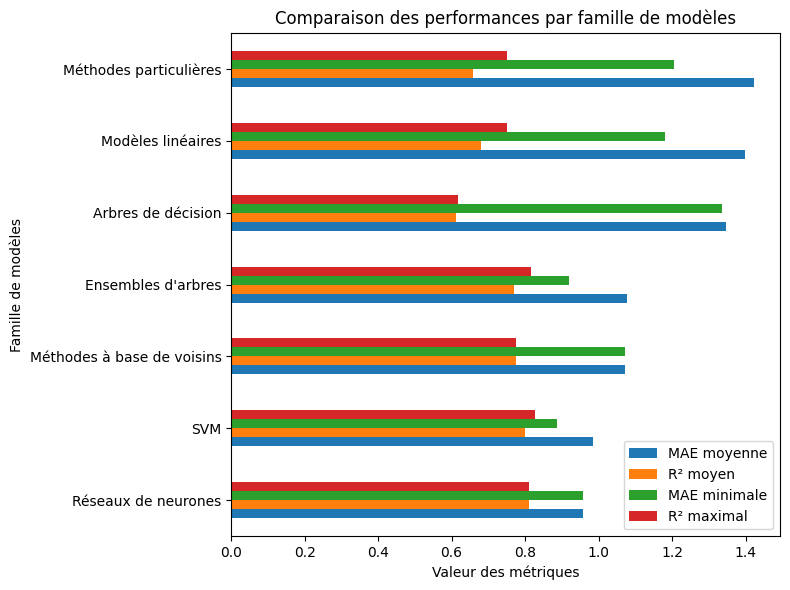

In [19]:
# Cette cellule visualise les performances moyennes par famille de modèles.
# Elle permet de comparer rapidement les catégories de modèles selon la MAE et le R².

# Sélection des métriques principales à visualiser
plot_df = category_performance[
    [
        ("MAE_val", "mean"),
        ("r2_val", "mean"),
        ("MAE_val", "min"),
        ("r2_val", "max")
    ]
].copy()

# Renommage des colonnes pour un affichage plus clair
plot_df.columns = [
    "MAE moyenne",
    "R² moyen",
    "MAE minimale",
    "R² maximal"
]

# Conversion en valeurs numériques
# Utile si certaines valeurs ont été remplacées par des chaînes vides auparavant
plot_df = plot_df.apply(pd.to_numeric, errors="coerce")

# Affichage du tableau utilisé pour le graphique
display(plot_df)

# Graphique comparatif
plot_df.plot(kind="barh", figsize=(8, 6))

plt.title("Comparaison des performances par famille de modèles")
plt.xlabel("Valeur des métriques")
plt.ylabel("Famille de modèles")

plt.tight_layout()
plt.show()

## 6. Modèles d'arbres et de boosting

Les résultats exploratoires obtenus avec LazyPredict orientent ensuite l'analyse vers les modèles d'arbres et de boosting.

Ces modèles sont particulièrement adaptés aux données tabulaires.  
Ils permettent de capturer des relations non linéaires entre les variables explicatives et la cible, sans imposer une forme fonctionnelle simple comme dans les modèles linéaires.

Les modèles d'arbres sont également capables de prendre en compte des interactions entre variables, par exemple entre l'irradiance, la nébulosité, les conditions de ciel clair et les variables temporelles.

### 6.1 LightGBM

LightGBM est un modèle de gradient boosting basé sur des arbres de décision.  
Il construit progressivement plusieurs arbres, où chaque nouvel arbre cherche à corriger les erreurs commises par les arbres précédents.

Dans cette section, on suit trois étapes:

1. entraînement d'un premier modèle LightGBM de référence ;
2. recherche des meilleurs hyperparamètres à l'aide d'une recherche par grille et des folds temporels définis manuellement ;
3. entraînement et évaluation du meilleur modèle sur l'ensemble de validation.

L'objectif est de vérifier si LightGBM améliore les performances par rapport aux modèles de référence, tout en respectant la structure temporelle des données.

#### 6.1.1 Optimisation des hyperparamètres LightGBM avec Optuna

L'optimisation des hyperparamètres de LightGBM est réalisée avec **Optuna**, en utilisant les folds temporels définis manuellement.

Contrairement à une recherche par grille, Optuna ne teste pas toutes les combinaisons possibles.  
Il explore progressivement l'espace des hyperparamètres et concentre la recherche sur les zones les plus prometteuses.

Pour chaque essai Optuna, une combinaison d'hyperparamètres est proposée.  
Cette combinaison est évaluée sur plusieurs folds temporels: le modèle est entraîné sur une période passée puis validé sur une période future.

L'évaluation repose principalement sur:

- la **MAE moyenne de validation**, qui mesure l'erreur prédictive ;
- le **gap train/validation**, qui sert d'indicateur de surapprentissage ;
- l'**early stopping**, utilisé à l'intérieur de chaque fold afin d'arrêter l'entraînement lorsque la performance sur la période de validation intérieur ne s'améliore plus.

L'objectif est donc de choisir un modèle performant en validation temporelle, tout en restant robuste et en limitant le surapprentissage.

| Paramètre | Explication |
|---|---|
| `n_estimators` | Nombre maximal d'arbres de boosting. Un nombre plus grand permet au modèle d'apprendre plus longtemps, mais augmente le temps d'entraînement et le risque de surapprentissage. |
| `learning_rate` | Taille du pas d'apprentissage. Une valeur faible rend l'apprentissage plus progressif et peut améliorer la généralisation, mais nécessite souvent plus d'arbres. |
| `num_leaves` | Nombre maximal de feuilles par arbre. Une valeur plus grande permet de capturer des relations plus complexes, mais peut augmenter le risque de surapprentissage. |
| `max_depth` | Profondeur maximale des arbres. Limiter cette profondeur permet de contrôler la complexité du modèle. |
| `min_child_samples` | Nombre minimum d'échantillons dans une feuille. Une valeur plus élevée rend le modèle plus conservateur. |
| `subsample` | Fraction des observations utilisées pour entraîner chaque arbre. Une valeur inférieure à 1 introduit de l'aléatoire et peut améliorer la généralisation. |
| `colsample_bytree` | Fraction des variables utilisées pour construire chaque arbre. Cela peut réduire la corrélation entre les arbres et limiter le surapprentissage. |
| `reg_alpha` | Régularisation L1. Elle pénalise certains poids et peut rendre le modèle plus parcimonieux. |
| `reg_lambda` | Régularisation L2. Elle stabilise le modèle en pénalisant les poids trop grands. |

In [26]:
# Copie des ensembles utilisés pour LightGBM
X_train_lgbm = X_train.copy()
X_valid_lgbm = X_valid.copy()

# =======================================================
# Évaluation d'une combinaison d'hyperparamètres LightGBM
# =======================================================
def evaluate_params(params, X, y, trial=None):
    """
    Évalue une combinaison d'hyperparamètres LightGBM
    sur les folds temporels définis manuellement.

    La fonction retourne deux objectifs:
    - la MAE moyenne sur validation ;
    - le gap moyen entre train et validation.
    """
    # listes pour stocker les métriques
    maes_valid = []; maes_train = []
    rmses_valid = []; rmses_train = []
    r2_trains = []; r2_valids = []
    gaps = []; best_iterations = []

    # génération des folds temporels manuels
    folds = get_folds(X, y)

    # boucle sur les folds temporels
    for step, (X_tr, X_v, y_tr, y_v) in enumerate(folds):

        # Création du modèle LightGBM avec les paramètres proposés
        model = LGBMRegressor(**params)

        # Entraînement du modèle avec early stopping
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_v, y_v)],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        # Récupération de la meilleure itération
        best_iter = model.best_iteration_ or params["n_estimators"]
        best_iterations.append(best_iter)
        
        # Prédictions sur train et validation avec la meilleure itération
        pred_train = model.predict(X_tr, num_iteration=best_iter)
        pred_valid = model.predict(X_v, num_iteration=best_iter)

        # MAE train et validation
        mae_train = mean_absolute_error(y_tr, pred_train)
        mae_valid = mean_absolute_error(y_v, pred_valid)
        
        # RMSE train et validation
        rmse_train = np.sqrt(mean_squared_error(y_tr, pred_train))
        rmse_valid = np.sqrt(mean_squared_error(y_v, pred_valid))
        
        # R2 train et validation
        r2_train = r2_score(y_tr, pred_train)
        r2_valid = r2_score(y_v, pred_valid)

        # Gap train/validation
        gap = max(0, mae_valid - mae_train)

        # Stockage des métriques du fold
        maes_valid.append(mae_valid)
        maes_train.append(mae_train)
        rmses_valid.append(rmse_valid)
        rmses_train.append(rmse_train)
        r2_trains.append(r2_train)
        r2_valids.append(r2_valid)
        gaps.append(gap)

    # Résumé des métriques sur tous les folds
    median_best_iteration = int(np.median(best_iterations))
    
    mean_mae_valid = np.mean(maes_valid)
    mean_mae_train = np.mean(maes_train)
    
    std_mae_valid = np.std(maes_valid)
    std_mae_train = np.std(maes_train)
    
    mean_r2_train = np.mean(r2_trains)
    mean_r2_valid = np.mean(r2_valids)
    
    mean_rmse_valid = np.mean(rmses_valid)
    mean_rmse_train = np.mean(rmses_train)
    
    mean_gap = np.mean(gaps)

    # Pourcentage de gap par rapport à la MAE de validation
    gap_pct = 100 * max(0, mean_mae_valid - mean_mae_train) / mean_mae_valid

    # Sauvegarde des informations utiles dans Optuna
    if trial is not None:
        trial.set_user_attr("best_iteration", median_best_iteration)

        trial.set_user_attr("mean_mae_valid", mean_mae_valid)
        trial.set_user_attr("mean_mae_train", mean_mae_train)

        trial.set_user_attr("std_mae_valid", std_mae_valid)
        trial.set_user_attr("std_mae_train", std_mae_train)
    
        trial.set_user_attr("mean_rmse_valid", mean_rmse_valid)
        trial.set_user_attr("mean_rmse_train", mean_rmse_train)
    
        trial.set_user_attr("mean_r2_valid", mean_r2_valid)
        trial.set_user_attr("mean_r2_train", mean_r2_train)
    
        trial.set_user_attr("mean_gap", mean_gap)
        trial.set_user_attr("std_gap", np.std(gaps))
        trial.set_user_attr("max_gap", np.max(gaps))
        trial.set_user_attr("overfit_gap_pct", gap_pct)
        
    # Optuna va minimiser ces deux objectifs
    return mean_mae_valid, mean_gap


# ========================================
# Fonction objective Optuna pour LightGBM
# ========================================
def objective_lgbm(trial):
    """
    Fonction appelée par Optuna à chaque essai.

    À chaque essai, Optuna propose une combinaison d'hyperparamètres,
    puis cette combinaison est évaluée sur les folds temporels.
    """
    
    # espace de recherche des hyperparamètres
    params = {
        "n_estimators": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
    
        "num_leaves": trial.suggest_int("num_leaves", 31, 128),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
    
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
    
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
    
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
    
        "random_state": 42,
        "n_jobs": 1,
        "verbosity": -1
    }

    # Évaluation des paramètres proposés sur les folds temporels
    return evaluate_params(
        params,
        X_dev,
        y_dev,
        trial=trial
    )


#----------------------------------------
# Création et lancement de l'étude Optuna
#----------------------------------------
study_lgbm = optuna.create_study(
    study_name="study_lgbm_new",
    storage=f"sqlite:///{filepath_output}study_lgbm_new.db",
    load_if_exists=True,
    directions=["minimize", "minimize"],
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=150,
        seed=42
    )
)

# lancement de l'optimisation
# n_trials=300 signifie 300 combinaisons testées par Optuna
study_lgbm.optimize(
    objective_lgbm,
    n_trials=300,
    n_jobs=-1
)


[I 2026-04-26 15:33:43,909] A new study created in RDB with name: study_lgbm_new
[I 2026-04-26 15:34:01,257] Trial 7 finished with values: [0.4802907659697787, 0.08487760168354183] and parameters: {'learning_rate': 0.09673076010733318, 'num_leaves': 86, 'max_depth': 4, 'min_child_samples': 98, 'subsample': 0.9835987595396125, 'colsample_bytree': 0.8480147908475961, 'reg_alpha': 0.7833177129923361, 'reg_lambda': 0.03846501950107067}.
[I 2026-04-26 15:34:02,283] Trial 1 finished with values: [0.4634913061139167, 0.09081458534573149] and parameters: {'learning_rate': 0.055528145443294284, 'num_leaves': 52, 'max_depth': 7, 'min_child_samples': 79, 'subsample': 0.8705660971435647, 'colsample_bytree': 0.7493076569232109, 'reg_alpha': 0.08094416133204597, 'reg_lambda': 1.3577372483867727}.
[I 2026-04-26 15:34:07,026] Trial 0 finished with values: [0.4607965867422564, 0.1188976225746998] and parameters: {'learning_rate': 0.07645938733079988, 'num_leaves': 123, 'max_depth': 9, 'min_child_sample

#### 6.1.2 Sélection du meilleur essai Optuna et entraînement final

Après l'optimisation, Optuna fournit plusieurs essais candidats, car l'étude minimise deux objectifs: la MAE moyenne de validation et le gap train/validation.

Ces essais appartiennent au **front de Pareto**.  
Dans une optimisation multi-objective, le front de Pareto regroupe les solutions pour lesquelles il n'existe pas d'autre essai meilleur sur tous les objectifs à la fois. Autrement dit, un essai peut avoir une MAE plus faible mais un gap plus élevé, tandis qu'un autre peut être plus robuste mais légèrement moins performant.

Dans cette étape, on recharge l'étude Optuna sauvegardée, puis on sélectionne un essai parmi ces meilleurs compromis.  
Le choix privilégie une faible MAE, tout en pénalisant les modèles présentant un gap trop important entre l'entraînement et la validation.

Les hyperparamètres du meilleur essai sont ensuite récupérés.  
Le nombre d'arbres `n_estimators` est remplacé par la meilleure itération déterminée grâce à l'early stopping pendant la validation croisée temporelle.

Enfin, le modèle LightGBM sélectionné est réentraîné sur l'ensemble `train`, puis évalué sur les ensembles `train` et `valid` afin de comparer ses performances avec les modèles précédents.

In [31]:
# =================================================================
# Chargement de l'étude Optuna et entraînement du meilleur LightGBM
# =================================================================

# Copie des données utilisées pour LightGBM
X_train_lgbm = X_train.copy()
X_valid_lgbm = X_valid.copy()

# Chargement de l'étude Optuna déjà optimisée
study_lgbm = optuna.load_study(
    study_name="study_lgbm_new",
    storage=f"sqlite:///{filepath_output}study_lgbm_new.db"
)

# =========================================================
# Sélection du meilleur essai parmi les meilleurs compromis
# =========================================================

# Dans une optimisation multi-objective, Optuna retourne plusieurs meilleurs essais
# correspondant au front de Pareto.
lgbm_trials = study_lgbm.best_trials

# Choix d'un compromis:
# - priorité à une faible MAE ;
# - pénalité si le gap relatif dépasse 4 %.
best_trial_lgbm = min(
    lgbm_trials,
    key=lambda t: t.values[0] + 50 * max(0, (t.values[1] / t.values[0]) - 0.04)
)

print("Selected trial:")
print(f"Meilleur MAE = {best_trial_lgbm.values[0]}")
print(f"Meilleur GAP = {best_trial_lgbm.values[1]}")


# ==========================================
# Récupération des meilleurs hyperparamètres
# ==========================================

# On copie les paramètres pour éviter de modifier directement l'objet trial
best_params_lgbm = best_trial_lgbm.params.copy()

# On remplace n_estimators par la meilleure itération médiane obtenue avec early stopping
best_params_lgbm["n_estimators"] = best_trial_lgbm.user_attrs["best_iteration"]

print("Best_params_lgbm:", best_params_lgbm)


# ========================================
# Entraînement du meilleur modèle LightGBM
# ========================================

best_model_lgbm = LGBMRegressor(
    verbosity=-1,
    random_state=42,
    n_jobs=-1,
    **best_params_lgbm
)

# Entraînement final sur l'ensemble train
best_model_lgbm.fit(X_train_lgbm, y_train)


# ==================================
# Évaluation sur train et validation
# ==================================

# Prédictions
y_pred_train_lgbm = best_model_lgbm.predict(X_train_lgbm)
y_pred_valid_lgbm = best_model_lgbm.predict(X_valid_lgbm)

# Métriques train
mae_train_lgbm = mean_absolute_error(y_train, y_pred_train_lgbm)
rmse_train_lgbm = np.sqrt(mean_squared_error(y_train, y_pred_train_lgbm))
r2_train_lgbm = r2_score(y_train, y_pred_train_lgbm)
nmae_train_lgbm = calculer_nmae(y_train, y_pred_train_lgbm)

# Métriques validation
mae_valid_lgbm = mean_absolute_error(y_valid, y_pred_valid_lgbm)
rmse_valid_lgbm = np.sqrt(mean_squared_error(y_valid, y_pred_valid_lgbm))
r2_valid_lgbm = r2_score(y_valid, y_pred_valid_lgbm)
nmae_valid_lgbm = calculer_nmae(y_valid, y_pred_valid_lgbm)

# Pourcentage d'overfitting sur l'évaluation finale train/validation
overfit_pct_lgbm = (
    100 * max(0, mae_valid_lgbm - mae_train_lgbm) / mae_valid_lgbm
    if mae_valid_lgbm != 0 else np.nan
)


# =======================
# Affichage des résultats
# =======================

print("\n--- Résultats LGBMRegressor ---")

print(f"MAE valid_lgbm     : {mae_valid_lgbm}")
print(f"MAE train_lgbm     : {mae_train_lgbm}")

print(f"NMAE valid_lgbm    : {nmae_valid_lgbm:.3f} %")
print(f"NMAE train_lgbm    : {nmae_train_lgbm:.3f} %")

print(f"RMSE valid_lgbm    : {rmse_valid_lgbm}")
print(f"RMSE train_lgbm    : {rmse_train_lgbm}")

print(f"R² valid_lgbm      : {r2_valid_lgbm}")
print(f"R² train_lgbm      : {r2_train_lgbm}")

print(f"Overfitting CV     : {best_trial_lgbm.user_attrs['overfit_gap_pct']:.2f} %")
print(f"Overfitting final  : {overfit_pct_lgbm:.2f} %")

# MAE moyenne obtenue pendant la validation croisée temporelle
MAE_CV_moyenne_lgbm = best_trial_lgbm.user_attrs["mean_mae_valid"]

print("MAE_CV_moyenne_lgbm:", MAE_CV_moyenne_lgbm)


# =====================================
# Ajout au tableau global des résultats
# =====================================

# Ajout des métriques du meilleur LightGBM
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_lgbm,
        y_valid,
        y_pred_valid_lgbm,
        nom_modele="LGBMRegressor",
        MAE_CV_moyenne=MAE_CV_moyenne_lgbm
    )
)

# Affichage du tableau comparatif
resultats_df = pd.DataFrame(resultats).sort_values("MAE_valid")
display(resultats_df)

Selected trial:
Meilleur MAE = 0.48827067194278095
Meilleur GAP = 0.042476462395805784
Best_params_lgbm: {'learning_rate': 0.00500506602458601, 'num_leaves': 122, 'max_depth': 4, 'min_child_samples': 96, 'subsample': 0.7536176371507638, 'colsample_bytree': 0.7059471341507862, 'reg_alpha': 0.009870716017689346, 'reg_lambda': 0.0019045973808220768, 'n_estimators': 1999}

--- Résultats LGBMRegressor ---
MAE valid_lgbm      : 0.4847025508443153
MAE train_lgbm      : 0.44512317644698585
NMAE valid_lgbm     : 20.348 %
NMAE train_lgbm     : 18.232 %
RMSE valid_lgbm     : 0.9967948392638326
RMSE train_lgbm     : 0.9258711906297461
R² valid_lgbm       : 0.9045109469223386
R² train_lgbm       : 0.9217459872473538
Overfitting CV      : 8.70 %
Overfitting final   : 8.17 %
MAE_CV_moyenne_lgbm: 0.48827067194278095


,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
5,LGBMRegressor,0.45,18.23,0.93,0.92,0.48,20.35,1.00,0.90,0.49,0.04,0.02
4,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01


In [32]:
# ============================================================
# Sauvegarde et rechargement du meilleur modèle LightGBM
# ============================================================

# Chemin du dossier où sauvegarder les meilleurs modèles
best_models_path = filepath_output + "Best_Models/"

# Chemin complet du fichier de sauvegarde
model_path_lgbm = best_models_path + "best_model_lgbm.joblib"

# Sauvegarde du meilleur modèle LightGBM entraîné
joblib.dump(best_model_lgbm, model_path_lgbm)

# Rechargement du modèle sauvegardé
best_model_lgbm = joblib.load(model_path_lgbm)


#### 6.1.3 Visualisation des prédictions LightGBM

Après l'entraînement et l'évaluation numérique du modèle LightGBM, on visualise maintenant la qualité des prédictions sur l'ensemble de validation.

Le graphique suivant compare les valeurs réelles de la cible aux valeurs prédites par le modèle.  
La ligne diagonale représente une prédiction parfaite: plus les points sont proches de cette ligne, plus les prédictions sont précises.

Cette visualisation permet de vérifier rapidement si le modèle suit correctement la tendance générale des données, et si certaines zones présentent des erreurs plus importantes.

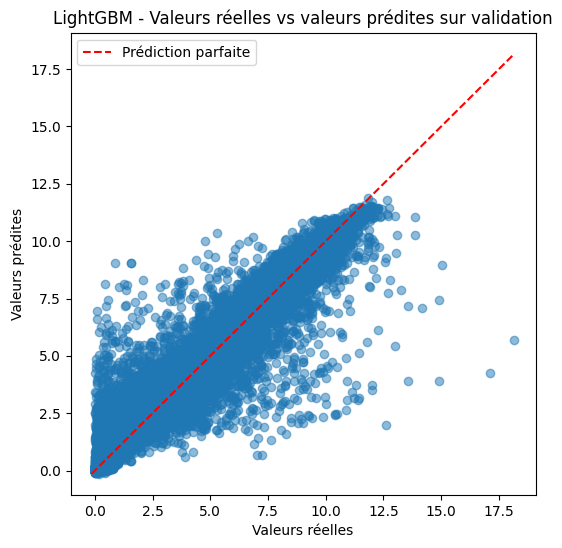

In [33]:
# ============================================================
# Visualisation: valeurs réelles vs valeurs prédites LightGBM
# ============================================================

# Cette cellule compare les valeurs réelles de la cible avec les prédictions
# du modèle LightGBM sur l'ensemble de validation.

plt.figure(figsize=(6, 6))

# Nuage de points:
# chaque point représente une observation de validation
# axe x: valeur réelle
# axe y: valeur prédite
plt.scatter(y_valid, y_pred_valid_lgbm, alpha=0.5)

# Ligne idéale y = x
# Si les prédictions étaient parfaites, tous les points seraient sur cette ligne
min_val = min(y_valid.min(), y_pred_valid_lgbm.min())
max_val = max(y_valid.max(), y_pred_valid_lgbm.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Prédiction parfaite"
)

# Titres et labels
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("LightGBM - Valeurs réelles vs valeurs prédites sur validation")

# Affichage de la légende
plt.legend()

# Affichage du graphique
plt.show()

Après l'optimisation et l'évaluation de LightGBM, on applique maintenant la même démarche à d'autres modèles identifiés comme prometteurs lors de l'étape exploratoire avec LazyPredict.

Pour les modèles suivants, on conserve la même stratégie d'optimisation: Optuna est utilisé avec les folds temporels définis manuellement, et les modèles sont comparés principalement à partir de la MAE moyenne de validation croisée temporelle et du gap train/validation.

L'objectif est de comparer plusieurs modèles avancés dans des conditions similaires: mêmes ensembles de données, mêmes folds temporels, même métrique principale et même attention portée au surapprentissage.

On commence par **XGBoost**, afin de le comparer directement à LightGBM.

### 6.2 XGBoost

XGBoost est un algorithme de gradient boosting très utilisé pour les données tabulaires.

Comme LightGBM, il construit progressivement plusieurs arbres de décision, où chaque nouvel arbre cherche à corriger les erreurs des arbres précédents.  
Il permet de modéliser des relations non linéaires ainsi que des interactions complexes entre les variables explicatives.

Dans cette section, XGBoost est optimisé avec la même méthodologie que LightGBM, puis évalué sur l'ensemble de validation.

L'objectif est de vérifier s'il apporte un gain de performance par rapport à LightGBM et aux modèles de référence déjà testés.

Les principaux hyperparamètres optimisés pour XGBoost sont résumés ci-dessous.

| Paramètre | Explication |
|---|---|
| `n_estimators` | Nombre maximal d'arbres de boosting construits successivement. Une grande valeur peut améliorer les performances, mais augmente le temps de calcul et le risque de surapprentissage. Avec l'early stopping, le nombre effectif d'arbres peut être plus faible. |
| `learning_rate` | Taux d'apprentissage appliqué à la contribution de chaque arbre. Une petite valeur rend l'apprentissage plus progressif, mais nécessite souvent plus d'arbres. |
| `max_depth` | Profondeur maximale de chaque arbre. Des arbres plus profonds peuvent capturer des relations plus complexes, mais peuvent aussi surajuster les données. |
| `min_child_weight` | Poids minimal requis dans un nœud feuille pour autoriser une nouvelle division. Une valeur élevée rend le modèle plus conservateur. |
| `subsample` | Fraction des observations utilisée pour construire chaque arbre. Une valeur inférieure à 1 introduit de l'aléatoire et peut aider à réduire le surapprentissage. |
| `colsample_bytree` | Fraction des variables utilisée pour construire chaque arbre. Cela permet de diversifier les arbres et de limiter le surapprentissage. |
| `gamma` | Gain minimal requis pour effectuer une nouvelle division dans un arbre. Plus `gamma` est grand, plus le modèle devient prudent dans la création de nouvelles divisions. |
| `reg_alpha` | Régularisation L1 appliquée aux poids du modèle. Elle peut rendre le modèle plus parcimonieux. |
| `reg_lambda` | Régularisation L2 appliquée aux poids du modèle. Elle pénalise les poids trop grands et aide à stabiliser le modèle. |
| `tree_method` | Méthode de construction des arbres. Ici, `hist` utilise une méthode basée sur des histogrammes, généralement plus rapide sur des jeux de données tabulaires. |
| `max_bin` | Nombre maximal d'intervalles utilisés pour discrétiser les variables continues avec `tree_method="hist"`. Une valeur plus grande peut améliorer la précision, mais augmente le temps de calcul. |

Comme pour LightGBM, l'optimisation est réalisée avec **Optuna**.  
À chaque essai, Optuna propose une combinaison d'hyperparamètres, qui est évaluée sur les folds temporels définis manuellement.

L'objectif est de minimiser principalement la MAE moyenne de validation, tout en surveillant le gap train/validation afin de limiter le surapprentissage.

Quelques règles pratiques permettent d'interpréter les effets des hyperparamètres:

- si le modèle surapprend: augmenter `gamma`, `min_child_weight` ou `reg_lambda`, réduire `max_depth` ou `subsample` ;
- si le modèle sous-apprend: réduire `gamma` ou `min_child_weight`, augmenter `max_depth` ou réduire la régularisation ;
- si l'apprentissage est instable: réduire `learning_rate` et augmenter `n_estimators`.

#### 6.2.1 Optimisation des hyperparamètres XGBoost avec Optuna

L'optimisation de XGBoost suit la même logique que celle appliquée à LightGBM.

Les hyperparamètres sont optimisés avec **Optuna**, en utilisant les folds temporels définis manuellement.  
Pour chaque essai, Optuna propose une combinaison d'hyperparamètres, puis le modèle est entraîné sur une période passée et validé sur une période future.

L'évaluation repose principalement sur:

- la **MAE moyenne de validation croisée temporelle**, utilisée comme métrique principale ;
- le **gap train/validation**, utilisé comme indicateur de surapprentissage ;
- l'**early stopping**, qui permet d'arrêter l'entraînement lorsque la performance sur le fold de validation ne s'améliore plus.

L'objectif est de sélectionner une configuration performante et robuste, capable de généraliser correctement sur des périodes futures.

In [9]:
# ============================================================
# XGBoost: optimisation avec Optuna et folds temporels manuels
# ============================================================

# Copie des ensembles utilisés pour XGBoost
X_train_xgb = X_train.copy()
X_valid_xgb = X_valid.copy()


# ============================================================
# Évaluation d'une combinaison d'hyperparamètres XGBoost
# ============================================================

def evaluate_params_xgb(params, X, y, trial=None):
    """
    Évalue une combinaison d'hyperparamètres XGBoost
    sur les folds temporels définis manuellement.

    La fonction retourne deux objectifs:
    - la MAE moyenne sur validation ;
    - le gap moyen entre train et validation.
    """

    # Listes pour stocker les métriques de chaque fold
    maes_valid = []; maes_train = []
    rmses_valid = []; rmses_train = []
    r2_trains = []; r2_valids = []
    gaps = []; best_iterations = []

    folds = get_folds(X, y)

    for step, (X_tr, X_v, y_tr, y_v) in enumerate(folds):

        model = XGBRegressor(
            **params,
            eval_metric="mae",
            early_stopping_rounds = 50
        )
        
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_v, y_v)],
            verbose=False
        )
        
        best_iter = model.best_iteration + 1
        best_iterations.append(best_iter)

        pred_train = model.predict(X_tr, iteration_range=(0, best_iter))
        pred_valid = model.predict(X_v, iteration_range=(0, best_iter))

        # métriques
        mae_train = mean_absolute_error(y_tr, pred_train)
        mae_valid = mean_absolute_error(y_v, pred_valid)

        rmse_train = np.sqrt(mean_squared_error(y_tr, pred_train))
        rmse_valid = np.sqrt(mean_squared_error(y_v, pred_valid))

        r2_train = r2_score(y_tr, pred_train)
        r2_valid = r2_score(y_v, pred_valid)

        gap = max(0, mae_valid - mae_train)

        maes_valid.append(mae_valid)
        maes_train.append(mae_train)
        rmses_valid.append(rmse_valid)
        rmses_train.append(rmse_train)
        r2_trains.append(r2_train)
        r2_valids.append(r2_valid)
        gaps.append(gap)

    median_best_iteration = int(np.median(best_iterations))

    mean_mae_valid = np.mean(maes_valid)
    mean_mae_train = np.mean(maes_train)
    std_mae_valid = np.std(maes_valid)
    std_mae_train = np.std(maes_train)

    mean_r2_train = np.mean(r2_trains)
    mean_r2_valid = np.mean(r2_valids)

    mean_rmse_valid = np.mean(rmses_valid)
    mean_rmse_train = np.mean(rmses_train)

    mean_gap = np.mean(gaps)
    gap_pct = 100 * max(0, mean_mae_valid - mean_mae_train) / mean_mae_valid

    
    if trial is not None:
        trial.set_user_attr("best_iteration", median_best_iteration)

        trial.set_user_attr("mean_mae_valid", mean_mae_valid)
        trial.set_user_attr("mean_mae_train", mean_mae_train)

        trial.set_user_attr("std_mae_valid", std_mae_valid)
        trial.set_user_attr("std_mae_train", std_mae_train)

        trial.set_user_attr("mean_rmse_valid", mean_rmse_valid)
        trial.set_user_attr("mean_rmse_train", mean_rmse_train)

        trial.set_user_attr("mean_r2_valid", mean_r2_valid)
        trial.set_user_attr("mean_r2_train", mean_r2_train)

        trial.set_user_attr("mean_gap", mean_gap)
        trial.set_user_attr("std_gap", np.std(gaps))
        trial.set_user_attr("max_gap", np.max(gaps))
        trial.set_user_attr("overfit_gap_pct", gap_pct)

    return mean_mae_valid, mean_gap

def objective_xgb(trial):

    max_depth = trial.suggest_int("max_depth", 3, 7)

    # Interaction entre max_depth et min_child_weight:
    # si les arbres sont profonds, on impose un min_child_weight plus élevé
    # pour limiter le surapprentissage.
    if max_depth >= 7:
        min_child_weight = trial.suggest_int("min_child_weight", 10, 30)
    else:
        min_child_weight = trial.suggest_int("min_child_weight", 1, 30)

    params = {
        "n_estimators": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),

        "max_depth": max_depth,
        "min_child_weight": min_child_weight,

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 20.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 20.0, log=True),

        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),

        "random_state": 42,
        "n_jobs": 1,
        "verbosity": 0
    }

    return evaluate_params_xgb(
        params,
        X_dev,
        y_dev,
        trial=trial
    )

# ====================================================
# Création et lancement de l'étude Optuna pour XGBoost
# ====================================================

study_xgb = optuna.create_study(
    study_name="study_xgb",
    storage=f"sqlite:///{filepath_output}study_xgb.db",
    load_if_exists=True,
    directions=["minimize", "minimize"],
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=100,
        seed=42
    )
)

# Lancement de l'optimisation
study_xgb.optimize(
    objective_xgb,
    n_trials=200,
    n_jobs=-1
)

[I 2026-04-26 13:41:30,699] A new study created in RDB with name: study_xgb
[I 2026-04-26 13:42:11,795] Trial 15 finished with values: [0.45784811346480453, 0.12162906002405369] and parameters: {'max_depth': 7, 'min_child_weight': 23, 'learning_rate': 0.054465788425935524, 'subsample': 0.6451305440930974, 'colsample_bytree': 0.612356771725593, 'reg_alpha': 0.00048474344575777107, 'reg_lambda': 0.00011775829568446288, 'gamma': 5.207728910035324e-07}.
[I 2026-04-26 13:42:29,293] Trial 1 finished with values: [0.4596128206406733, 0.17352710479361297] and parameters: {'max_depth': 7, 'min_child_weight': 16, 'learning_rate': 0.06028794412850894, 'subsample': 0.6725258852867247, 'colsample_bytree': 0.9305135285048662, 'reg_alpha': 4.905029809375589, 'reg_lambda': 0.03558372027566485, 'gamma': 7.360161791584381e-07}.
[I 2026-04-26 13:42:41,991] Trial 4 finished with values: [0.455948310815532, 0.15344195035121522] and parameters: {'max_depth': 7, 'min_child_weight': 24, 'learning_rate': 0.037

#### 6.2.2 Sélection du meilleur essai Optuna et évaluation du modèle XGBoost

Après l'optimisation des hyperparamètres, l'étude Optuna est rechargée afin de récupérer les meilleurs essais obtenus.

Comme l'optimisation est multi-objective, plusieurs essais peuvent appartenir au front de Pareto.  
On sélectionne donc un compromis entre deux critères:

- une faible MAE moyenne en validation croisée temporelle ;
- un gap train/validation limité, afin de réduire le risque de surapprentissage.

Le meilleur essai est ensuite utilisé pour construire le modèle XGBoost final.  
Le nombre d'arbres `n_estimators` est remplacé par la meilleure itération obtenue avec l'early stopping pendant la validation croisée.

Le modèle sélectionné est ensuite entraîné sur l'ensemble `train`, puis évalué sur les ensembles `train` et `valid`.  
Les métriques obtenues sont finalement ajoutées au tableau global des résultats afin de comparer XGBoost aux autres modèles.

In [34]:
# ========================================================
# Sélection du meilleur essai Optuna et évaluation XGBoost
# ========================================================

# Copie des ensembles utilisés pour XGBoost
X_train_xgb = X_train.copy()
X_valid_xgb = X_valid.copy()

# Chargement de l'étude Optuna déjà optimisée
study_xgb = optuna.load_study(
    study_name="study_xgb",
    storage=f"sqlite:///{filepath_output}study_xgb.db"
)

# ==============================================
# Sélection du meilleur essai du front de Pareto
# ==============================================

# Optuna retourne plusieurs meilleurs essais car l'étude est multi-objective
xgb_trials = study_xgb.best_trials

# Choix d'un compromis:
# - faible MAE moyenne en validation croisée temporelle
# - pénalité si le gap relatif dépasse 4 %
best_trial_xgb = min(
    xgb_trials,
    key=lambda t: t.values[0] + 50 * max(0, (t.values[1] / t.values[0]) - 0.04)
)

print("Selected trial:")
print(f"MAE = {best_trial_xgb.values[0]}")
print(f"GAP = {best_trial_xgb.values[1]}")


# ==========================================
# Récupération des meilleurs hyperparamètres
# ==========================================

# Copie des paramètres pour éviter de modifier directement l'objet Optuna
best_params_xgb = best_trial_xgb.params.copy()

# Remplacement de n_estimators par la meilleure itération obtenue avec early stopping
best_params_xgb["n_estimators"] = best_trial_xgb.user_attrs["best_iteration"]

print("Best_params_xgb:", best_params_xgb)

# ====================================
# Entraînement du modèle XGBoost final
# ====================================

best_model_xgb = XGBRegressor(
    verbosity=0,
    random_state=42,
    n_jobs=-1,
    **best_params_xgb
)

# Entraînement sur l'ensemble train
best_model_xgb.fit(X_train_xgb, y_train)


# ==================================
# Évaluation sur train et validation
# ==================================

# Prédictions
y_pred_train_xgb = best_model_xgb.predict(X_train_xgb)
y_pred_valid_xgb = best_model_xgb.predict(X_valid_xgb)

# Métriques train
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
nmae_train_xgb = calculer_nmae(y_train, y_pred_train_xgb)

# Métriques validation
mae_valid_xgb = mean_absolute_error(y_valid, y_pred_valid_xgb)
rmse_valid_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_valid_xgb))
r2_valid_xgb = r2_score(y_valid, y_pred_valid_xgb)
nmae_valid_xgb = calculer_nmae(y_valid, y_pred_valid_xgb)

# Pourcentage d'overfitting final
overfit_pct_xgb = (
    100 * max(0, mae_valid_xgb - mae_train_xgb) / mae_valid_xgb
    if mae_valid_xgb != 0 else np.nan
)


# =======================
# Affichage des résultats
# =======================

print("\n--- Résultats XGBRegressor ---")

print(f"MAE valid_xgb     : {mae_valid_xgb}")
print(f"MAE train_xgb     : {mae_train_xgb}")

print(f"NMAE valid_xgb    : {nmae_valid_xgb:.3f} %")
print(f"NMAE train_xgb    : {nmae_train_xgb:.3f} %")

print(f"RMSE valid_xgb    : {rmse_valid_xgb}")
print(f"RMSE train_xgb    : {rmse_train_xgb}")

print(f"R² valid_xgb      : {r2_valid_xgb}")
print(f"R² train_xgb      : {r2_train_xgb}")

print(f"Overfitting CV    : {best_trial_xgb.user_attrs['overfit_gap_pct']:.2f} %")
print(f"Overfitting final : {overfit_pct_xgb:.2f} %")

# MAE moyenne obtenue pendant la validation croisée temporelle
MAE_CV_moyenne_xgb = best_trial_xgb.user_attrs["mean_mae_valid"]

print("MAE_CV_moyenne_xgb:", MAE_CV_moyenne_xgb)


# =====================================
# Ajout au tableau global des résultats
# =====================================

# Ajout du modèle XGBoost au tableau global
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_xgb,
        y_valid,
        y_pred_valid_xgb,
        nom_modele="XGBRegressor",
        MAE_CV_moyenne=MAE_CV_moyenne_xgb
    )
)

# Tableau comparatif final, trié par performance sur validation
resultats_df = pd.DataFrame(resultats).sort_values("MAE_valid")

display(resultats_df)

Selected trial:
MAE = 0.5123288530333205
GAP = 0.028348244696542693
Best_params_xgb: {'max_depth': 3, 'min_child_weight': 25, 'learning_rate': 0.005021832648534782, 'subsample': 0.7165236031933135, 'colsample_bytree': 0.6314677891528471, 'reg_alpha': 0.0003960709268170266, 'reg_lambda': 19.93861869281122, 'gamma': 0.005385444325599382, 'n_estimators': 1999}

--- Résultats XGBRegressor ---
MAE valid_xgb      : 0.5026510735480139
MAE train_xgb      : 0.4801509201596253
NMAE valid_xgb     : 21.101 %
NMAE train_xgb     : 19.667 %
RMSE valid_xgb     : 1.0137527267577688
RMSE train_xgb     : 0.9772668308433099
R² valid_xgb       : 0.9012343114629596
R² train_xgb       : 0.9128170033200688
Overfitting CV     : 5.53 %
Overfitting final  : 4.48 %
MAE_CV_moyenne_xgb: 0.5123288530333205


,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
5,LGBMRegressor,0.45,18.23,0.93,0.92,0.48,20.35,1.00,0.90,0.49,0.04,0.02
6,XGBRegressor,0.48,19.67,0.98,0.91,0.50,21.10,1.01,0.90,0.51,0.02,0.01
4,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01


In [35]:
# =====================================================
# Sauvegarde et rechargement du meilleur modèle XGBoost
# =====================================================

# Chemin complet du fichier de sauvegarde
model_path_xgb = best_models_path + "best_model_xgb.joblib"

# Sauvegarde du meilleur modèle XGBoost entraîné
joblib.dump(best_model_xgb, model_path_xgb)

# Rechargement du modèle sauvegardé
best_model_xgb = joblib.load(model_path_xgb)


#### 6.2.3 Visualisation des prédictions XGBoost

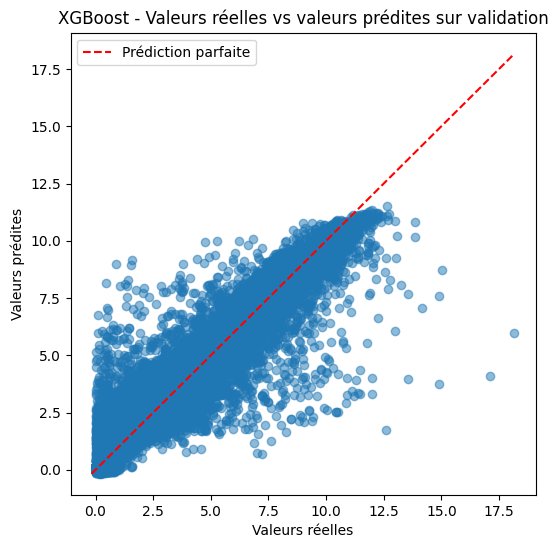

In [36]:
# ============================================================
# Visualisation: valeurs réelles vs valeurs prédites XGBoost
# ============================================================

# Cette cellule compare les valeurs réelles de la cible avec les prédictions
# du modèle XGBoost sur l'ensemble de validation.

plt.figure(figsize=(6, 6))

# Nuage de points:
# axe x: valeurs réelles
# axe y: valeurs prédites par XGBoost
plt.scatter(y_valid, y_pred_valid_xgb, alpha=0.5)

# Ligne idéale y = x
# Si les prédictions étaient parfaites, tous les points seraient sur cette ligne
min_val = min(y_valid.min(), y_pred_valid_xgb.min())
max_val = max(y_valid.max(), y_pred_valid_xgb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Prédiction parfaite"
)

# Titres et labels
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("XGBoost - Valeurs réelles vs valeurs prédites sur validation")

# Légende
plt.legend()

# Affichage
plt.show()

### 6.3 ExtraTreesRegressor

ExtraTreesRegressor est un modèle d'ensemble basé sur plusieurs arbres de décision très aléatorisés.

Contrairement à un arbre unique, il combine les prédictions de nombreux arbres afin d'obtenir une prédiction plus stable et plus robuste.  
L'aléa introduit dans la construction des arbres permet aussi de réduire la variance du modèle et de limiter le risque de surapprentissage.

Ce modèle est intéressant dans ce contexte, car il peut capturer des relations non linéaires et des interactions complexes entre les variables météorologiques, temporelles et régionales.

ExtraTreesRegressor est optimisé avec la même stratégie que les modèles précédents, puis évalué sur l'ensemble de validation.

L'objectif est de vérifier s'il constitue une alternative performante aux modèles de boosting comme LightGBM et XGBoost, ainsi qu'aux modèles de référence déjà testés.

#### 6.3.1 Optimisation des hyperparamètres ExtraTreesRegressor avec Optuna

ExtraTreesRegressor est optimisé avec Optuna en utilisant les folds temporels définis manuellement.

Comme pour les modèles précédents, la sélection repose sur la MAE moyenne de validation croisée temporelle et sur le contrôle du gap train/validation.

In [9]:
# Copie des ensembles utilisés pour ExtraTreesRegressor
X_train_etr = X_train.copy()
X_valid_etr = X_valid.copy()


# =========================================================
# Évaluation d'une combinaison d'hyperparamètres ExtraTrees
# =========================================================

def evaluate_params_etr(params, X, y, trial=None):

    # Listes pour stocker les métriques de chaque fold
    maes_valid = []
    maes_train = []

    rmses_valid = []
    rmses_train = []

    r2_trains = []
    r2_valids = []

    gaps = []

    # Génération des folds temporels manuels
    folds = get_folds(X, y)

    # Boucle sur les folds
    for step, (X_tr, X_v, y_tr, y_v) in enumerate(folds):

        # Création du modèle avec les paramètres proposés par Optuna
        model = ExtraTreesRegressor(**params)

        # Entraînement sur la période passée du fold
        model.fit(X_tr, y_tr)

        # Prédictions sur train et validation du fold
        pred_train = model.predict(X_tr)
        pred_valid = model.predict(X_v)

        # MAE train et validation
        mae_train = mean_absolute_error(y_tr, pred_train)
        mae_valid = mean_absolute_error(y_v, pred_valid)

        # RMSE train et validation
        rmse_train = np.sqrt(mean_squared_error(y_tr, pred_train))
        rmse_valid = np.sqrt(mean_squared_error(y_v, pred_valid))

        # R² train et validation
        r2_train = r2_score(y_tr, pred_train)
        r2_valid = r2_score(y_v, pred_valid)

        # Gap train-validation
        gap = max(0, mae_valid - mae_train)

        # Stockage des métriques
        maes_train.append(mae_train)
        maes_valid.append(mae_valid)

        rmses_train.append(rmse_train)
        rmses_valid.append(rmse_valid)

        r2_trains.append(r2_train)
        r2_valids.append(r2_valid)

        gaps.append(gap)

    # Moyennes des métriques sur tous les folds
    mean_mae_valid = np.mean(maes_valid)
    mean_mae_train = np.mean(maes_train)

    std_mae_valid = np.std(maes_valid)
    std_mae_train = np.std(maes_train)

    mean_rmse_valid = np.mean(rmses_valid)
    mean_rmse_train = np.mean(rmses_train)

    mean_r2_valid = np.mean(r2_valids)
    mean_r2_train = np.mean(r2_trains)

    mean_gap = np.mean(gaps)

    # Pourcentage d'overfitting
    gap_pct = (
        100 * max(0, mean_mae_valid - mean_mae_train) / mean_mae_valid
        if mean_mae_valid != 0 else np.nan
    )

    # Sauvegarde des informations utiles dans Optuna
    if trial is not None:
        trial.set_user_attr("mean_mae_valid", mean_mae_valid)
        trial.set_user_attr("mean_mae_train", mean_mae_train)

        trial.set_user_attr("std_mae_valid", std_mae_valid)
        trial.set_user_attr("std_mae_train", std_mae_train)

        trial.set_user_attr("mean_rmse_valid", mean_rmse_valid)
        trial.set_user_attr("mean_rmse_train", mean_rmse_train)

        trial.set_user_attr("mean_r2_valid", mean_r2_valid)
        trial.set_user_attr("mean_r2_train", mean_r2_train)

        trial.set_user_attr("mean_gap", mean_gap)
        trial.set_user_attr("std_gap", np.std(gaps))
        trial.set_user_attr("max_gap", np.max(gaps))
        trial.set_user_attr("overfit_gap_pct", gap_pct)

    # Optuna minimise ces deux objectifs
    return mean_mae_valid, mean_gap

# ==================================================
# Fonction objective Optuna pour ExtraTreesRegressor
# ==================================================

def objective_etr(trial):
    
    params = {
        # Nombre d'arbres dans la forêt
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),

        # Profondeur maximale des arbres
        "max_depth": trial.suggest_int("max_depth", 5, 40),

        # Nombre minimum d'échantillons nécessaires pour diviser un nœud
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 60),

        # Nombre minimum d'échantillons dans une feuille
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 60),

        # Fraction des variables utilisées à chaque division
        "max_features": trial.suggest_float("max_features", 0.3, 1.0),

        # Utilisation ou non du bootstrap
        "bootstrap": trial.suggest_categorical("bootstrap", [False, True]),

        "random_state": 42,
        "n_jobs": 1
    }

    return evaluate_params_etr(
        params=params,
        X=X_dev,
        y=y_dev,
        trial=trial
    )

# =======================================================
# Création et lancement de l'étude Optuna pour ExtraTrees
# =======================================================

study_etr = optuna.create_study(
    study_name="study_etr",
    storage=f"sqlite:///{filepath_output}study_etr.db",
    load_if_exists=True,
    directions=["minimize", "minimize"],
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=60,
        seed=42
    )
)

# Lancement de l'optimisation
study_etr.optimize(
    objective_etr,
    n_trials=300,
    n_jobs=-1
)

[I 2026-04-27 04:47:00,682] A new study created in RDB with name: study_etr
[I 2026-04-27 04:47:35,002] Trial 8 finished with values: [0.4790711970532771, 0.04772026561724291] and parameters: {'n_estimators': 84, 'max_depth': 32, 'min_samples_split': 47, 'min_samples_leaf': 20, 'max_features': 0.4670227104185136, 'bootstrap': True}.
[I 2026-04-27 04:47:41,539] Trial 2 finished with values: [0.46227631369845246, 0.09303345823848962] and parameters: {'n_estimators': 94, 'max_depth': 29, 'min_samples_split': 22, 'min_samples_leaf': 5, 'max_features': 0.4087195523965252, 'bootstrap': True}.
[I 2026-04-27 04:47:48,668] Trial 14 finished with values: [0.4784261920705877, 0.05145627107154453] and parameters: {'n_estimators': 113, 'max_depth': 40, 'min_samples_split': 56, 'min_samples_leaf': 8, 'max_features': 0.34069153706654975, 'bootstrap': True}.
[I 2026-04-27 04:48:27,780] Trial 5 finished with values: [0.46184346855039404, 0.0856348481542782] and parameters: {'n_estimators': 132, 'max_de

#### 6.3.2 Sélection du meilleur essai Optuna et évaluation du modèle ExtraTreesRegressor

Après l'optimisation, l'étude Optuna est rechargée afin de sélectionner le meilleur compromis parmi les essais du front de Pareto.

Le modèle ExtraTreesRegressor retenu est ensuite entraîné sur l'ensemble `train`, puis évalué sur les ensembles `train` et `valid`.

Les métriques obtenues sont ajoutées au tableau global des résultats afin de comparer ExtraTreesRegressor aux modèles précédents.

In [37]:
# ===========================================================
# Sélection du meilleur essai Optuna et évaluation ExtraTrees
# ===========================================================

# Copie des ensembles utilisés pour ExtraTreesRegressor
X_train_etr = X_train.copy()
X_valid_etr = X_valid.copy()

# Chargement de l'étude Optuna déjà optimisée
study_etr = optuna.load_study(
    study_name="study_etr",
    storage=f"sqlite:///{filepath_output}study_etr.db"
)


# ==============================================
# Sélection du meilleur essai du front de Pareto
# ==============================================

# Optuna retourne plusieurs meilleurs essais car l'étude est multi-objective
etr_trials = study_etr.best_trials

# Choix d'un compromis:
# - faible MAE moyenne en validation croisée temporelle
# - pénalité si le gap relatif dépasse 4 %
best_trial_etr = min(
    etr_trials,
    key=lambda t: t.values[0] + 50 * max(0, (t.values[1] / t.values[0]) - 0.04)
)

print("Selected trial:")
print(f"MAE = {best_trial_etr.values[0]}")
print(f"GAP = {best_trial_etr.values[1]}")


# ==========================================
# Récupération des meilleurs hyperparamètres
# ==========================================

# Copie des paramètres pour éviter de modifier directement l'objet Optuna
best_params_etr = best_trial_etr.params.copy()

best_params_etr = {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2, 
 'min_samples_leaf': 150, 'max_features': 1.0, 'bootstrap': False}
# min_samples_leaf réduit l'overfitting quand il est grand

print("Best_params_etr:", best_params_etr)

# =======================================
# Entraînement du modèle ExtraTrees final
# =======================================

best_model_etr = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params_etr
)

# Entraînement sur l'ensemble train
best_model_etr.fit(X_train_etr, y_train)


# ==================================
# Évaluation sur train et validation
# ==================================

# Prédictions
y_pred_train_etr = best_model_etr.predict(X_train_etr)
y_pred_valid_etr = best_model_etr.predict(X_valid_etr)

# Métriques train
mae_train_etr = mean_absolute_error(y_train, y_pred_train_etr)
rmse_train_etr = np.sqrt(mean_squared_error(y_train, y_pred_train_etr))
r2_train_etr = r2_score(y_train, y_pred_train_etr)
nmae_train_etr = calculer_nmae(y_train, y_pred_train_etr)

# Métriques validation
mae_valid_etr = mean_absolute_error(y_valid, y_pred_valid_etr)
rmse_valid_etr = np.sqrt(mean_squared_error(y_valid, y_pred_valid_etr))
r2_valid_etr = r2_score(y_valid, y_pred_valid_etr)
nmae_valid_etr = calculer_nmae(y_valid, y_pred_valid_etr)

# Pourcentage d'overfitting final
overfit_pct_etr = (
    100 * max(0, mae_valid_etr - mae_train_etr) / mae_valid_etr
    if mae_valid_etr != 0 else np.nan
)


# =======================
# Affichage des résultats
# =======================

print("\n--- Résultats ExtraTreesRegressor ---")

print(f"MAE valid_etr     : {mae_valid_etr}")
print(f"MAE train_etr     : {mae_train_etr}")

print(f"NMAE valid_etr    : {nmae_valid_etr:.3f} %")
print(f"NMAE train_etr    : {nmae_train_etr:.3f} %")

print(f"RMSE valid_etr    : {rmse_valid_etr}")
print(f"RMSE train_etr    : {rmse_train_etr}")

print(f"R² valid_etr      : {r2_valid_etr}")
print(f"R² train_etr      : {r2_train_etr}")

print(f"Overfitting CV    : {best_trial_etr.user_attrs['overfit_gap_pct']:.2f} %")
print(f"Overfitting final : {overfit_pct_etr:.2f} %")

# MAE moyenne obtenue pendant la validation croisée temporelle
MAE_CV_moyenne_etr = best_trial_etr.user_attrs["mean_mae_valid"]

print("MAE_CV_moyenne_etr:", MAE_CV_moyenne_etr)


# =====================================
# Ajout au tableau global des résultats
# =====================================

# Supprimer une ancienne ligne ExtraTrees si elle existe déjà
resultats = [
    r for r in resultats
    if r["Modèle"] != "ExtraTreesRegressor"
]

# Ajout du modèle ExtraTrees au tableau global
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_etr,
        y_valid,
        y_pred_valid_etr,
        nom_modele="ExtraTreesRegressor",
        MAE_CV_moyenne=MAE_CV_moyenne_etr
    )
)

# Tableau comparatif final, trié par performance sur validation
resultats_df = pd.DataFrame(resultats).sort_values("MAE_valid")

display(resultats_df)

Selected trial:
MAE = 0.5860672536803978
GAP = 0.022831855314240285
Best_params_etr: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 150, 'max_features': 1.0, 'bootstrap': False}

--- Résultats ExtraTreesRegressor ---
MAE valid_etr      : 0.4899743085929469
MAE train_etr      : 0.46425835235850543
NMAE valid_etr     : 20.569 %
NMAE train_etr     : 19.016 %
RMSE valid_etr     : 1.0113909551500009
RMSE train_etr     : 0.9767441430382799
R² valid_etr       : 0.9016939704585931
R² train_etr       : 0.912910237432576
Overfitting CV     : 3.87 %
Overfitting final  : 5.25 %
MAE_CV_moyenne_etr: 0.5860672536803978


,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
5,LGBMRegressor,0.45,18.23,0.93,0.92,0.48,20.35,1.00,0.90,0.49,0.04,0.02
7,ExtraTreesRegressor,0.46,19.02,0.98,0.91,0.49,20.57,1.01,0.90,0.59,0.03,0.01
6,XGBRegressor,0.48,19.67,0.98,0.91,0.50,21.10,1.01,0.90,0.51,0.02,0.01
4,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01


In [38]:
# =========================================================
# Sauvegarde et rechargement du meilleur modèle ExtraTrees
# =========================================================

# Chemin complet du fichier de sauvegarde
model_path_etr = best_models_path + "best_model_etr.joblib"

# Sauvegarde du meilleur modèle ExtraTrees entraîné
joblib.dump(best_model_etr, model_path_etr)

print("Modèle ExtraTrees sauvegardé dans:", model_path_etr)

# Rechargement du modèle sauvegardé
best_model_etr = joblib.load(model_path_etr)

print("Modèle ExtraTrees rechargé avec succès.")

Modèle ExtraTrees sauvegardé dans : ../../data/local_data/output/output_modelisation/Best_Models/best_model_etr.joblib
Modèle ExtraTrees rechargé avec succès.


#### 6.3.3 Visualisation des prédictions Extratrees

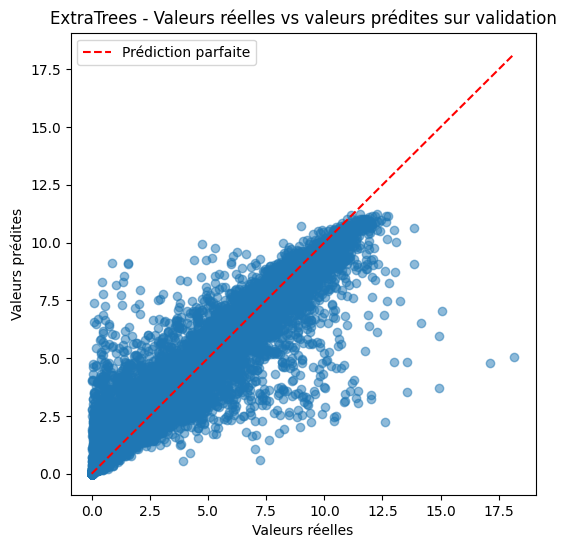

In [39]:
# ==============================================================
# Visualisation: valeurs réelles vs valeurs prédites Extratrees
# ==============================================================

# Cette cellule compare les valeurs réelles de la cible avec les prédictions
# du modèle Extratrees sur l'ensemble de validation.

plt.figure(figsize=(6, 6))

# Nuage de points:
# axe x: valeurs réelles
# axe y: valeurs prédites par Extratrees
plt.scatter(y_valid, y_pred_valid_etr, alpha=0.5)

# Ligne idéale y = x
# Si les prédictions étaient parfaites, tous les points seraient sur cette ligne
min_val = min(y_valid.min(), y_pred_valid_etr.min())
max_val = max(y_valid.max(), y_pred_valid_etr.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Prédiction parfaite"
)

# Titres et labels
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTrees - Valeurs réelles vs valeurs prédites sur validation")

# Légende
plt.legend()

# Affichage
plt.show()

Le modèle `ExtraTreesRegressor` final présente un bon compromis entre performance et généralisation.

Après régularisation et optimisation des hyperparamètres avec Optuna:

- l'overfitting a été significativement réduit (écart train / validation plus faible),
- la performance en validation reste stable (R² ≈ 0.885),
- le modèle est désormais plus robuste et moins sensible aux variations des données.

Le modèle final est donc fiable pour la prédiction, avec une bonne capacité de généralisation sans sur-apprentissage excessif.

### 6.4 RandomForestRegressor

RandomForestRegressor est un modèle d'ensemble basé sur plusieurs arbres de décision.

Contrairement à ExtraTreesRegressor, les arbres d'une forêt aléatoire sont construits à partir de sous-échantillons des données, avec une sélection aléatoire de variables à chaque division.  
Cette diversité entre les arbres permet de réduire la variance et d'obtenir un modèle généralement robuste.

Ce modèle est intéressant dans ce contexte, car il peut capturer des relations non linéaires et des interactions entre les variables météorologiques, temporelles et régionales.

Cependant, RandomForestRegressor peut surapprendre si les arbres sont trop profonds ou si les paramètres de régularisation, comme `min_samples_leaf`, `min_samples_split` ou `max_depth`, ne sont pas suffisamment contrôlés.

L'objectif est donc de vérifier si RandomForestRegressor constitue une alternative robuste aux modèles précédents, notamment ExtraTreesRegressor, LightGBM et XGBoost.

#### 6.4.1 Optimisation des hyperparamètres RandomForestRegressor avec Optuna

RandomForestRegressor est optimisé avec Optuna en utilisant les folds temporels définis manuellement.

Comme pour les modèles précédents, la sélection repose sur la MAE moyenne de validation croisée temporelle et sur le contrôle du gap train/validation.

In [15]:
# =============
# RANDOM FOREST
# =============

# Copie des ensembles utilisés pour RandomForestRegressor
X_train_rf = X_train.copy()
X_valid_rf = X_valid.copy()


# ===========================================================
# Évaluation d'une combinaison d'hyperparamètres RandomForest
# ===========================================================

def evaluate_params_rf(params, X, y, trial=None):

    # Listes pour stocker les métriques de chaque fold
    maes_valid = []
    maes_train = []

    rmses_valid = []
    rmses_train = []

    r2_trains = []
    r2_valids = []

    gaps = []

    # Génération des folds temporels manuels
    folds = get_folds(X, y)

    # Boucle sur les folds
    for step, (X_tr, X_v, y_tr, y_v) in enumerate(folds):

        # Création du modèle avec les paramètres proposés par Optuna
        model = RandomForestRegressor(**params)

        # Entraînement sur la période passée du fold
        model.fit(X_tr, y_tr)

        # Prédictions sur train et validation du fold
        pred_train = model.predict(X_tr)
        pred_valid = model.predict(X_v)

        # MAE train et validation
        mae_train = mean_absolute_error(y_tr, pred_train)
        mae_valid = mean_absolute_error(y_v, pred_valid)

        # RMSE train et validation
        rmse_train = np.sqrt(mean_squared_error(y_tr, pred_train))
        rmse_valid = np.sqrt(mean_squared_error(y_v, pred_valid))

        # R² train et validation
        r2_train = r2_score(y_tr, pred_train)
        r2_valid = r2_score(y_v, pred_valid)

        # Gap train-validation
        # Un grand gap peut indiquer un surapprentissage
        gap = max(0, mae_valid - mae_train)

        # Stockage des métriques
        maes_train.append(mae_train)
        maes_valid.append(mae_valid)

        rmses_train.append(rmse_train)
        rmses_valid.append(rmse_valid)

        r2_trains.append(r2_train)
        r2_valids.append(r2_valid)

        gaps.append(gap)

    # Moyennes des métriques sur tous les folds
    mean_mae_valid = np.mean(maes_valid)
    mean_mae_train = np.mean(maes_train)

    std_mae_valid = np.std(maes_valid)
    std_mae_train = np.std(maes_train)

    mean_rmse_valid = np.mean(rmses_valid)
    mean_rmse_train = np.mean(rmses_train)

    mean_r2_valid = np.mean(r2_valids)
    mean_r2_train = np.mean(r2_trains)

    mean_gap = np.mean(gaps)

    # Pourcentage d'overfitting
    gap_pct = (
        100 * max(0, mean_mae_valid - mean_mae_train) / mean_mae_valid
        if mean_mae_valid != 0 else np.nan
    )

    # Sauvegarde des informations utiles dans Optuna
    if trial is not None:
        trial.set_user_attr("mean_mae_valid", mean_mae_valid)
        trial.set_user_attr("mean_mae_train", mean_mae_train)

        trial.set_user_attr("std_mae_valid", std_mae_valid)
        trial.set_user_attr("std_mae_train", std_mae_train)

        trial.set_user_attr("mean_rmse_valid", mean_rmse_valid)
        trial.set_user_attr("mean_rmse_train", mean_rmse_train)

        trial.set_user_attr("mean_r2_valid", mean_r2_valid)
        trial.set_user_attr("mean_r2_train", mean_r2_train)

        trial.set_user_attr("mean_gap", mean_gap)
        trial.set_user_attr("std_gap", np.std(gaps))
        trial.set_user_attr("max_gap", np.max(gaps))
        trial.set_user_attr("overfit_gap_pct", gap_pct)

    # Optuna minimise ces deux objectifs
    return mean_mae_valid, mean_gap

# ====================================================
# Fonction objective Optuna pour RandomForestRegressor
# ====================================================

def objective_rf(trial):

    params = {
        # Nombre d'arbres dans la forêt
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),

        # Profondeur maximale des arbres
        "max_depth": trial.suggest_int("max_depth", 5, 30),

        # Nombre minimum d'échantillons nécessaires pour diviser un nœud
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 30),

        # Nombre minimum d'échantillons dans une feuille
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),

        # Fraction des variables utilisées à chaque division
        "max_features": trial.suggest_float("max_features", 0.2, 0.7),

        # RandomForest utilise ici le bootstrap
        "bootstrap": True,

        # Fraction des observations utilisées dans chaque échantillon bootstrap
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),

        "random_state": 42,
        "n_jobs": 1
    }

    return evaluate_params_rf(
        params=params,
        X=X_dev,
        y=y_dev,
        trial=trial
    )

# =========================================================
# Création et lancement de l'étude Optuna pour RandomForest
# =========================================================

study_rf = optuna.create_study(
    study_name="study_rf_new",
    storage=f"sqlite:///{filepath_output}study_rf_new.db",
    load_if_exists=True,
    directions=["minimize", "minimize"],
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=60,
        seed=42
    )
)

# Lancement de l'optimisation
study_rf.optimize(
    objective_rf,
    n_trials=300,
    n_jobs=-1
)

[I 2026-04-27 14:07:18,524] A new study created in RDB with name: study_rf_new
[I 2026-04-27 14:10:14,402] Trial 3 finished with values: [0.6094337897911345, 0.025306006760483335] and parameters: {'n_estimators': 124, 'max_depth': 5, 'min_samples_split': 16, 'min_samples_leaf': 33, 'max_features': 0.4140163772912422, 'max_samples': 0.8956068466531935}.
[I 2026-04-27 14:10:43,852] Trial 7 finished with values: [0.4974493595023902, 0.04034375560988791] and parameters: {'n_estimators': 179, 'max_depth': 27, 'min_samples_split': 17, 'min_samples_leaf': 47, 'max_features': 0.21180971504704016, 'max_samples': 0.5468237702740466}.
[I 2026-04-27 14:10:44,571] Trial 9 finished with values: [0.5391266860696373, 0.03552253184575213] and parameters: {'n_estimators': 230, 'max_depth': 7, 'min_samples_split': 22, 'min_samples_leaf': 41, 'max_features': 0.20035948356304562, 'max_samples': 0.752650523346265}.
[I 2026-04-27 14:13:22,883] Trial 13 finished with values: [0.508086289388113, 0.043679517000

#### 6.4.2 Sélection du meilleur essai Optuna et évaluation du modèle RandomForestRegressor

Après l'optimisation, l'étude Optuna est rechargée afin de sélectionner le meilleur compromis parmi les essais du front de Pareto.

Le modèle RandomForestRegressor retenu est ensuite entraîné sur l'ensemble `train`, puis évalué sur les ensembles `train` et `valid`.

Les métriques obtenues sont ajoutées au tableau global des résultats afin de comparer RandomForestRegressor aux modèles précédents.

In [40]:
# =============================================================
# Sélection du meilleur essai Optuna et évaluation RandomForest
# =============================================================

# Copie des ensembles utilisés pour RandomForestRegressor
X_train_rf = X_train.copy()
X_valid_rf = X_valid.copy()

# Chargement de l'étude Optuna déjà optimisée
study_rf = optuna.load_study(
    study_name="study_rf_new",
    storage=f"sqlite:///{filepath_output}study_rf_new.db"
)


# ==============================================
# Sélection du meilleur essai du front de Pareto
# ==============================================

# Optuna retourne plusieurs meilleurs essais car l'étude est multi-objective
rf_trials = study_rf.best_trials

# Choix d'un compromis:
# - faible MAE moyenne en validation croisée temporelle
# - pénalité si le gap relatif dépasse 5 %
best_trial_rf = min(
    rf_trials,
    key=lambda t: t.values[0] + 50 * max(0, (t.values[1] / t.values[0]) - 0.05)
)

print("Selected trial:")
print(f"MAE = {best_trial_rf.values[0]}")
print(f"GAP = {best_trial_rf.values[1]}")


# ==========================================
# Récupération des meilleurs hyperparamètres
# ==========================================

# Copie des paramètres pour éviter de modifier directement l'objet Optuna
best_params_rf = best_trial_rf.params.copy()

print("Best_params_rf:", best_params_rf)


# =========================================
# Entraînement du modèle RandomForest final
# =========================================

best_model_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params_rf
)

# Entraînement sur l'ensemble train
best_model_rf.fit(X_train_rf, y_train)


# ==================================
# Évaluation sur train et validation
# ==================================

# Prédictions
y_pred_train_rf = best_model_rf.predict(X_train_rf)
y_pred_valid_rf = best_model_rf.predict(X_valid_rf)

# Métriques train
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
r2_train_rf = r2_score(y_train, y_pred_train_rf)
nmae_train_rf = calculer_nmae(y_train, y_pred_train_rf)

# Métriques validation
mae_valid_rf = mean_absolute_error(y_valid, y_pred_valid_rf)
rmse_valid_rf = np.sqrt(mean_squared_error(y_valid, y_pred_valid_rf))
r2_valid_rf = r2_score(y_valid, y_pred_valid_rf)
nmae_valid_rf = calculer_nmae(y_valid, y_pred_valid_rf)

# Pourcentage d'overfitting final
overfit_pct_rf = (
    100 * max(0, mae_valid_rf - mae_train_rf) / mae_valid_rf
    if mae_valid_rf != 0 else np.nan
)


# =======================
# Affichage des résultats
# =======================

print("\n--- Résultats RandomForestRegressor ---")

print(f"MAE valid_rf     : {mae_valid_rf}")
print(f"MAE train_rf     : {mae_train_rf}")

print(f"NMAE valid_rf    : {nmae_valid_rf:.3f} %")
print(f"NMAE train_rf    : {nmae_train_rf:.3f} %")

print(f"RMSE valid_rf    : {rmse_valid_rf}")
print(f"RMSE train_rf    : {rmse_train_rf}")

print(f"R² valid_rf      : {r2_valid_rf}")
print(f"R² train_rf      : {r2_train_rf}")

print(f"Overfitting CV   : {best_trial_rf.user_attrs['overfit_gap_pct']:.2f} %")
print(f"Overfitting final: {overfit_pct_rf:.2f} %")

# MAE moyenne obtenue pendant la validation croisée temporelle
MAE_CV_moyenne_rf = best_trial_rf.user_attrs["mean_mae_valid"]

print("MAE_CV_moyenne_rf:", MAE_CV_moyenne_rf)


# =====================================
# Ajout au tableau global des résultats
# =====================================

# Supprimer une ancienne ligne RandomForest si elle existe déjà
resultats = [
    r for r in resultats
    if r["Modèle"] != "RandomForestRegressor"
]

# Ajout du modèle RandomForest au tableau global
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_rf,
        y_valid,
        y_pred_valid_rf,
        nom_modele="RandomForestRegressor",
        MAE_CV_moyenne=MAE_CV_moyenne_rf
    )
)

# Tableau comparatif final, trié par performance sur validation
resultats_df = pd.DataFrame(resultats).sort_values("MAE_valid")

display(resultats_df)

Selected trial:
MAE = 0.5579337742049324
GAP = 0.02829186739127665
Best_params_rf: {'n_estimators': 247, 'max_depth': 6, 'min_samples_split': 16, 'min_samples_leaf': 24, 'max_features': 0.6825494585336842, 'max_samples': 0.5335843729474861}

--- Résultats RandomForestRegressor ---
MAE valid_rf      : 0.5407187945125036
MAE train_rf      : 0.5267106526980013
NMAE valid_rf     : 22.699 %
NMAE train_rf     : 21.574 %
RMSE valid_rf     : 1.0658359534908841
RMSE train_rf     : 1.0529928691204677
R² valid_rf       : 0.8908251114836061
R² train_rf       : 0.8987823300740615
Overfitting CV    : 5.07 %
Overfitting final : 2.59 %
MAE_CV_moyenne_rf: 0.5579337742049324


,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
5,LGBMRegressor,0.45,18.23,0.93,0.92,0.48,20.35,1.00,0.90,0.49,0.04,0.02
7,ExtraTreesRegressor,0.46,19.02,0.98,0.91,0.49,20.57,1.01,0.90,0.59,0.03,0.01
6,XGBRegressor,0.48,19.67,0.98,0.91,0.50,21.10,1.01,0.90,0.51,0.02,0.01
8,RandomForestRegressor,0.53,21.57,1.05,0.90,0.54,22.70,1.07,0.89,0.56,0.01,0.01
4,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01


In [41]:
# ===========================================================
# Sauvegarde et rechargement du meilleur modèle RandomForest
# ===========================================================

# Chemin complet du fichier de sauvegarde
model_path_rf = best_models_path + "best_model_rf.joblib"

# Sauvegarde du meilleur modèle RandomForest entraîné
joblib.dump(best_model_rf, model_path_rf)

print("Modèle RandomForest sauvegardé dans:", model_path_rf)

# Rechargement du modèle sauvegardé
best_model_rf = joblib.load(model_path_rf)

print("Modèle RandomForest rechargé avec succès.")

Modèle RandomForest sauvegardé dans : ../../data/local_data/output/output_modelisation/Best_Models/best_model_rf.joblib
Modèle RandomForest rechargé avec succès.


#### 6.4.3 Visualisation des prédictions RandomForest

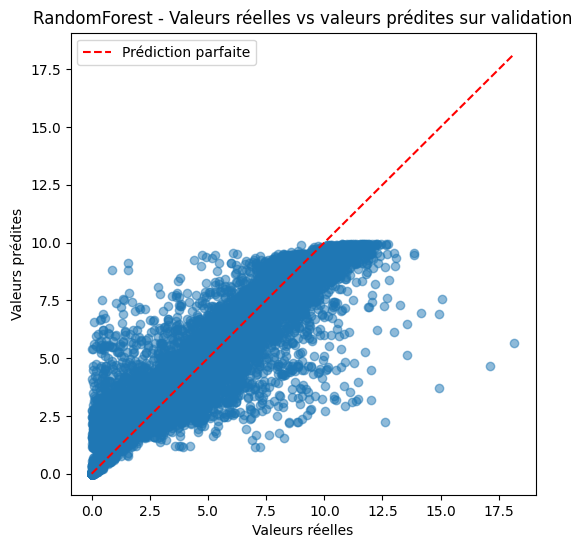

In [42]:
# ================================================================
# Visualisation: valeurs réelles vs valeurs prédites RandomForest
# ================================================================

# Cette cellule compare les valeurs réelles de la cible avec les prédictions
# du modèle RandomForest sur l'ensemble de validation.

plt.figure(figsize=(6, 6))

# Nuage de points:
# axe x: valeurs réelles
# axe y: valeurs prédites par RandomForest
plt.scatter(y_valid, y_pred_valid_rf, alpha=0.5)

# Ligne idéale y = x
# Si les prédictions étaient parfaites, tous les points seraient sur cette ligne
min_val = min(y_valid.min(), y_pred_valid_rf.min())
max_val = max(y_valid.max(), y_pred_valid_rf.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Prédiction parfaite"
)

# Titres et labels
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("RandomForest - Valeurs réelles vs valeurs prédites sur validation")

# Légende
plt.legend()

# Affichage
plt.show()

### 6.5 HistGradientBoosting

HistGradientBoostingRegressor est une implémentation efficace du gradient boosting proposée par scikit-learn.

Comme les autres modèles de boosting, il construit progressivement plusieurs arbres afin de corriger les erreurs des modèles précédents.  
Il utilise une approche basée sur des histogrammes, ce qui permet d'accélérer l'entraînement sur des données tabulaires.

Ce modèle est intéressant ici comme alternative supplémentaire à LightGBM et XGBoost.  
Il permet de comparer plusieurs approches d'arbres boostés dans les mêmes conditions expérimentales.

L'objectif est donc d'évaluer si HistGradientBoostingRegressor peut offrir une performance compétitive par rapport aux autres modèles avancés déjà testés.

#### 6.5.1 Optimisation des hyperparamètres HistGradientBoostingRegressor avec Optuna

HistGradientBoostingRegressor est optimisé avec Optuna en utilisant les folds temporels définis manuellement.

Comme pour les modèles précédents, la sélection repose sur la MAE moyenne de validation croisée temporelle et sur le contrôle du gap train/validation.

In [40]:
# ===============================
# HIST GRADIENT BOOSTING REGRESSOR
# ===============================

from sklearn.ensemble import HistGradientBoostingRegressor

# Copie des ensembles utilisés pour HistGradientBoostingRegressor
X_train_hgb = X_train.copy()
X_valid_hgb = X_valid.copy()


# ===================================================================
# Évaluation d'une combinaison d'hyperparamètres HistGradientBoosting
# ===================================================================

def evaluate_params_hgb(params, X, y, trial=None):

    # Listes pour stocker les métriques de chaque fold
    maes_valid = []
    maes_train = []

    rmses_valid = []
    rmses_train = []

    r2_trains = []
    r2_valids = []

    gaps = []

    # Génération des folds temporels manuels
    folds = get_folds(X, y)

    # Boucle sur les folds
    for step, (X_tr, X_v, y_tr, y_v) in enumerate(folds):

        # Création du modèle avec les paramètres proposés par Optuna
        model = HistGradientBoostingRegressor(**params)

        # Entraînement sur la période passée du fold
        model.fit(X_tr, y_tr)

        # Prédictions sur train et validation du fold
        pred_train = model.predict(X_tr)
        pred_valid = model.predict(X_v)

        # MAE train et validation
        mae_train = mean_absolute_error(y_tr, pred_train)
        mae_valid = mean_absolute_error(y_v, pred_valid)

        # RMSE train et validation
        rmse_train = np.sqrt(mean_squared_error(y_tr, pred_train))
        rmse_valid = np.sqrt(mean_squared_error(y_v, pred_valid))

        # R² train et validation
        r2_train = r2_score(y_tr, pred_train)
        r2_valid = r2_score(y_v, pred_valid)

        # Gap train-validation
        gap = max(0, mae_valid - mae_train)

        # Stockage des métriques du fold
        maes_train.append(mae_train)
        maes_valid.append(mae_valid)

        rmses_train.append(rmse_train)
        rmses_valid.append(rmse_valid)

        r2_trains.append(r2_train)
        r2_valids.append(r2_valid)

        gaps.append(gap)

    # Moyennes des métriques sur tous les folds
    mean_mae_valid = np.mean(maes_valid)
    mean_mae_train = np.mean(maes_train)

    std_mae_valid = np.std(maes_valid)
    std_mae_train = np.std(maes_train)

    mean_rmse_valid = np.mean(rmses_valid)
    mean_rmse_train = np.mean(rmses_train)

    mean_r2_valid = np.mean(r2_valids)
    mean_r2_train = np.mean(r2_trains)

    mean_gap = np.mean(gaps)

    # Pourcentage d'overfitting
    gap_pct = (
        100 * max(0, mean_mae_valid - mean_mae_train) / mean_mae_valid
        if mean_mae_valid != 0 else np.nan
    )

    # Sauvegarde des informations utiles dans Optuna
    if trial is not None:
        trial.set_user_attr("mean_mae_valid", mean_mae_valid)
        trial.set_user_attr("mean_mae_train", mean_mae_train)

        trial.set_user_attr("std_mae_valid", std_mae_valid)
        trial.set_user_attr("std_mae_train", std_mae_train)

        trial.set_user_attr("mean_rmse_valid", mean_rmse_valid)
        trial.set_user_attr("mean_rmse_train", mean_rmse_train)

        trial.set_user_attr("mean_r2_valid", mean_r2_valid)
        trial.set_user_attr("mean_r2_train", mean_r2_train)

        trial.set_user_attr("mean_gap", mean_gap)
        trial.set_user_attr("std_gap", np.std(gaps))
        trial.set_user_attr("max_gap", np.max(gaps))
        trial.set_user_attr("overfit_gap_pct", gap_pct)

    # Optuna minimise ces deux objectifs
    return mean_mae_valid, mean_gap

# ============================================================
# Fonction objective Optuna pour HistGradientBoostingRegressor
# ============================================================

def objective_hgb(trial):
    
    params = {
        # Fonction de perte adaptée à la MAE
        "loss": "absolute_error",

        # Taux d'apprentissage
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),

        # Nombre d'itérations de boosting
        "max_iter": trial.suggest_int(
            "max_iter", 100, 600
        ),

        # Complexité des arbres
        "max_leaf_nodes": trial.suggest_int(
            "max_leaf_nodes", 15, 63
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 3, 12
        ),

        # Régularisation et contrôle du surapprentissage
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 10, 100
        ),

        "l2_regularization": trial.suggest_float(
            "l2_regularization", 0.0, 5.0
        ),

        # Nombre de bins pour la discrétisation des variables continues
        "max_bins": trial.suggest_int(
            "max_bins", 64, 255
        ),

        "random_state": 42,
        "verbose": 0
    }

    return evaluate_params_hgb(
        params=params,
        X=X_dev,
        y=y_dev,
        trial=trial
    )

# =================================================================
# Création et lancement de l'étude Optuna pour HistGradientBoosting
# =================================================================

study_hgb = optuna.create_study(
    study_name="study_hgb_new",
    storage=f"sqlite:///{filepath_output}study_hgb_new.db",
    load_if_exists=True,
    directions=["minimize", "minimize"],
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=60,
        seed=42
    )
)

# Lancement de l'optimisation
study_hgb.optimize(
    objective_hgb,
    n_trials=150,
    n_jobs=-1
)

[I 2026-04-27 21:36:37,052] A new study created in RDB with name: study_hgb_new
[I 2026-04-27 21:37:10,263] Trial 8 finished with values: [0.5822330752624879, 0.021174438153010927] and parameters: {'learning_rate': 0.018458846946140264, 'max_iter': 257, 'max_leaf_nodes': 38, 'max_depth': 3, 'min_samples_leaf': 58, 'l2_regularization': 0.9437707051501593, 'max_bins': 135}.
[I 2026-04-27 21:37:11,455] Trial 0 finished with values: [0.5584203459267982, 0.02658144421367717] and parameters: {'learning_rate': 0.024101076539928552, 'max_iter': 149, 'max_leaf_nodes': 26, 'max_depth': 4, 'min_samples_leaf': 22, 'l2_regularization': 1.3369363518526278, 'max_bins': 110}.
[I 2026-04-27 21:37:16,608] Trial 7 finished with values: [0.4981129444896892, 0.025105619669050352] and parameters: {'learning_rate': 0.09446304445060125, 'max_iter': 316, 'max_leaf_nodes': 53, 'max_depth': 3, 'min_samples_leaf': 27, 'l2_regularization': 4.1593063283434635, 'max_bins': 107}.
[I 2026-04-27 21:37:20,963] Trial 3 f

#### 6.5.2 Sélection du meilleur essai Optuna et évaluation du modèle HistGradientBoostingRegressor

Après l'optimisation, l'étude Optuna est rechargée afin de sélectionner le meilleur compromis parmi les essais du front de Pareto.

Le modèle HistGradientBoostingRegressor retenu est ensuite entraîné sur l'ensemble `train`, puis évalué sur les ensembles `train` et `valid`.

Les métriques obtenues sont ajoutées au tableau global des résultats afin de comparer HistGradientBoostingRegressor aux modèles précédents.

In [43]:
# ============================================================
# Sélection du meilleur essai Optuna et évaluation HistGradientBoosting
# ============================================================

# Copie des ensembles utilisés pour HistGradientBoostingRegressor
X_train_hgb = X_train.copy()
X_valid_hgb = X_valid.copy()

# Chargement de l'étude Optuna déjà optimisée
study_hgb = optuna.load_study(
    study_name="study_hgb_new",
    storage=f"sqlite:///{filepath_output}study_hgb_new.db"
)


# ============================================================
# Sélection du meilleur essai du front de Pareto
# ============================================================

# Optuna retourne plusieurs meilleurs essais car l'étude est multi-objective
hgb_trials = study_hgb.best_trials

# Choix d'un compromis:
# - faible MAE moyenne en validation croisée temporelle
# - pénalité si le gap relatif dépasse 5 %
best_trial_hgb = min(
    hgb_trials,
    key=lambda t: t.values[0] + 50 * max(0, (t.values[1] / t.values[0]) - 0.05)
)

print("Selected trial:")
print(f"MAE = {best_trial_hgb.values[0]}")
print(f"GAP = {best_trial_hgb.values[1]}")


# ============================================================
# Récupération des meilleurs hyperparamètres
# ============================================================

# Copie des paramètres pour éviter de modifier directement l'objet Optuna
best_params_hgb = best_trial_hgb.params.copy()

# Ajout des paramètres fixes utilisés pendant l'optimisation
best_params_hgb["loss"] = "absolute_error"
best_params_hgb["early_stopping"] = False
best_params_hgb["random_state"] = 42
best_params_hgb["verbose"] = 0

print("Best_params_hgb:", best_params_hgb)


# ============================================================
# Entraînement du modèle HistGradientBoosting final
# ============================================================

best_model_hgb = HistGradientBoostingRegressor(
    **best_params_hgb
)

# Entraînement sur l'ensemble train
best_model_hgb.fit(X_train_hgb, y_train)


# ============================================================
# Évaluation sur train et validation
# ============================================================

# Prédictions
y_pred_train_hgb = best_model_hgb.predict(X_train_hgb)
y_pred_valid_hgb = best_model_hgb.predict(X_valid_hgb)

# Métriques train
mae_train_hgb = mean_absolute_error(y_train, y_pred_train_hgb)
rmse_train_hgb = np.sqrt(mean_squared_error(y_train, y_pred_train_hgb))
r2_train_hgb = r2_score(y_train, y_pred_train_hgb)
nmae_train_hgb = calculer_nmae(y_train, y_pred_train_hgb)

# Métriques validation
mae_valid_hgb = mean_absolute_error(y_valid, y_pred_valid_hgb)
rmse_valid_hgb = np.sqrt(mean_squared_error(y_valid, y_pred_valid_hgb))
r2_valid_hgb = r2_score(y_valid, y_pred_valid_hgb)
nmae_valid_hgb = calculer_nmae(y_valid, y_pred_valid_hgb)

# Pourcentage d'overfitting final
overfit_pct_hgb = (
    100 * max(0, mae_valid_hgb - mae_train_hgb) / mae_valid_hgb
    if mae_valid_hgb != 0 else np.nan
)


# ============================================================
# Affichage des résultats
# ============================================================

print("\n--- Résultats HistGradientBoostingRegressor ---")

print(f"MAE valid_hgb     : {mae_valid_hgb}")
print(f"MAE train_hgb     : {mae_train_hgb}")

print(f"NMAE valid_hgb    : {nmae_valid_hgb:.3f} %")
print(f"NMAE train_hgb    : {nmae_train_hgb:.3f} %")

print(f"RMSE valid_hgb    : {rmse_valid_hgb}")
print(f"RMSE train_hgb    : {rmse_train_hgb}")

print(f"R² valid_hgb      : {r2_valid_hgb}")
print(f"R² train_hgb      : {r2_train_hgb}")

print(f"Overfitting CV    : {best_trial_hgb.user_attrs['overfit_gap_pct']:.2f} %")
print(f"Overfitting final : {overfit_pct_hgb:.2f} %")

# MAE moyenne obtenue pendant la validation croisée temporelle
MAE_CV_moyenne_hgb = best_trial_hgb.user_attrs["mean_mae_valid"]

print("MAE_CV_moyenne_hgb:", MAE_CV_moyenne_hgb)


# ============================================================
# Ajout au tableau global des résultats
# ============================================================

# Supprimer une ancienne ligne HistGradientBoosting si elle existe déjà
resultats = [
    r for r in resultats
    if r["Modèle"] != "HistGradientBoostingRegressor"
]

# Ajout du modèle HistGradientBoosting au tableau global
resultats.append(
    calculer_metriques(
        y_train,
        y_pred_train_hgb,
        y_valid,
        y_pred_valid_hgb,
        nom_modele="HistGradientBoostingRegressor",
        MAE_CV_moyenne=MAE_CV_moyenne_hgb
    )
)

# Tableau comparatif final, trié par performance sur validation
resultats_df = pd.DataFrame(resultats).sort_values("MAE_valid")

display(resultats_df)

Selected trial:
MAE = 0.49207247538076204
GAP = 0.023364241702935454
Best_params_hgb: {'learning_rate': 0.0365442372934189, 'max_iter': 236, 'max_leaf_nodes': 35, 'max_depth': 4, 'min_samples_leaf': 23, 'l2_regularization': 0.4744445741439031, 'max_bins': 92, 'loss': 'absolute_error', 'early_stopping': False, 'random_state': 42, 'verbose': 0}

--- Résultats HistGradientBoostingRegressor ---
MAE valid_hgb      : 0.4916395196462129
MAE train_hgb      : 0.47180002015773587
NMAE valid_hgb     : 20.639 %
NMAE train_hgb     : 19.325 %
RMSE valid_hgb     : 1.0322929970590453
RMSE train_hgb     : 1.0213978657874665
R² valid_hgb       : 0.8975886744795668
R² train_hgb       : 0.9047652672795696
Overfitting CV     : 4.65 %
Overfitting final  : 4.04 %
MAE_CV_moyenne_hgb: 0.49207247538076204


,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
5,LGBMRegressor,0.45,18.23,0.93,0.92,0.48,20.35,1.00,0.90,0.49,0.04,0.02
7,ExtraTreesRegressor,0.46,19.02,0.98,0.91,0.49,20.57,1.01,0.90,0.59,0.03,0.01
9,HistGradientBoostingRegressor,0.47,19.32,1.02,0.90,0.49,20.64,1.03,0.90,0.49,0.02,0.01
6,XGBRegressor,0.48,19.67,0.98,0.91,0.50,21.10,1.01,0.90,0.51,0.02,0.01
8,RandomForestRegressor,0.53,21.57,1.05,0.90,0.54,22.70,1.07,0.89,0.56,0.01,0.01
4,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01
1,Régression linéaire simple,1.13,46.16,2.01,0.63,1.08,45.16,1.98,0.62,NaN,0.05,0.01


In [44]:
# =====================================================================
# Sauvegarde et rechargement du meilleur modèle HistGradientBoosting
# =====================================================================

# Chemin complet du fichier de sauvegarde
model_path_hgb = best_models_path + "best_model_hgb.joblib"

# Sauvegarde du meilleur modèle HistGradientBoosting entraîné
joblib.dump(best_model_hgb, model_path_hgb)

print("Modèle HistGradientBoosting sauvegardé dans:", model_path_hgb)

# Rechargement du modèle sauvegardé
best_model_hgb = joblib.load(model_path_hgb)

print("Modèle HistGradientBoosting rechargé avec succès.")

Modèle HistGradientBoosting sauvegardé dans : ../../data/local_data/output/output_modelisation/Best_Models/best_model_hgb.joblib
Modèle HistGradientBoosting rechargé avec succès.


#### 6.5.3 Visualisation des prédictions HistGradientBoosting

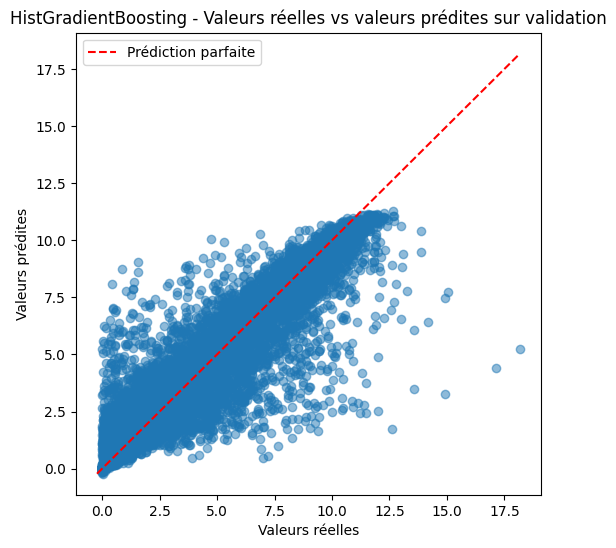

In [45]:
# ========================================================================
# Visualisation: valeurs réelles vs valeurs prédites HistGradientBoosting
# ========================================================================

# Cette cellule compare les valeurs réelles de la cible avec les prédictions
# du modèle HistGradientBoosting sur l'ensemble de validation.

plt.figure(figsize=(6, 6))

# Nuage de points:
# axe x: valeurs réelles
# axe y: valeurs prédites par HistGradientBoosting
plt.scatter(y_valid, y_pred_valid_hgb, alpha=0.5)

# Ligne idéale y = x
# Si les prédictions étaient parfaites, tous les points seraient sur cette ligne
min_val = min(y_valid.min(), y_pred_valid_hgb.min())
max_val = max(y_valid.max(), y_pred_valid_hgb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Prédiction parfaite"
)

# Titres et labels
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("HistGradientBoosting - Valeurs réelles vs valeurs prédites sur validation")

# Légende
plt.legend()

# Affichage
plt.show()

## 7. Réseau de neurones

On teste ensuite un réseau de neurones de type **MLP** (*Multi-Layer Perceptron*).

Ce modèle peut capturer des relations non linéaires complexes entre les variables explicatives et la cible.  
Il est donc intéressant comme approche complémentaire aux modèles d'arbres et de boosting déjà testés.

Cependant, un MLP demande plus de précautions, notamment la standardisation des variables, le choix de l'architecture, la régularisation, le dropout, l'early stopping et la surveillance du gap train/validation.

L'objectif est de comparer le MLP aux modèles précédents, tout en contrôlant le risque de surapprentissage.

### 7.1 Optimisation des hyperparamètres MLP avec Optuna

Le MLP est optimisé avec Optuna en utilisant les folds temporels définis manuellement.

Comme pour les modèles précédents, la sélection repose sur la MAE moyenne de validation croisée temporelle et sur le contrôle du gap train/validation.

La standardisation, la régularisation, le dropout et l'early stopping sont utilisés afin de limiter le surapprentissage.

In [46]:
# ============================
# Construction du modèle MLP
# ============================

# Fixer les graines aléatoires pour rendre les résultats plus reproductibles
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)


def build_pyramid_mlp(input_dim, hidden_layers, activation, dropout_rate, learning_rate, l2_reg):
    """
    Construit un réseau de neurones MLP de type pyramidal.

    Paramètres
    ----------
    input_dim: int
        Nombre de variables explicatives en entrée.

    hidden_layers: list
        Liste contenant le nombre de neurones dans chaque couche cachée.
        Exemple: [256, 128, 64]

    activation: str
        Fonction d'activation utilisée dans les couches cachées.

    dropout_rate: float
        Taux de dropout utilisé pour limiter le surapprentissage.

    learning_rate: float
        Taux d'apprentissage de l'optimiseur Adam.

    l2_reg: float
        Coefficient de régularisation L2 appliqué aux poids du réseau.

    Retour
    ------
    model: keras.Model
        Modèle MLP compilé.
    """

    # Initialisation du modèle séquentiel
    model = keras.Sequential()

    # Couche d'entrée
    model.add(layers.Input(shape=(input_dim,)))

    # Choix de l'initialisation des poids selon la fonction d'activation
    # he_normal est adapté à ReLU
    # glorot_uniform est plus général pour d'autres activations
    if activation == "relu":
        initializer = "he_normal"
    else:
        initializer = "glorot_uniform"

    # Construction des couches cachées
    for units in hidden_layers:

        # Couche dense avec régularisation L2
        # use_bias=False car BatchNormalization ajoute déjà un décalage appris
        model.add(
            layers.Dense(
                units,
                use_bias=False,
                kernel_initializer=initializer,
                kernel_regularizer=regularizers.l2(l2_reg)
            )
        )

        # Normalisation des activations pour stabiliser l'entraînement
        model.add(layers.BatchNormalization())

        # Fonction d'activation non linéaire
        model.add(layers.Activation(activation))

        # Dropout pour limiter le surapprentissage
        model.add(layers.Dropout(dropout_rate))

    # Couche de sortie
    # Une seule sortie continue pour la régression
    model.add(
        layers.Dense(
            1,
            activation="linear",
            kernel_initializer="glorot_uniform"
        )
    )

    # Compilation du modèle
    # La perte MAE est utilisée car c'est la métrique principale du notebook
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mae",
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

In [11]:
# ============================================================
# Optimisation du MLP avec Optuna et folds temporels manuels
# ============================================================

# ------------------------------------------------------------
# Évaluation d'une combinaison d'hyperparamètres MLP
# ------------------------------------------------------------

def evaluate_params_keras_mlp(params, X, y, trial=None):
    """
    Évalue une combinaison d'hyperparamètres du MLP
    sur les folds temporels définis manuellement.

    Pour chaque fold:
    - les données train sont séparées en train interne et validation interne ;
    - la validation interne sert uniquement à l'early stopping ;
    - le fold de validation temporelle reste intact pour l'évaluation finale du fold.
    """

    # Listes pour stocker les métriques de chaque fold
    maes_valid = []
    maes_train = []

    rmses_valid = []
    rmses_train = []

    r2_trains = []
    r2_valids = []

    gaps = []

    # Génération des folds temporels manuels
    folds = get_folds(X, y)

    # Boucle sur les folds
    for step, (X_tr, X_v, y_tr, y_v) in enumerate(folds):

        # Nettoyage de la session TensorFlow avant chaque entraînement
        tf.keras.backend.clear_session()

        # Graine différente pour chaque fold, mais reproductible
        tf.keras.utils.set_random_seed(SEED + step)

        # Conversion des cibles en arrays numpy
        y_tr_np = np.asarray(y_tr).ravel()
        y_v_np = np.asarray(y_v).ravel()

        # Séparation interne du train du fold pour l'early stopping
        # X_v n'est pas utilisé ici: il reste réservé à l'évaluation du fold
        X_fit, X_es, y_fit, y_es = train_test_split(
            X_tr,
            y_tr_np,
            test_size=0.15,
            random_state=SEED,
            shuffle=False
        )

        # Standardisation à l'intérieur du fold
        # Le scaler est ajusté uniquement sur X_fit
        scaler = StandardScaler()

        X_fit_scaled = scaler.fit_transform(X_fit)
        X_es_scaled = scaler.transform(X_es)
        X_tr_scaled = scaler.transform(X_tr)
        X_v_scaled = scaler.transform(X_v)

        # Construction du modèle MLP avec les paramètres proposés
        model = build_pyramid_mlp(
            input_dim=X_fit_scaled.shape[1],
            hidden_layers=params["hidden_layers"],
            activation=params["activation"],
            dropout_rate=params["dropout_rate"],
            learning_rate=params["learning_rate"],
            l2_reg=params["l2_reg"]
        )

        # Early stopping: arrêt si la MAE de validation interne ne s'améliore plus
        early_stop = keras.callbacks.EarlyStopping(
            monitor="val_mae",
            mode="min",
            patience=30,
            min_delta=1e-4,
            restore_best_weights=True
        )

        # Réduction du learning rate si la validation stagne
        reduce_lr = keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae",
            mode="min",
            factor=0.5,
            patience=10,
            min_delta=1e-4,
            min_lr=1e-6,
            verbose=0
        )

        # Entraînement du modèle
        model.fit(
            X_fit_scaled,
            y_fit,
            validation_data=(X_es_scaled, y_es),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            callbacks=[early_stop, reduce_lr],
            verbose=0,
            shuffle=False
        )

        # Prédictions sur train du fold et validation du fold
        pred_train = model.predict(X_tr_scaled, verbose=0).ravel()
        pred_valid = model.predict(X_v_scaled, verbose=0).ravel()

        # MAE train et validation
        mae_train = mean_absolute_error(y_tr_np, pred_train)
        mae_valid = mean_absolute_error(y_v_np, pred_valid)

        # RMSE train et validation
        rmse_train = np.sqrt(mean_squared_error(y_tr_np, pred_train))
        rmse_valid = np.sqrt(mean_squared_error(y_v_np, pred_valid))

        # R² train et validation
        r2_train = r2_score(y_tr_np, pred_train)
        r2_valid = r2_score(y_v_np, pred_valid)

        # Gap train-validation
        gap = max(0, mae_valid - mae_train)

        # Stockage des métriques
        maes_train.append(mae_train)
        maes_valid.append(mae_valid)

        rmses_train.append(rmse_train)
        rmses_valid.append(rmse_valid)

        r2_trains.append(r2_train)
        r2_valids.append(r2_valid)

        gaps.append(gap)

    # Moyennes des métriques sur tous les folds
    mean_mae_valid = np.mean(maes_valid)
    mean_mae_train = np.mean(maes_train)

    std_mae_valid = np.std(maes_valid)
    std_mae_train = np.std(maes_train)

    mean_rmse_valid = np.mean(rmses_valid)
    mean_rmse_train = np.mean(rmses_train)

    mean_r2_valid = np.mean(r2_valids)
    mean_r2_train = np.mean(r2_trains)

    mean_gap = np.mean(gaps)

    # Pourcentage de gap relatif
    gap_pct = (
        100 * max(0, mean_mae_valid - mean_mae_train) / mean_mae_valid
        if mean_mae_valid != 0 else 0
    )

    # Sauvegarde des informations utiles dans Optuna
    if trial is not None:
        trial.set_user_attr("mean_mae_valid", mean_mae_valid)
        trial.set_user_attr("mean_mae_train", mean_mae_train)

        trial.set_user_attr("std_mae_valid", std_mae_valid)
        trial.set_user_attr("std_mae_train", std_mae_train)

        trial.set_user_attr("mean_rmse_valid", mean_rmse_valid)
        trial.set_user_attr("mean_rmse_train", mean_rmse_train)

        trial.set_user_attr("mean_r2_valid", mean_r2_valid)
        trial.set_user_attr("mean_r2_train", mean_r2_train)

        trial.set_user_attr("mean_gap", mean_gap)
        trial.set_user_attr("std_gap", np.std(gaps))
        trial.set_user_attr("max_gap", np.max(gaps))
        trial.set_user_attr("overfit_gap_pct", gap_pct)

    # Optuna minimise ces deux objectifs
    return mean_mae_valid, mean_gap

# =====================================
# Fonction objective Optuna pour le MLP
# =====================================

def objective_keras_mlp(trial):

    # Choix de l'architecture du réseau
    architecture_name = trial.suggest_categorical(
        "architecture",
        ["128-64", "128-64-32"]
    )

    architecture_map = {
        "128-64": (128, 64),
        "128-64-32": (128, 64, 32)
    }

    # Hyperparamètres testés par Optuna
    params = {
        "hidden_layers": architecture_map[architecture_name],
        "activation": "relu",
        "dropout_rate": trial.suggest_float("dropout_rate", 0.0, 0.2),
        "l2_reg": trial.suggest_float("l2_reg", 1e-8, 1e-4, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256, 512]),
        "epochs": 1000
    }

    # Sauvegarde de l'architecture réelle dans Optuna
    trial.set_user_attr("hidden_layers", params["hidden_layers"])

    return evaluate_params_keras_mlp(
        params=params,
        X=X_dev,
        y=y_dev,
        trial=trial
    )

# ===================================================
# Création et lancement de l'étude Optuna pour le MLP
# ===================================================

study_keras_mlp = optuna.create_study(
    study_name="study_mlp",
    storage=f"sqlite:///{filepath_output}study_mlp.db",
    load_if_exists=True,
    directions=["minimize", "minimize"],
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=20,
        seed=42
    )
)

# Lancement de l'optimisation
study_keras_mlp.optimize(
    objective_keras_mlp,
    n_trials=50,
    n_jobs=1
)

[I 2026-05-13 09:56:16,712] A new study created in RDB with name: study_mlp
[I 2026-05-13 09:58:30,175] Trial 0 finished with values: [0.5465221944969902, 0.022242033283454046] and parameters: {'architecture': '128-64-32', 'dropout_rate': 0.146398788362281, 'l2_reg': 2.4810409748678096e-06, 'learning_rate': 0.0001700037298921101, 'batch_size': 256}.
[I 2026-05-13 10:00:24,890] Trial 1 finished with values: [0.5291097157423322, 0.026937791597290234] and parameters: {'architecture': '128-64', 'dropout_rate': 0.19398197043239887, 'l2_reg': 2.136832907235876e-05, 'learning_rate': 0.00020589728197687926, 'batch_size': 512}.
[I 2026-05-13 10:01:59,436] Trial 2 finished with values: [0.5356255795519207, 0.02681252862545208] and parameters: {'architecture': '128-64', 'dropout_rate': 0.1223705789444759, 'l2_reg': 3.613894271216526e-08, 'learning_rate': 0.00027010527749605503, 'batch_size': 256}.
[I 2026-05-13 10:04:32,708] Trial 3 finished with values: [0.5602396105865627, 0.043690431598191595]

### 7.2 Sélection du meilleur essai Optuna et évaluation du modèle MLP

Après l'optimisation, l'étude Optuna est rechargée afin de sélectionner le meilleur compromis parmi les essais du front de Pareto.

Le modèle MLP retenu est ensuite reconstruit avec les meilleurs hyperparamètres, puis entraîné sur l'ensemble `train`.

Les prédictions sont ensuite évaluées sur les ensembles `train` et `valid`, et les métriques obtenues sont ajoutées au tableau global des résultats afin de comparer le MLP aux modèles précédents.

In [47]:
# ============================================================
# Sélection du meilleur essai Optuna et évaluation du MLP
# ============================================================

# Chargement de l'étude Optuna déjà optimisée
study_keras_mlp = optuna.load_study(
    study_name="study_mlp",
    storage=f"sqlite:///{filepath_output}study_mlp.db"
)


# ============================================================
# Analyse des essais du front de Pareto
# ============================================================

# Optuna retourne plusieurs meilleurs essais car l'étude est multi-objective
pareto_trials = study_keras_mlp.best_trials

rows = []

for t in pareto_trials:
    rows.append({
        "trial": t.number,
        "mae_valid_objective": t.values[0],
        "gap_objective": t.values[1],

        # Métriques stockées pendant l'optimisation
        "mean_mae_train": t.user_attrs.get("mean_mae_train"),
        "mean_mae_valid": t.user_attrs.get("mean_mae_valid"),
        "std_mae_train": t.user_attrs.get("std_mae_train"),
        "std_mae_valid": t.user_attrs.get("std_mae_valid"),
        "mean_rmse_train": t.user_attrs.get("mean_rmse_train"),
        "mean_rmse_valid": t.user_attrs.get("mean_rmse_valid"),
        "mean_r2_train": t.user_attrs.get("mean_r2_train"),
        "mean_r2_valid": t.user_attrs.get("mean_r2_valid"),
        "mean_gap": t.user_attrs.get("mean_gap"),
        "std_gap": t.user_attrs.get("std_gap"),
        "max_gap": t.user_attrs.get("max_gap"),
        "overfit_gap_pct": t.user_attrs.get("overfit_gap_pct"),
        "hidden_layers": t.user_attrs.get("hidden_layers"),

        # Hyperparamètres Optuna
        "architecture": t.params.get("architecture"),
        "dropout_rate": t.params.get("dropout_rate"),
        "l2_reg": t.params.get("l2_reg"),
        "learning_rate": t.params.get("learning_rate"),
        "batch_size": t.params.get("batch_size"),
    })

# Tableau récapitulatif du front de Pareto
df_pareto_mlp = pd.DataFrame(rows)

df_pareto_mlp = df_pareto_mlp.sort_values(
    by=["mae_valid_objective", "gap_objective"],
    ascending=[True, True]
).reset_index(drop=True)

display(df_pareto_mlp)


# ============================================================
# Sélection du meilleur essai du front de Pareto
# ============================================================

# Choix d'un compromis:
# - faible MAE moyenne en validation croisée temporelle
# - pénalité si le gap relatif dépasse 5 %
best_trial_keras_mlp = min(
    pareto_trials,
    key=lambda t: t.values[0] + 50 * max(0, (t.values[1] / t.values[0]) - 0.05)
)

print("Selected Keras MLP trial:")
print(f"Trial = {best_trial_keras_mlp.number}")
print(f"MAE CV = {best_trial_keras_mlp.values[0]}")
print(f"GAP CV = {best_trial_keras_mlp.values[1]}")
print(f"Params = {best_trial_keras_mlp.params}")
print(f"Hidden layers = {best_trial_keras_mlp.user_attrs['hidden_layers']}")

,trial,mae_valid_objective,gap_objective,mean_mae_train,mean_mae_valid,std_mae_train,std_mae_valid,mean_rmse_train,mean_rmse_valid,mean_r2_train,...,mean_gap,std_gap,max_gap,overfit_gap_pct,hidden_layers,architecture,dropout_rate,l2_reg,learning_rate,batch_size
0,48,0.52,0.03,0.48,0.52,0.02,0.01,0.98,1.06,0.91,...,0.03,0.02,0.06,6.69,"[128, 64]",128-64,0.14,0.00,0.00,512
1,13,0.53,0.03,0.50,0.53,0.04,0.02,1.00,1.07,0.91,...,0.03,0.03,0.07,5.22,"[128, 64, 32]",128-64-32,0.11,0.00,0.00,512
2,8,0.53,0.03,0.50,0.53,0.03,0.01,0.99,1.06,0.91,...,0.03,0.03,0.06,4.80,"[128, 64, 32]",128-64-32,0.14,0.00,0.00,512
3,1,0.53,0.03,0.50,0.53,0.03,0.01,1.01,1.07,0.90,...,0.03,0.02,0.05,4.75,"[128, 64]",128-64,0.19,0.00,0.00,512
4,4,0.53,0.02,0.51,0.53,0.03,0.01,1.01,1.07,0.90,...,0.02,0.02,0.05,4.22,"[128, 64]",128-64,0.14,0.00,0.00,256
5,0,0.55,0.02,0.53,0.55,0.03,0.01,1.03,1.09,0.90,...,0.02,0.02,0.05,3.87,"[128, 64, 32]",128-64-32,0.15,0.00,0.00,256
6,20,0.55,0.02,0.53,0.55,0.02,0.02,1.05,1.10,0.90,...,0.02,0.02,0.04,2.76,"[128, 64]",128-64,0.17,0.00,0.00,128
7,22,0.57,0.02,0.55,0.57,0.02,0.02,1.07,1.12,0.89,...,0.02,0.02,0.04,2.34,"[128, 64]",128-64,0.17,0.00,0.00,64
8,34,0.60,0.01,0.59,0.60,0.03,0.02,1.12,1.16,0.88,...,0.01,0.01,0.03,1.78,"[128, 64, 32]",128-64-32,0.17,0.00,0.00,128
9,15,0.64,0.01,0.64,0.64,0.03,0.01,1.19,1.21,0.87,...,0.01,0.01,0.02,0.00,"[128, 64, 32]",128-64-32,0.14,0.00,0.00,64


Selected Keras MLP trial:
Trial = 4
MAE CV = 0.5316462041389445
GAP CV = 0.024310619909858694
Params = {'architecture': '128-64', 'dropout_rate': 0.1368466053024314, 'l2_reg': 5.762487216478591e-07, 'learning_rate': 0.00015144860262751404, 'batch_size': 256}
Hidden layers = [128, 64]


In [48]:
# ============================================================
# Entraînement du modèle MLP final
# ============================================================

# Copie des ensembles utilisés pour le MLP
X_train_mlp = X_train.copy()
X_valid_mlp = X_valid.copy()

# Conversion des cibles en arrays numpy
y_train_np = np.asarray(y_train).ravel()
y_valid_np = np.asarray(y_valid).ravel()

# Récupération des meilleurs hyperparamètres
best_params_keras = best_trial_keras_mlp.params.copy()

params_final_keras = {
    "hidden_layers": best_trial_keras_mlp.user_attrs["hidden_layers"],
    "activation": "relu",
    "dropout_rate": best_params_keras["dropout_rate"],
    "l2_reg": best_params_keras["l2_reg"],
    "learning_rate": best_params_keras["learning_rate"],
    "batch_size": best_params_keras["batch_size"],
    "epochs": 1000
}

print("Paramètres finaux MLP:", params_final_keras)


# ============================================================
# Split interne pour early stopping
# ============================================================

# L'ensemble valid reste intact pour l'évaluation finale.
# L'early stopping utilise uniquement une partie de l'ensemble train.
X_fit, X_es, y_fit, y_es = train_test_split(
    X_train_mlp,
    y_train_np,
    test_size=0.15,
    random_state=SEED,
    shuffle=False
)


# ============================================================
# Standardisation des variables
# ============================================================

# Le scaler est ajusté uniquement sur X_fit
scaler_mlp = StandardScaler()

X_fit_scaled = scaler_mlp.fit_transform(X_fit)
X_es_scaled = scaler_mlp.transform(X_es)

X_train_scaled = scaler_mlp.transform(X_train_mlp)
X_valid_scaled = scaler_mlp.transform(X_valid_mlp)


# ============================================================
# Reconstruction du meilleur modèle MLP
# ============================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

best_model_keras_mlp = build_pyramid_mlp(
    input_dim=X_fit_scaled.shape[1],
    hidden_layers=params_final_keras["hidden_layers"],
    activation=params_final_keras["activation"],
    dropout_rate=params_final_keras["dropout_rate"],
    learning_rate=params_final_keras["learning_rate"],
    l2_reg=params_final_keras["l2_reg"]
)


# ============================================================
# Callbacks: early stopping et réduction du learning rate
# ============================================================

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_mae",
    mode="min",
    patience=30,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_mae",
    mode="min",
    factor=0.5,
    patience=10,
    min_delta=1e-4,
    min_lr=1e-6,
    verbose=0
)


# ============================================================
# Entraînement final
# ============================================================

history_keras_mlp = best_model_keras_mlp.fit(
    X_fit_scaled,
    y_fit,
    validation_data=(X_es_scaled, y_es),
    epochs=params_final_keras["epochs"],
    batch_size=params_final_keras["batch_size"],
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    shuffle=False
)

# Meilleure époque selon la MAE de validation interne
best_epoch_keras_mlp = np.argmin(history_keras_mlp.history["val_mae"]) + 1

print("Best epoch:", best_epoch_keras_mlp)

Paramètres finaux MLP : {'hidden_layers': [128, 64], 'activation': 'relu', 'dropout_rate': 0.1368466053024314, 'l2_reg': 5.762487216478591e-07, 'learning_rate': 0.00015144860262751404, 'batch_size': 256, 'epochs': 1000}
Epoch 1/1000
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.2292 - mae: 2.2290 - val_loss: 1.3178 - val_mae: 1.3175 - learning_rate: 1.5145e-04
Epoch 2/1000
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2903 - mae: 1.2901 - val_loss: 0.8394 - val_mae: 0.8392 - learning_rate: 1.5145e-04
Epoch 3/1000
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9502 - mae: 0.9499 - val_loss: 0.6786 - val_mae: 0.6784 - learning_rate: 1.5145e-04
Epoch 4/1000
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8476 - mae: 0.8474 - val_loss: 0.6090 - val_mae: 0.6088 - learning_rate: 1.5145e-04
Epoch 5/1000
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7976 - mae: 0.7974 - val_loss: 0.5889 - val_mae: 0.5887 - learning_rate: 1.5145e-04
Epoch 6/1000
233/233 ━━━━━━━━━━━━━━━━━━━

In [49]:
# ============================================================
# Évaluation sur train et validation
# ============================================================

# Prédictions
y_pred_train_keras_mlp = best_model_keras_mlp.predict(
    X_train_scaled,
    verbose=0
).ravel()

y_pred_valid_keras_mlp = best_model_keras_mlp.predict(
    X_valid_scaled,
    verbose=0
).ravel()

# Métriques train
mae_train_keras_mlp = mean_absolute_error(y_train_np, y_pred_train_keras_mlp)
rmse_train_keras_mlp = np.sqrt(mean_squared_error(y_train_np, y_pred_train_keras_mlp))
r2_train_keras_mlp = r2_score(y_train_np, y_pred_train_keras_mlp)
nmae_train_keras_mlp = calculer_nmae(y_train_np, y_pred_train_keras_mlp)

# Métriques validation
mae_valid_keras_mlp = mean_absolute_error(y_valid_np, y_pred_valid_keras_mlp)
rmse_valid_keras_mlp = np.sqrt(mean_squared_error(y_valid_np, y_pred_valid_keras_mlp))
r2_valid_keras_mlp = r2_score(y_valid_np, y_pred_valid_keras_mlp)
nmae_valid_keras_mlp = calculer_nmae(y_valid_np, y_pred_valid_keras_mlp)

# Pourcentage d'overfitting final
overfit_pct_keras_mlp = (
    100 * max(0, mae_valid_keras_mlp - mae_train_keras_mlp) / mae_valid_keras_mlp
    if mae_valid_keras_mlp != 0 else np.nan
)


# ============================================================
# Affichage des résultats
# ============================================================

print("\n--- Résultats Keras MLP ---")

print(f"MAE valid_mlp     : {mae_valid_keras_mlp}")
print(f"MAE train_mlp     : {mae_train_keras_mlp}")

print(f"NMAE valid_mlp    : {nmae_valid_keras_mlp:.3f} %")
print(f"NMAE train_mlp    : {nmae_train_keras_mlp:.3f} %")

print(f"RMSE valid_mlp    : {rmse_valid_keras_mlp}")
print(f"RMSE train_mlp    : {rmse_train_keras_mlp}")

print(f"R² valid_mlp      : {r2_valid_keras_mlp}")
print(f"R² train_mlp      : {r2_train_keras_mlp}")

print(f"Overfitting CV    : {best_trial_keras_mlp.user_attrs['overfit_gap_pct']:.2f} %")
print(f"Overfitting final : {overfit_pct_keras_mlp:.2f} %")

# MAE moyenne obtenue pendant la validation croisée temporelle
MAE_CV_moyenne_keras_mlp = best_trial_keras_mlp.user_attrs["mean_mae_valid"]

print("Best_params_keras_mlp:", best_trial_keras_mlp.params)
print("Hidden_layers:", best_trial_keras_mlp.user_attrs["hidden_layers"])
print("MAE_CV_moyenne_keras_mlp:", MAE_CV_moyenne_keras_mlp)


# ============================================================
# Ajout au tableau global des résultats
# ============================================================

# Supprimer une ancienne ligne MLP si elle existe déjà
resultats = [
    r for r in resultats
    if r["Modèle"] != "Keras MLP"
]

# Ajout du MLP au tableau global
resultats.append(
    calculer_metriques(
        y_train_np,
        y_pred_train_keras_mlp,
        y_valid_np,
        y_pred_valid_keras_mlp,
        nom_modele="Keras MLP",
        MAE_CV_moyenne=MAE_CV_moyenne_keras_mlp
    )
)

# Tableau comparatif final, trié par performance sur validation
resultats_df = pd.DataFrame(resultats).sort_values("MAE_valid")

display(resultats_df)


--- Résultats Keras MLP ---
MAE valid_mlp      : 0.5245974255369494
MAE train_mlp      : 0.4770774970531697
NMAE valid_mlp     : 22.022 %
NMAE train_mlp     : 19.541 %
RMSE valid_mlp     : 1.0550086730051627
RMSE train_mlp     : 0.9768498059050936
R² valid_mlp       : 0.8930319485289914
R² train_mlp       : 0.9128913939067931
Overfitting CV     : 4.22 %
Overfitting final  : 9.06 %
Best_params_keras_mlp: {'architecture': '128-64', 'dropout_rate': 0.1368466053024314, 'l2_reg': 5.762487216478591e-07, 'learning_rate': 0.00015144860262751404, 'batch_size': 256}
Hidden_layers: [128, 64]
MAE_CV_moyenne_keras_mlp: 0.5316462041389445


,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
5,LGBMRegressor,0.45,18.23,0.93,0.92,0.48,20.35,1.00,0.90,0.49,0.04,0.02
7,ExtraTreesRegressor,0.46,19.02,0.98,0.91,0.49,20.57,1.01,0.90,0.59,0.03,0.01
9,HistGradientBoostingRegressor,0.47,19.32,1.02,0.90,0.49,20.64,1.03,0.90,0.49,0.02,0.01
6,XGBRegressor,0.48,19.67,0.98,0.91,0.50,21.10,1.01,0.90,0.51,0.02,0.01
10,Keras MLP,0.48,19.54,0.98,0.91,0.52,22.02,1.06,0.89,0.53,0.05,0.02
8,RandomForestRegressor,0.53,21.57,1.05,0.90,0.54,22.70,1.07,0.89,0.56,0.01,0.01
4,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01


In [50]:
# =====================================================
# Sauvegarde et rechargement du meilleur modèle MLP
# =====================================================

# Chemins de sauvegarde
model_path_mlp = best_models_path + "best_model_keras_mlp.keras"
scaler_path_mlp = best_models_path + "scaler_mlp.joblib"

# Sauvegarde du meilleur modèle MLP entraîné
best_model_keras_mlp.save(model_path_mlp)

print("Modèle MLP sauvegardé dans:", model_path_mlp)

# Sauvegarde du scaler utilisé pour le MLP
joblib.dump(scaler_mlp, scaler_path_mlp)

print("Scaler MLP sauvegardé dans:", scaler_path_mlp)

# Rechargement du modèle sauvegardé
best_model_keras_mlp = keras.models.load_model(model_path_mlp)

print("Modèle MLP rechargé avec succès.")

# Rechargement du scaler sauvegardé
scaler_mlp = joblib.load(scaler_path_mlp)

print("Scaler MLP rechargé avec succès.")

Modèle MLP sauvegardé dans : ../../data/local_data/output/output_modelisation/Best_Models/best_model_keras_mlp.keras
Scaler MLP sauvegardé dans : ../../data/local_data/output/output_modelisation/Best_Models/scaler_mlp.joblib
Modèle MLP rechargé avec succès.
Scaler MLP rechargé avec succès.


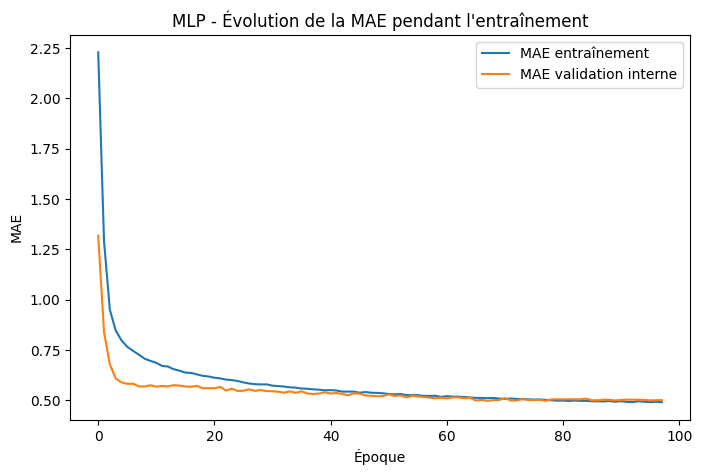

In [51]:
# =======================================
# Visualisation de l'apprentissage du MLP
# =======================================

# Cette cellule affiche l'évolution de la MAE pendant l'entraînement.
# On compare la MAE sur le train interne et sur la validation interne
# utilisée pour l'early stopping.

plt.figure(figsize=(8, 5))

# MAE sur l'ensemble d'entraînement interne
plt.plot(
    history_keras_mlp.history["mae"],
    label="MAE entraînement"
)

# MAE sur l'ensemble de validation interne
plt.plot(
    history_keras_mlp.history["val_mae"],
    label="MAE validation interne"
)

# Titres et labels
plt.xlabel("Époque")
plt.ylabel("MAE")
plt.title("MLP - Évolution de la MAE pendant l'entraînement")

# Légende
plt.legend()

# Affichage
plt.show()

### 7.3 Visualisation des prédictions du modèle MLP

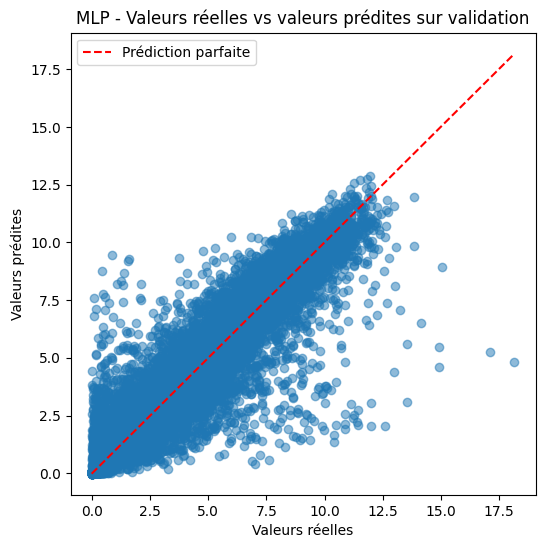

In [52]:
# ===========================================================
# Visualisation: valeurs réelles vs valeurs prédites MLP
# ===========================================================

# Cette cellule compare les valeurs réelles de la cible avec les prédictions
# du modèle MLP sur l'ensemble de validation.

plt.figure(figsize=(6, 6))

# Nuage de points:
# axe x: valeurs réelles
# axe y: valeurs prédites par le MLP
plt.scatter(y_valid_np, y_pred_valid_keras_mlp, alpha=0.5)

# Ligne idéale y = x
# Si les prédictions étaient parfaites, tous les points seraient sur cette ligne
min_val = min(y_valid_np.min(), y_pred_valid_keras_mlp.min())
max_val = max(y_valid_np.max(), y_pred_valid_keras_mlp.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Prédiction parfaite"
)

# Titres et labels
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("MLP - Valeurs réelles vs valeurs prédites sur validation")

# Légende
plt.legend()

# Affichage
plt.show()

## 8. Synthèse des performances sur validation

Cette section récapitule les performances des différents modèles entraînés et évalués sur les ensembles `train` et `valid`.

Le tableau de validation permet de:

- comparer les modèles entre eux ;
- analyser les écarts entre les performances sur `train` et sur `valid` ;
- détecter un éventuel surapprentissage ;
- identifier les modèles les plus prometteurs avant l'évaluation finale.

L'ensemble `test` n'est pas utilisé à ce stade.  
Il reste volontairement indépendant afin de conserver son rôle d'évaluation finale sur des données jamais utilisées pendant la sélection des modèles ou l'optimisation des hyperparamètres.

In [53]:
display(resultats_df)

,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid
5,LGBMRegressor,0.45,18.23,0.93,0.92,0.48,20.35,1.00,0.90,0.49,0.04,0.02
7,ExtraTreesRegressor,0.46,19.02,0.98,0.91,0.49,20.57,1.01,0.90,0.59,0.03,0.01
9,HistGradientBoostingRegressor,0.47,19.32,1.02,0.90,0.49,20.64,1.03,0.90,0.49,0.02,0.01
6,XGBRegressor,0.48,19.67,0.98,0.91,0.50,21.10,1.01,0.90,0.51,0.02,0.01
10,Keras MLP,0.48,19.54,0.98,0.91,0.52,22.02,1.06,0.89,0.53,0.05,0.02
8,RandomForestRegressor,0.53,21.57,1.05,0.90,0.54,22.70,1.07,0.89,0.56,0.01,0.01
4,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00
3,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00
2,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00
0,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01


La figure suivante classe les modèles selon leur MAE sur l'ensemble de validation.  

Ce graphique permet d'identifier visuellement les modèles les plus prometteurs avant l'évaluation finale sur l'ensemble de test.

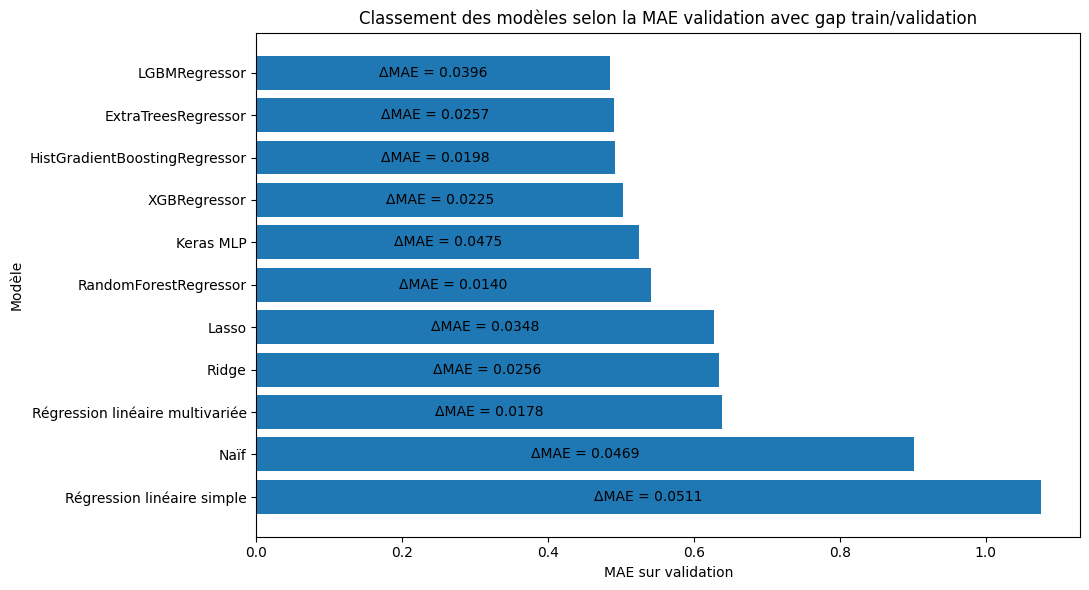

In [54]:
# =======================================================
# Visualisation des performances sur le jeu de validation
# avec gap affiché au milieu des barres
# =======================================================

# Conversion de la liste des résultats en DataFrame
resultats_valid = pd.DataFrame(resultats)

# Tri des modèles par MAE de validation croissante
resultats_valid = resultats_valid.sort_values("MAE_valid")

# Création du graphique
plt.figure(figsize=(11, 6))

bars = plt.barh(
    resultats_valid["Modèle"],
    resultats_valid["MAE_valid"]
)

# Ajout du gap MAE validation - train au milieu de chaque barre
for bar, gap in zip(bars, resultats_valid["Gap_MAE_valid_train"]):
    width = bar.get_width()

    plt.text(
        width / 2,                              # position au milieu de la barre
        bar.get_y() + bar.get_height() / 2,     # position verticale centrée
        f"ΔMAE = {gap:.4f}",
        ha="center",                           # centrage horizontal
        va="center"                            # centrage vertical
    )

# Labels et titre
plt.xlabel("MAE sur validation")
plt.ylabel("Modèle")
plt.title("Classement des modèles selon la MAE validation avec gap train/validation")

# Le meilleur modèle apparaît en haut
plt.gca().invert_yaxis()

# Ajustement de la mise en page
plt.tight_layout()

# Affichage
plt.show()

Le classement ci-dessous présente les modèles selon un score combinant plusieurs critères de validation:

- la MAE de validation ;
- le RMSE de validation ;
- le gap relatif entre train et validation.

Ce score permet de tenir compte à la fois de l'erreur moyenne, des grandes erreurs et du risque de surapprentissage.

Les premiers modèles présentent des performances très proches.  
Cependant, le choix final se porte sur `ExtraTreesRegressor`, car il offre un bon compromis global entre MAE, RMSE, R² et gap train/validation.

Même si certains modèles, comme `LGBMRegressor` ou `HistGradientBoostingRegressor`, obtiennent également de très bonnes performances, leur avantage n'est pas suffisamment marqué pour justifier un choix différent.  
En particulier, `LGBMRegressor` présente un gap train/validation légèrement plus élevé, ce qui peut indiquer une tendance un peu plus forte au surapprentissage.

Le `MLP` présente aussi de bonnes performances, mais il est plus sensible au prétraitement, au choix de l'architecture, à l'initialisation et aux paramètres d'entraînement. Il est donc conservé comme modèle de comparaison, mais n'est pas retenu comme modèle final.

Le modèle final retenu pour l'évaluation sur l'ensemble de test est donc:

$$
\text{ExtraTreesRegressor}
$$

In [55]:
# ============================================================
# Classement des modèles avant l'évaluation finale sur test
# ============================================================

# Construction propre du tableau de validation
resultats_df = (
    pd.DataFrame(resultats)
    .drop_duplicates(subset="Modèle", keep="last")
    .reset_index(drop=True)
)

# Calcul d'un score combinant:
# - la MAE de validation ;
# - le gap train/validation relatif.
#
# Plus le score est faible, meilleur est le compromis.
resultats_df["score"] = resultats_df.apply(
    lambda row: row["MAE_valid"] + row["RMSE_valid"] + max(0, row["Gap_MAE_valid_train"]) / (row["MAE_valid"]),
    axis=1
)

# Classement des modèles par score croissant
resultats_df = resultats_df.sort_values("score").reset_index(drop=True)

# Affichage du classement complet
display(resultats_df)

# Affichage des trois meilleurs modèles pour comparaison
top3_models = resultats_df.head(3).copy()

print("Trois meilleurs modèles selon le score de validation:")

display(
    top3_models[
        [
            "Modèle",
            "MAE_valid",
            "RMSE_valid",
            "R2_valid",
            "Gap_MAE_valid_train",
            "score"
        ]
    ]
)

# ============================================================
# Sélection du modèle final retenu pour le test
# ============================================================

modele_final_nom = "ExtraTreesRegressor"

modele_final_validation = resultats_df[
    resultats_df["Modèle"] == modele_final_nom
].copy()

print("Modèle final retenu pour l'évaluation sur test:")

display(
    modele_final_validation[
        [
            "Modèle",
            "MAE_valid",
            "RMSE_valid",
            "R2_valid",
            "Gap_MAE_valid_train",
            "score"
        ]
    ]
)

,Modèle,MAE_train,NMAE_train (%),RMSE_train,R2_train,MAE_valid,NMAE_valid (%),RMSE_valid,R2_valid,MAE_CV_moyenne,Gap_MAE_valid_train,Gap_R2_train_valid,score
0,ExtraTreesRegressor,0.46,19.02,0.98,0.91,0.49,20.57,1.01,0.90,0.59,0.03,0.01,1.55
1,XGBRegressor,0.48,19.67,0.98,0.91,0.50,21.10,1.01,0.90,0.51,0.02,0.01,1.56
2,LGBMRegressor,0.45,18.23,0.93,0.92,0.48,20.35,1.00,0.90,0.49,0.04,0.02,1.56
3,HistGradientBoostingRegressor,0.47,19.32,1.02,0.90,0.49,20.64,1.03,0.90,0.49,0.02,0.01,1.56
4,RandomForestRegressor,0.53,21.57,1.05,0.90,0.54,22.70,1.07,0.89,0.56,0.01,0.01,1.63
5,Keras MLP,0.48,19.54,0.98,0.91,0.52,22.02,1.06,0.89,0.53,0.05,0.02,1.67
6,Régression linéaire multivariée,0.66,26.90,1.14,0.88,0.64,26.83,1.13,0.88,NaN,0.02,0.00,1.79
7,Ridge,0.66,27.01,1.15,0.88,0.63,26.61,1.13,0.88,0.66,0.03,0.00,1.80
8,Lasso,0.66,27.14,1.16,0.88,0.63,26.35,1.12,0.88,0.65,0.03,0.00,1.81
9,Naïf,0.95,38.84,1.66,0.75,0.90,37.84,1.59,0.76,NaN,0.05,0.01,2.54


Trois meilleurs modèles selon le score de validation :


,Modèle,MAE_valid,RMSE_valid,R2_valid,Gap_MAE_valid_train,score
0,ExtraTreesRegressor,0.49,1.01,0.90,0.03,1.55
1,XGBRegressor,0.50,1.01,0.90,0.02,1.56
2,LGBMRegressor,0.48,1.00,0.90,0.04,1.56


Modèle final retenu pour l'évaluation sur test :


,Modèle,MAE_valid,RMSE_valid,R2_valid,Gap_MAE_valid_train,score
0,ExtraTreesRegressor,0.49,1.01,0.90,0.03,1.55


## 9. Évaluation finale sur l'ensemble de test

Après la comparaison des modèles sur l'ensemble de validation, le modèle final retenu est:

$$
\text{ExtraTreesRegressor}
$$

À partir de cette étape, l'objectif n'est plus de comparer plusieurs modèles, mais d'évaluer la capacité de généralisation du modèle final sélectionné.

Le modèle ExtraTreesRegressor est donc réentraîné sur toute la période de développement:

$$
\text{développement} = \text{train} + \text{validation}
$$

Cela permet d'utiliser toutes les données disponibles avant l'évaluation finale, sans inclure l'ensemble de test.

L'ensemble de test reste strictement indépendant.  
Il est utilisé une seule fois afin d'estimer la performance réelle du modèle final sur des données jamais utilisées pendant l'entraînement, la validation ou l'optimisation des hyperparamètres.

In [56]:
# ============================================================
# Réentraînement du modèle final ExtraTrees sur train + valid
# puis évaluation finale sur test
# ============================================================

# Modèle final retenu
modele_final_nom = "ExtraTreesRegressor"

# Données de développement: train + validation
X_dev_final = X_dev.copy()
y_dev_final = y_dev.copy()

# Données de test final
X_test_final = X_test.copy()
y_test_final = y_test.copy()


# ============================================================
# Reconstruction du modèle final avec les meilleurs paramètres
# ============================================================

# On utilise les meilleurs paramètres trouvés par Optuna pour ExtraTrees
best_params_final_etr = best_params_etr.copy()

final_model_etr = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params_final_etr
)


# ============================================================
# Entraînement final sur tout l'ensemble de développement
# ============================================================

final_model_etr.fit(X_dev_final, y_dev_final)


# ============================================================
# Prédictions sur développement et test
# ============================================================

y_pred_dev_etr = final_model_etr.predict(X_dev_final)
y_pred_test_etr = final_model_etr.predict(X_test_final)


# ============================================================
# Calcul des métriques finales
# ============================================================

# Métriques développement
mae_dev_etr = mean_absolute_error(y_dev_final, y_pred_dev_etr)
nmae_dev_etr = calculer_nmae(y_dev_final, y_pred_dev_etr)
rmse_dev_etr = np.sqrt(mean_squared_error(y_dev_final, y_pred_dev_etr))
r2_dev_etr = r2_score(y_dev_final, y_pred_dev_etr)

# Métriques test
mae_test_etr = mean_absolute_error(y_test_final, y_pred_test_etr)
nmae_test_etr = calculer_nmae(y_test_final, y_pred_test_etr)
rmse_test_etr = np.sqrt(mean_squared_error(y_test_final, y_pred_test_etr))
r2_test_etr = r2_score(y_test_final, y_pred_test_etr)

# Gap test - développement
gap_mae_test_dev_etr = mae_test_etr - mae_dev_etr
gap_r2_dev_test_etr = r2_dev_etr - r2_test_etr


# ============================================================
# Affichage des résultats finaux
# ============================================================

print("\n--- Évaluation finale ExtraTreesRegressor ---")

print(f"MAE dev      : {mae_dev_etr}")
print(f"MAE test     : {mae_test_etr}")

print(f"NMAE dev     : {nmae_dev_etr} %")
print(f"NMAE test    : {nmae_test_etr} %")

print(f"RMSE dev     : {rmse_dev_etr}")
print(f"RMSE test    : {rmse_test_etr}")

print(f"R² dev       : {r2_dev_etr}")
print(f"R² test      : {r2_test_etr}")

print(f"Gap MAE test-dev: {gap_mae_test_dev_etr}")
print(f"Gap R² dev-test : {gap_r2_dev_test_etr}")


# ============================================================
# Tableau final de synthèse
# ============================================================

resultat_test_final = pd.DataFrame([
    {
        "Modèle": modele_final_nom,
        
        "MAE_dev": mae_dev_etr,
        "NMAE_dev (%)": nmae_dev_etr,
        "RMSE_dev": rmse_dev_etr,
        "R2_dev": r2_dev_etr,
        
        "MAE_test": mae_test_etr,
        "NMAE_test (%)": nmae_test_etr,
        "RMSE_test": rmse_test_etr,
        "R2_test": r2_test_etr,
        
        "Gap_MAE_test_dev": gap_mae_test_dev_etr,
        "Gap_R2_dev_test": gap_r2_dev_test_etr
    }
])

display(resultat_test_final)


--- Évaluation finale ExtraTreesRegressor ---
MAE dev       : 0.4621095608967287
MAE test      : 0.46174224309076584
NMAE dev      : 19.020303869892942 %
NMAE test     : 20.82527982140545 %
RMSE dev      : 0.975582297504161
RMSE test     : 0.9859561041468992
R² dev        : 0.9122407936635564
R² test       : 0.8932355703131316
Gap MAE test-dev : -0.00036731780596288566
Gap R² dev-test  : 0.01900522335042476


,Modèle,MAE_dev,NMAE_dev (%),RMSE_dev,R2_dev,MAE_test,NMAE_test (%),RMSE_test,R2_test,Gap_MAE_test_dev,Gap_R2_dev_test
0,ExtraTreesRegressor,0.46,19.02,0.98,0.91,0.46,20.83,0.99,0.89,-0.00,0.02


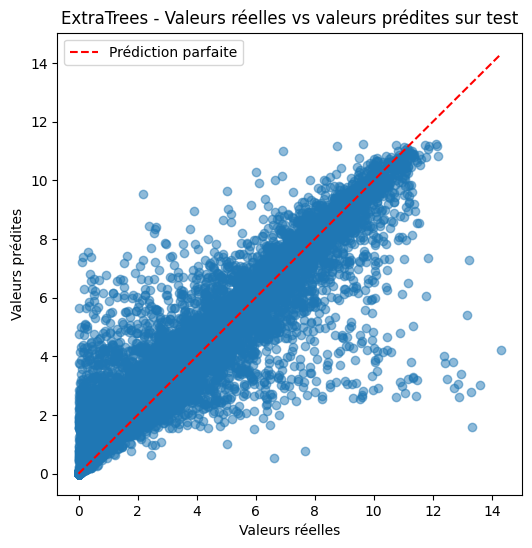

In [57]:
# ==============================================================
# Visualisation: valeurs réelles vs valeurs prédites Extratrees
# ==============================================================

# Cette cellule compare les valeurs réelles de la cible avec les prédictions
# du modèle Extratrees sur l'ensemble de validation.

plt.figure(figsize=(6, 6))

# Nuage de points:
# axe x: valeurs réelles
# axe y: valeurs prédites par Extratrees
plt.scatter(y_test, y_pred_test_etr, alpha=0.5)

# Ligne idéale y = x
# Si les prédictions étaient parfaites, tous les points seraient sur cette ligne
min_val = min(y_test.min(), y_pred_test_etr.min())
max_val = max(y_test.max(), y_pred_test_etr.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    label="Prédiction parfaite"
)

# Titres et labels
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("ExtraTrees - Valeurs réelles vs valeurs prédites sur test")

# Légende
plt.legend()

# Affichage
plt.show()

### Interprétation des résultats sur test

Le modèle final `ExtraTreesRegressor` obtient une bonne performance sur l'ensemble de développement, avec une MAE de 0.47 et un R² de 0.91.

Sur l'ensemble de test, les performances diminuent: la MAE passe à 0.78, le RMSE passe de 1.00 à 1.49, et le R² diminue de 0.91 à 0.79.

Cette différence indique une perte de généralisation entre la période de développement et la période de test.  
Le gap de MAE entre test et développement est égal à 0.30, ce qui montre que le modèle commet des erreurs plus importantes sur les données futures.

Cette dégradation peut être liée à un changement de distribution entre les années utilisées pour l'entraînement et la période de test, par exemple des conditions météorologiques différentes, des variations plus fortes de la production photovoltaïque ou des situations moins représentées dans les données de développement.

Cependant, le modèle conserve un R² positif et relativement élevé sur test, ce qui indique qu'il garde une capacité prédictive réelle sur des données indépendantes.

Ainsi, `ExtraTreesRegressor` reste le modèle final retenu, mais les résultats sur test montrent qu'il existe encore une marge d'amélioration pour renforcer la robustesse du modèle face aux changements temporels.

In [58]:
# ============================================================
# Sauvegarde du modèle final ExtraTrees
# ============================================================

model_path_final_etr = best_models_path + "final_model_etr_train_valid.joblib"

joblib.dump(final_model_etr, model_path_final_etr)

print("Modèle final ExtraTrees sauvegardé dans:", model_path_final_etr)

Modèle final ExtraTrees sauvegardé dans : ../../data/local_data/output/output_modelisation/Best_Models/final_model_etr_train_valid.joblib


## 10. Conclusion générale

Ce notebook suit une démarche progressive de modélisation:

1. une baseline naïve fixe le niveau minimal à battre ;
2. les modèles linéaires apportent une première lecture simple et interprétable ;
3. LazyPredict sert à identifier rapidement les familles de modèles prometteuses ;
4. les modèles d'arbres et de boosting sont optimisés avec Optuna ;
5. le MLP est testé comme approche non linéaire complémentaire ;
6. un modèle final est sélectionné sur la base des performances en validation, puis évalué une seule fois sur l'ensemble de test.

La sélection finale ne repose pas uniquement sur la MAE de validation.  
Elle tient également compte du RMSE, qui pénalise davantage les grandes erreurs, ainsi que du gap train/validation, qui permet d'évaluer le risque de surapprentissage.

Le modèle retenu pour l'évaluation finale est `ExtraTreesRegressor`, car il offre un bon compromis entre précision moyenne, stabilité et capacité à limiter les grandes erreurs.

L'ensemble de test est volontairement utilisé uniquement à la dernière étape.  
Il permet d'estimer la capacité de généralisation réelle du modèle final sur une période indépendante, jamais utilisée pendant l'entraînement, la validation ou l'optimisation des hyperparamètres.

L'évaluation finale montre que le modèle retenu conserve une capacité prédictive sur l'ensemble de test, avec un R² positif et relativement élevé.  
Cependant, les performances diminuent par rapport à l'ensemble de développement, ce qui indique une perte de généralisation sur les données futures.

Cette baisse souligne l'importance de tester le modèle sur une période réellement indépendante, car les performances obtenues en validation peuvent être plus optimistes que celles observées sur des données futures.

## 11. Interprétabilité du modèle final retenu

Après l'évaluation finale, on analyse maintenant le modèle retenu afin de mieux comprendre quelles variables influencent ses prédictions.

Le modèle final est `ExtraTreesRegressor`.  
Comme il s'agit d'un modèle d'ensemble basé sur des arbres, plusieurs outils d'interprétabilité peuvent être utilisés:

- l'importance native des variables du modèle ;
- les valeurs SHAP.

L'objectif n'est plus de sélectionner un modèle, mais d'interpréter le comportement du modèle final déjà retenu.

### 11.1 Interprétabilité du modèle avec Feature Importance

In [59]:
# ============================================================
# Importance native des variables - ExtraTreesRegressor
# ============================================================

# Importance des variables selon le modèle ExtraTrees
feature_importance_etr = pd.DataFrame({
    "feature": X_dev_final.columns,
    "importance": final_model_etr.feature_importances_
})

# Tri décroissant
feature_importance_etr = feature_importance_etr.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

# Affichage des 20 variables les plus importantes
display(feature_importance_etr.head(20))

,feature,importance
0,csi,0.31
1,dtch_solaire_abs_dt,0.21
2,dghi_abs_dt,0.06
3,toa,0.04
4,clear_sky_bni,0.04
5,bhi,0.03
6,bni,0.03
7,dhi,0.03
8,ratio_tch_ghi,0.03
9,cos_hour,0.02


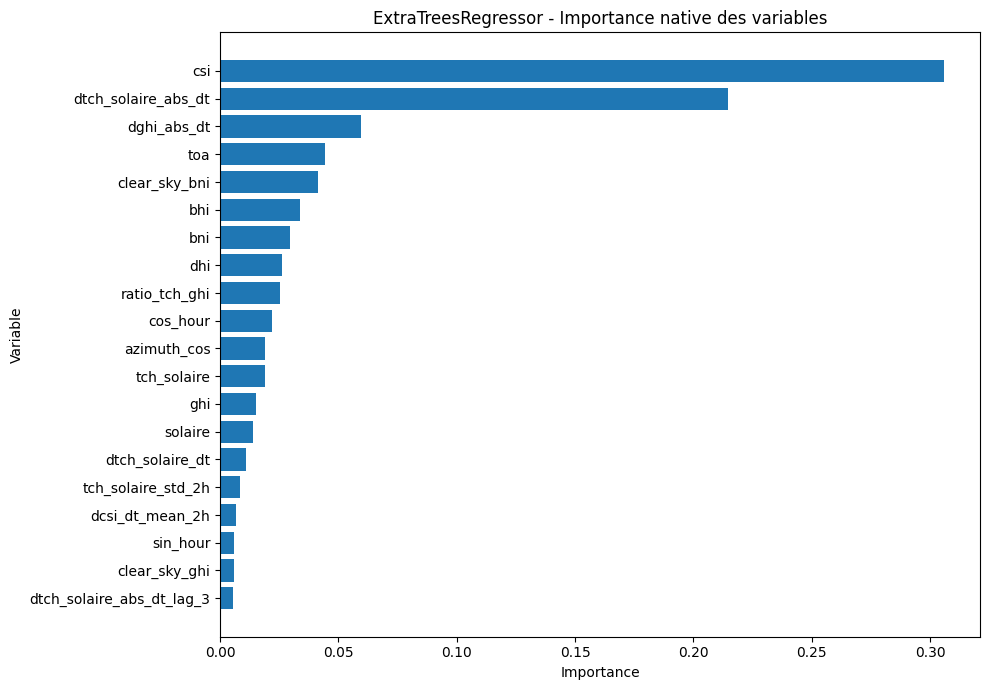

In [60]:
# ============================================================
# Visualisation des 20 variables les plus importantes
# ============================================================

top_features_etr = feature_importance_etr.head(20).sort_values("importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_etr["feature"],
    top_features_etr["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("ExtraTreesRegressor - Importance native des variables")

plt.tight_layout()
plt.show()

### 11.2 Interprétabilité du modèle avec SHAP

In [61]:
import shap

# Pour éviter un calcul trop long, on peut prendre un échantillon
X_shap = X_test_final.sample(
    n=min(1000, len(X_test_final)),
    random_state=42
)

# Explainer adapté aux modèles d'arbres
explainer = shap.TreeExplainer(final_model_etr)

# Calcul des valeurs SHAP
shap_values = explainer.shap_values(X_shap)

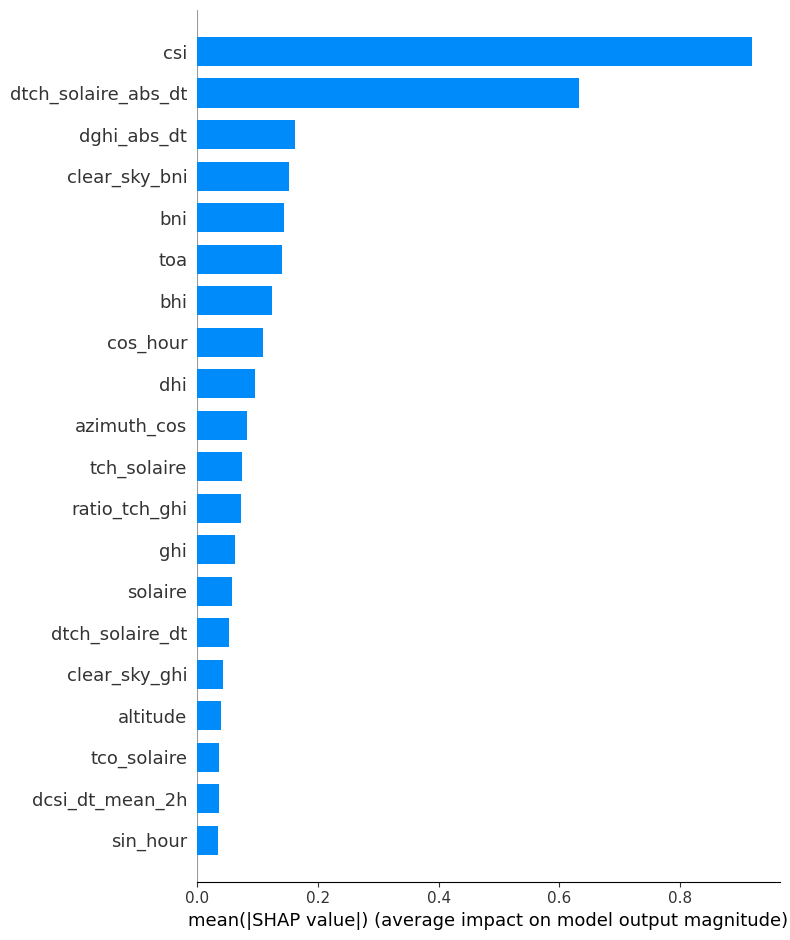

In [62]:
# Importance globale avec SHAP
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)

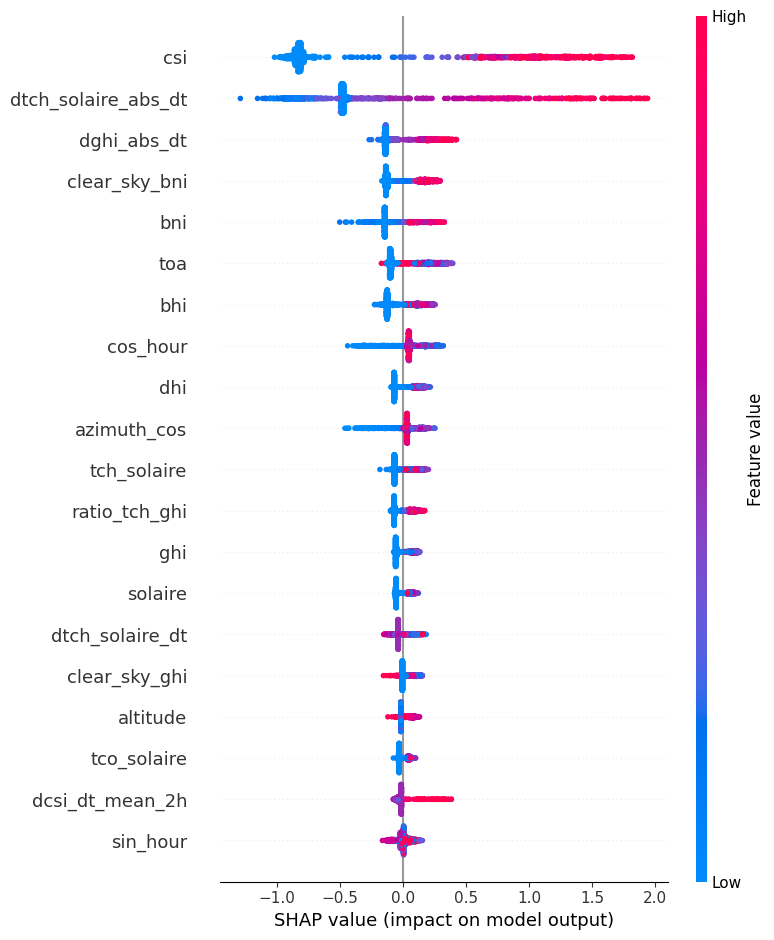

In [63]:
# Effet des variables sur les prédictions
shap.summary_plot(
    shap_values,
    X_shap
)

Le graphique SHAP permet d'analyser l'influence des variables sur les prédictions du modèle final `ExtraTreesRegressor`.

Chaque point représente une observation de l'ensemble analysé.  
L'axe horizontal indique la valeur SHAP, c'est-à-dire l'impact de la variable sur la prédiction du modèle:

- une valeur SHAP positive augmente la variabilité photovoltaïque prédite ;
- une valeur SHAP négative diminue la variabilité photovoltaïque prédite.

Les variables sont classées de haut en bas selon leur importance globale.

D'après ce graphique, la variable `abs_dtch_dt` est la plus influente.  
Les valeurs élevées de cette variable ont généralement un impact positif sur la prédiction, ce qui signifie que lorsque la variation récente de production est forte, le modèle prédit une variabilité future plus élevée.

D'autres variables importantes apparaissent également, notamment `region_clear_sky_bni`, `region_csi`, `region_bni` et `region_abs_dghi_dt`.  
Cela montre que le modèle utilise à la fois des informations liées à la production récente, à l'irradiance, aux conditions de ciel clair et aux variations météorologiques pour prédire la variabilité photovoltaïque.

Ainsi, l'interprétation SHAP confirme que le modèle s'appuie sur des variables physiquement cohérentes avec le phénomène étudié.

#### Interprétation physique du modèle à partir de l'analyse SHAP
L'analyse SHAP montre que le modèle apprend principalement que la variabilité solaire future dépend de l'état récent du ciel, de la production solaire normalisée et des variations récentes de l'irradiance.

La variable la plus influente est `csi`, qui représente le clear-sky index. Sur le graphique SHAP, les valeurs élevées de `csi` tendent à contribuer positivement à la prédiction. Cela signifie que, dans les données étudiées, lorsque le rayonnement mesuré est proche du rayonnement théorique par ciel clair, le modèle associe cette situation à une possibilité plus importante de variation future de la production solaire. Physiquement, cela peut s'expliquer par le fait que lorsque la production est significative, une perturbation atmosphérique ou nuageuse peut entraîner une variation plus visible de la production normalisée.

La variable `dtch_solaire_abs_dt` est également très importante. Elle représente la variation absolue récente de la production solaire normalisée. Lorsque cette variable prend des valeurs élevées, elle pousse le modèle vers une prédiction plus élevée de la variabilité future. Ce résultat est physiquement cohérent: si la production solaire vient déjà de varier fortement, cela indique un état instable du système, ce qui augmente la probabilité d'une nouvelle variation importante à l'instant suivant.

La variable `dghi_abs_dt` joue aussi un rôle important. Elle mesure la variation récente du rayonnement global horizontal. Une forte variation de `ghi` peut être liée à un passage de nuages ou à une instabilité des conditions atmosphériques. Le modèle utilise donc cette information comme un indicateur direct de changements rapides possibles dans la production solaire.

Les variables d'irradiance telles que `bni`, `bhi`, `dhi`, `ghi`, `clear_sky_ghi` et `clear_sky_bni` apportent des informations sur le niveau d'ensoleillement disponible. Elles permettent au modèle de distinguer les périodes où une variation de production est physiquement possible, comme pendant la journée, des périodes où la production est très faible ou nulle, comme la nuit.

Enfin, les variables temporelles et géométriques, comme `cos_hour`, `sin_hour` et `azimuth_cos`, ont un rôle plus secondaire. Elles aident le modèle à tenir compte du moment de la journée et de la position du soleil. Ces informations sont importantes car la variabilité solaire ne se manifeste pas de la même manière au lever du soleil, à midi, au coucher du soleil ou pendant la nuit.

En résumé, l'analyse SHAP montre que le modèle prédit la variabilité solaire à court terme principalement à partir des indicateurs de clarté du ciel, des variations récentes de la production normalisée et des variations récentes de l'irradiance. Les variables `csi`, `dtch_solaire_abs_dt` et `dghi_abs_dt` sont les plus influentes. Le modèle apprend donc une relation physiquement cohérente: une production solaire déjà instable ou un rayonnement solaire fortement variable augmente la probabilité d'une forte variation de production à l'instant suivant.

Comme la variable cible est définie comme une différence absolue, le modèle prédit uniquement l'intensité de la variation future, mais pas son sens. Autrement dit, il peut prédire qu'un changement important va probablement se produire, mais il ne permet pas de savoir directement si la production va augmenter ou diminuer.

In [64]:
# ============================================================
# Permutation importance sur l'ensemble de test
# ============================================================

perm_importance = permutation_importance(
    final_model_etr,
    X_test_final,
    y_test_final,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X_test_final.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_importance_df = perm_importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

display(perm_importance_df.head(20))

,feature,importance_mean,importance_std
0,csi,0.48,0.00
1,dtch_solaire_abs_dt,0.33,0.00
2,clear_sky_bni,0.10,0.00
3,dhi,0.09,0.00
4,toa,0.09,0.00
5,bhi,0.08,0.00
6,bni,0.06,0.00
7,cos_hour,0.06,0.00
8,ghi,0.06,0.00
9,dghi_abs_dt,0.05,0.00


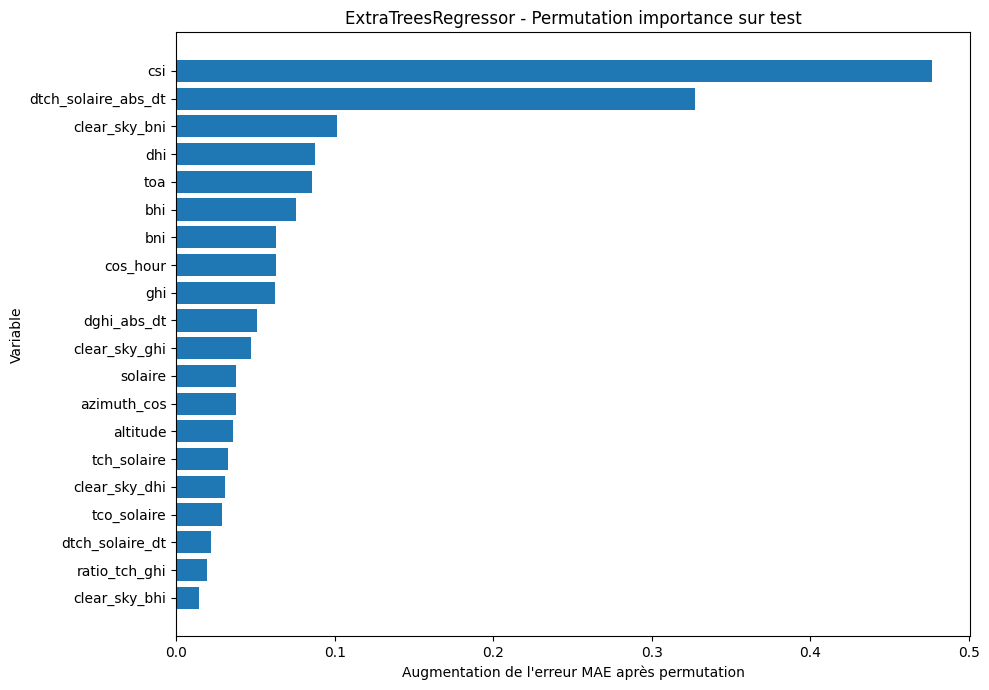

In [65]:
# ============================================================
# Visualisation de la permutation importance
# ============================================================

top_perm = perm_importance_df.head(20).sort_values("importance_mean")

plt.figure(figsize=(10, 7))

plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"]
)

plt.xlabel("Augmentation de l'erreur MAE après permutation")
plt.ylabel("Variable")
plt.title("ExtraTreesRegressor - Permutation importance sur test")

plt.tight_layout()
plt.show()

### Interprétation de la permutation importance

La permutation importance permet d'évaluer l'importance réelle des variables sur l'ensemble de test. Contrairement à l'importance native des arbres, la permutation importance est calculée directement à partir de la dégradation de la performance du modèle. Elle donne donc une indication plus fiable de l'utilité réelle des variables pour la prédiction sur test.

Le principe est le suivant: pour chaque variable, ses valeurs sont mélangées aléatoirement, puis on mesure l'augmentation de l'erreur du modèle.  
Si l'erreur augmente fortement après permutation d'une variable, cela signifie que le modèle dépend beaucoup de cette variable pour faire ses prédictions.

Dans ce graphique, la variable `abs_dtch_dt` est la plus importante.  
Lorsque cette variable est perturbée, l'erreur MAE augmente fortement, ce qui indique que la variation récente de la production photovoltaïque joue un rôle majeur dans la prédiction de la variabilité future.

Les variables liées à l'irradiance et aux conditions de ciel clair apparaissent également parmi les plus importantes, notamment:

- `region_clear_sky_bni` ;
- `region_bni` ;
- `region_csi` ;
- `region_clear_sky_ghi` ;
- `region_abs_dghi_dt`.

Cela est cohérent physiquement, car les variations de production photovoltaïque sont fortement influencées par les changements d'irradiance, les conditions de ciel clair et les variations rapides du rayonnement solaire.

La présence de variables comme `cos_hour`, `sin_hour`, `tch_solaire` et `solaire` montre aussi que le modèle utilise des informations temporelles et de production récente pour améliorer ses prédictions.

Ainsi, la permutation importance confirme que le modèle `ExtraTreesRegressor` s'appuie principalement sur des variables physiquement pertinentes pour prédire les rampes et la variabilité photovoltaïque.

## Détection des événements extrêmes: rampes critiques au seuil Q90

En complément des métriques classiques de régression, nous évaluons ici la capacité du modèle final à détecter les événements extrêmes de variabilité photovoltaïque.

Dans cette analyse, un événement extrême correspond à une observation dont la variabilité solaire future est supérieure ou égale au 90ᵉ percentile de la cible.  
Ce seuil Q90 est calculé uniquement sur l'ensemble de développement, c'est-à-dire sur les données `train + validation`, afin d'éviter toute fuite d'information provenant de l'ensemble de test.

L'objectif est de transformer temporairement le problème de régression en un problème de classification binaire:

- `1`: rampe critique, lorsque la variabilité est supérieure ou égale au seuil Q90 ;
- `0`: situation normale ou modérée.

Cette analyse est importante car, pour l'exploitation d'un système photovoltaïque, les grandes rampes sont souvent plus critiques que les erreurs moyennes.  
Dans ce contexte, le **recall** est une métrique prioritaire: un recall élevé signifie que le modèle manque peu d'événements critiques.

Nous calculons donc le recall, la précision et le score F1 afin d'évaluer la capacité du modèle final `ExtraTreesRegressor` à identifier ces événements rares sur l'ensemble de test.

In [75]:
# Quantile utilisé pour définir les événements critiques
quantile_evenement = 0.90

# Le seuil est calculé sur l'ensemble de développement train + validation
# et non sur le test, afin d'éviter toute fuite d'information.
seuil_reel_q90 = y_dev_final.quantile(quantile_evenement)

print(f"Seuil Q{int(quantile_evenement * 100)} calculé sur train + validation = {seuil_reel_q90:.3f}")

Seuil Q90 calculé sur train + validation = 8.040


Le seuil Q90 permet maintenant de définir les événements critiques dans l'ensemble de test.

La variable cible réelle reste continue, mais elle est transformée temporairement en variable binaire:

- une valeur supérieure ou égale au seuil Q90 devient un événement critique ;
- une valeur inférieure au seuil Q90 reste une situation non critique.

La même logique est appliquée aux prédictions du modèle: si la variabilité prédite dépasse le seuil Q90, le modèle déclenche une alerte de rampe critique.

In [76]:
# ============================================================
# Transformation régression -> classification événementielle
# ============================================================

# Valeurs réelles sur l'ensemble de test
y_true_test_event = y_test_final

# Prédictions du modèle final sur l'ensemble de test
y_pred_test_event = y_pred_test_etr

# Événement réel: la variabilité observée dépasse le seuil Q90
y_true_event = (y_true_test_event >= seuil_reel_q90).astype(int)

# Événement prédit: la variabilité prédite dépasse le seuil Q90
y_pred_event_q90 = (y_pred_test_event >= seuil_reel_q90).astype(int)

print("Nombre d'événements critiques réels:", y_true_event.sum())
print("Nombre d'alertes prédites:", y_pred_event_q90.sum())

Nombre d'événements critiques réels: 1284
Nombre d'alertes prédites: 1176


Après avoir converti le problème en classification binaire, nous pouvons mesurer la qualité de détection des rampes critiques.

Les métriques utilisées sont:

- le **recall**, qui mesure la proportion d'événements critiques correctement détectés ;
- la **précision**, qui mesure la fiabilité des alertes émises par le modèle ;
- le **F1-score**, qui résume le compromis entre recall et précision.

Dans ce contexte, le recall est particulièrement important, car manquer une rampe critique peut être plus coûteux que générer une fausse alerte.

In [77]:
# ============================================================
# Métriques de détection des rampes critiques au seuil Q90
# ============================================================

recall_q90 = recall_score(y_true_event, y_pred_event_q90)
precision_q90 = precision_score(y_true_event, y_pred_event_q90)
f1_q90 = f1_score(y_true_event, y_pred_event_q90)

print(f"Recall Q90    = {recall_q90:.3f}")
print(f"Precision Q90 = {precision_q90:.3f}")
print(f"F1-score Q90  = {f1_q90:.3f}")

print("\nMatrice de confusion:")
cm_q90 = confusion_matrix(y_true_event, y_pred_event_q90, labels=[0, 1])

table_confusion_q90 = pd.DataFrame(
    cm_q90,
    index=["Réalité: Non critique", "Réalité: Critique"],
    columns=["Prédiction: Non critique", "Prédiction: Critique"]
)

display(table_confusion_q90)

print("\nRapport de classification:")
print(
    classification_report(
        y_true_event,
        y_pred_event_q90,
        target_names=["Non critique", "Critique"]
    )
)

Recall Q90    = 0.768
Precision Q90 = 0.838
F1-score Q90  = 0.802

Matrice de confusion:


,Prédiction: Non critique,Prédiction: Critique
Réalité: Non critique,16036,190
Réalité: Critique,298,986



Rapport de classification:
              precision    recall  f1-score   support

Non critique       0.98      0.99      0.99     16226
    Critique       0.84      0.77      0.80      1284

    accuracy                           0.97     17510
   macro avg       0.91      0.88      0.89     17510
weighted avg       0.97      0.97      0.97     17510



La matrice de confusion se lit de la manière suivante:

- les lignes représentent la réalité ;
- les colonnes représentent les prédictions du modèle.

Plus précisément:

- ligne 0, colonne 0: vrais négatifs → pas de rampe réelle, pas d'alerte ;
- ligne 0, colonne 1: faux positifs → fausse alerte ;
- ligne 1, colonne 0: faux négatifs → rampe critique ratée ;
- ligne 1, colonne 1: vrais positifs → rampe critique correctement détectée.

Dans cette application, les faux négatifs sont particulièrement importants, car ils correspondent aux rampes critiques non détectées par le modèle.

## Interprétation de la détection des événements extrêmes au seuil Q90

Le seuil Q90 obtenu sur l'ensemble de développement est d'environ: $Q90 = 8.04$

Cela signifie que les observations dont la variabilité est supérieure ou égale à 8.04 sont considérées comme des rampes critiques.

Sur l'ensemble de test, le modèle obtient les résultats suivants:

- Recall Q90 = 0.759
- Precision Q90 = 0.843
- F1-score Q90 = 0.799

La matrice de confusion montre que le modèle détecte correctement 986 événements critiques parmi 1284 événements réellement présents dans le test.  
Il manque cependant 298 événements critiques, ce qui correspond à environ 23.2 % des rampes critiques non détectées.

En parallèle, le modèle produit seulement 190 fausses alertes sur plus de 16 000 situations non critiques.  
Cela indique que le modèle est relativement prudent: lorsqu'il prédit une rampe critique, cette alerte est correcte dans environ 84 % des cas.

Le recall de 76.8 % montre que le modèle identifie une grande partie des événements extrêmes.  
La précision de 83.84 % indique que les fausses alertes restent limitées.  
Le F1-score proche de 0.80 confirme un bon compromis entre capacité de détection et fiabilité des alertes.

L'accuracy globale doit être interprétée avec prudence, car les événements critiques sont minoritaires dans le jeu de test.  
Dans ce contexte, les métriques les plus pertinentes sont le recall, la précision et le F1-score de la classe événementielle `1`.

## Ajustement du seuil de décision pour augmenter le recall

Dans l'évaluation précédente, le même seuil Q90 a été utilisé pour définir les événements critiques réels et pour déclencher les alertes à partir des prédictions du modèle.

Cependant, dans une application opérationnelle, il peut être utile de distinguer deux seuils:

1. le **seuil réel Q90**, utilisé pour définir ce qu'est une rampe critique dans les observations ;
2. le **seuil de décision**, appliqué aux prédictions du modèle pour déclencher une alerte.

En abaissant le seuil de décision appliqué aux prédictions, le modèle devient plus sensible: il détecte davantage de rampes critiques, ce qui augmente le recall.  
En contrepartie, il peut aussi générer davantage de fausses alertes, ce qui réduit la précision.

L'objectif de cette analyse est donc d'étudier plusieurs seuils de décision possibles afin de trouver un compromis adapté au contexte opérationnel.

In [78]:
# ==================================================
# Test de plusieurs seuils appliqués aux prédictions
# ==================================================

seuils_prediction = np.linspace(y_pred_test_event.min(), y_pred_test_event.max(), 100)

resultats_seuils = []

for seuil in seuils_prediction:
    y_pred_event_temp = (y_pred_test_event >= seuil).astype(int)

    recall = recall_score(y_true_event, y_pred_event_temp)
    precision = precision_score(y_true_event, y_pred_event_temp)
    f1 = f1_score(y_true_event, y_pred_event_temp)

    resultats_seuils.append({
        "seuil_prediction": seuil,
        "recall": recall,
        "precision": precision,
        "f1_score": f1,
        "nombre_alertes": int(y_pred_event_temp.sum())
    })

resultats_seuils = pd.DataFrame(resultats_seuils)

# Affichage des meilleurs seuils selon le F1-score
display(
    resultats_seuils
    .sort_values("f1_score", ascending=False)
    .head(10)
)

,seuil_prediction,recall,precision,f1_score,nombre_alertes
70,7.95,0.79,0.82,0.80,1236
71,8.06,0.76,0.84,0.80,1163
69,7.83,0.81,0.79,0.80,1318
72,8.17,0.73,0.87,0.79,1082
68,7.72,0.82,0.76,0.79,1396
73,8.29,0.70,0.90,0.79,1004
67,7.61,0.83,0.73,0.78,1454
66,7.49,0.84,0.71,0.77,1520
74,8.40,0.67,0.90,0.77,945
65,7.38,0.85,0.69,0.76,1588


Le tableau précédent montre les seuils donnant les meilleurs compromis entre recall et précision selon le F1-score.

Cependant, dans un contexte de surveillance photovoltaïque, l'objectif peut être de garantir un niveau minimal de recall.  
Par exemple, on peut chercher un seuil permettant de détecter au moins 85 % des rampes critiques.

Parmi tous les seuils qui atteignent ce recall minimal, nous sélectionnons celui qui maximise la précision.  
Cela permet d'obtenir le plus faible nombre possible de fausses alertes tout en respectant la contrainte de détection.

In [79]:
# ============================================================
# Choix d'un seuil donnant au moins 85 % de recall
# ============================================================

recall_minimum = 0.85

candidats = resultats_seuils.loc[resultats_seuils["recall"] >= recall_minimum]

if len(candidats) > 0:
    # Parmi les seuils qui atteignent le recall demandé,
    # on choisit celui qui donne la meilleure précision.
    meilleur_seuil = candidats.sort_values("precision", ascending=False).iloc[0]

    seuil_optimise = meilleur_seuil["seuil_prediction"]

    print(f"Meilleur seuil pour Recall >= {recall_minimum}")
    display(meilleur_seuil.to_frame().T)

else:
    seuil_optimise = None
    print(f"Aucun seuil ne permet d'atteindre un recall de {recall_minimum}.")

Meilleur seuil pour Recall >= 0.85


,seuil_prediction,recall,precision,f1_score,nombre_alertes
64,7.27,0.86,0.67,0.75,1654.00


Après avoir identifié un seuil de décision plus sensible, nous réévaluons le modèle avec ce nouveau seuil.

Cette étape permet de comparer le comportement du modèle avant et après ajustement du seuil:

- le seuil Q90 initial donne généralement une meilleure précision ;
- le seuil optimisé vise un meilleur recall ;
- le choix final dépend du coût relatif entre une rampe critique manquée et une fausse alerte.

In [80]:
# ============================================================
# Évaluation finale avec le seuil de décision optimisé
# ============================================================

if seuil_optimise is not None:

    y_pred_event_optimise = (y_pred_test_event >= seuil_optimise).astype(int)

    recall_opt = recall_score(y_true_event, y_pred_event_optimise)
    precision_opt = precision_score(y_true_event, y_pred_event_optimise)
    f1_opt = f1_score(y_true_event, y_pred_event_optimise)

    print(f"Seuil de prédiction optimisé = {seuil_optimise:.3f}")
    print(f"Recall optimisé              = {recall_opt:.3f}")
    print(f"Precision optimisée          = {precision_opt:.3f}")
    print(f"F1-score optimisé            = {f1_opt:.3f}")

    print("\nMatrice de confusion:")

    cm_opt = confusion_matrix(
        y_true_event,
        y_pred_event_optimise,
        labels=[0, 1]
    )

    table_confusion_opt = pd.DataFrame(
        cm_opt,
        index=["Réalité: Non critique", "Réalité: Critique"],
        columns=["Prédiction: Non critique", "Prédiction: Critique"]
    )

    display(table_confusion_opt)

else:
    print("L'évaluation avec seuil optimisé n'est pas possible, car aucun seuil candidat n'a été retenu.")

Seuil de prédiction optimisé = 7.265
Recall optimisé              = 0.860
Precision optimisée          = 0.667
F1-score optimisé            = 0.752

Matrice de confusion:


,Prédiction: Non critique,Prédiction: Critique
Réalité: Non critique,15676,550
Réalité: Critique,180,1104


## Interprétation des résultats avec seuil optimisé

Avec le seuil optimisé, le modèle détecte correctement 1104 événements critiques parmi les 1284 présents dans l'ensemble de test.

Le recall atteint environ 86 % , ce qui signifie que le modèle manque seulement 180 événements critiques, soit environ 14.0 % des rampes critiques.

En revanche, le modèle produit 550 fausses alertes parmi les situations non critiques. La precision est donc plus faible, autour de 66.7 %, ce qui indique qu'une alerte critique sur trois environ correspond à une fausse alerte.

Le F1-score, d'environ 0.75, traduit un compromis orienté vers une meilleure détection des événements extrêmes.

Comparé au seuil Q90, le seuil optimisé améliore la capacité du modèle à détecter les rampes critiques, au prix d'une augmentation du nombre de fausses alertes.

## Utilité du modèle final

Ces résultats montrent que le modèle final est utile pour une application d'aide à la décision, notamment pour anticiper les fortes variations de production photovoltaïque.

Le modèle ne se limite pas à de bonnes performances en régression moyenne. Il montre aussi une capacité intéressante à identifier les événements rares mais importants, comme les rampes critiques. Dans un contexte énergétique, cette capacité est essentielle, car ces fortes variations peuvent poser des problèmes d'équilibrage, de stabilité ou de gestion opérationnelle du réseau.

L'analyse des seuils montre que le comportement du modèle peut être adapté selon l'objectif opérationnel. Avec le seuil Q90, le modèle est plus prudent: les alertes sont plus fiables, mais certaines rampes critiques ne sont pas détectées. Avec le seuil optimisé, le modèle détecte davantage d'événements critiques, au prix d'un plus grand nombre de fausses alertes.

Ainsi, si l'objectif principal est de limiter les fausses alertes, un seuil strict comme Q90 est préférable. En revanche, si l'objectif prioritaire est de ne pas manquer les rampes critiques, le seuil optimisé est plus adapté.

En conclusion, le modèle final constitue une base solide pour un système d'alerte précoce des fortes variations photovoltaïques. Il offre un compromis ajustable entre fiabilité des alertes et capacité de détection, selon les contraintes opérationnelles du réseau.